# THPTQG Trends — Google Colab Reproducibility Notebook

Notebook này là đường chạy minh chứng cho repository: clone code từ GitHub, lấy raw CSV từ Google Drive hoặc Google Drive mounted path, chạy pipeline end-to-end và sinh lại `outputs/`, `README.md`, `docs/report.md`.

Workflow phân tích gồm: data quality → aggregate → phân phối điểm → biến động theo năm → tỉnh/vùng → bất thường → tương quan/tổ hợp → forecast/backtest → báo cáo.

In [12]:
!pip install -q gdown

import os, sys
from pathlib import Path

ROOT = Path("/content/thptqg-trends")
if not ROOT.exists():
    !git clone https://github.com/2274802010922/thptqg-trends.git /content/thptqg-trends
else:
    !cd /content/thptqg-trends && git pull

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

!pip install -q -r requirements.txt

from src.display import setup_display
setup_display()
print("Repo:", ROOT)

Already up to date.
Repo: /content/thptqg-trends


## 1. Chuẩn Bị Raw Dataset

Raw CSV không nằm trong GitHub vì file khoảng 844 MB. Chọn một trong hai cách:

- `USE_MOUNTED_DRIVE = False`: tải trực tiếp từ Google Drive public link bằng `gdown`.
- `USE_MOUNTED_DRIVE = True`: mount Google Drive cá nhân rồi trỏ tới file đã có sẵn.

In [13]:
from pathlib import Path

RAW_DRIVE_URL = "https://drive.google.com/file/d/1FIU_8XT4pIC261SwYtmwTDLFP2H_WAUc/view"
USE_MOUNTED_DRIVE = False

if USE_MOUNTED_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CSV_PATH = "/content/drive/MyDrive/do an thuc tap/cleaned_data.csv"
else:
    CSV_PATH = "/content/cleaned_data.csv"
    if not Path(CSV_PATH).exists():
        import gdown
        gdown.download(url=RAW_DRIVE_URL, output=CSV_PATH, fuzzy=True, quiet=False)

assert Path(CSV_PATH).exists(), f"Không tìm thấy raw CSV: {CSV_PATH}"
print("CSV:", CSV_PATH)
print("Size (bytes):", Path(CSV_PATH).stat().st_size)

CSV: /content/cleaned_data.csv
Size (bytes): 843891415


## 2. Cấu Hình Phạm Vi Nghiên Cứu

In [14]:
from src.config import configure

YEAR_MIN, YEAR_MAX = 2021, 2025
configure(csv_path=CSV_PATH, year_min=YEAR_MIN, year_max=YEAR_MAX)
print(f"Phạm vi đồ án: {YEAR_MIN}-{YEAR_MAX}")

Phạm vi đồ án: 2021-2025


## 3. Chạy Pipeline End-To-End

In [15]:
import time
from IPython.display import display

from src.load_data import count_rows
from src.aggregates import save_aggregates
from src.advanced_analysis import generate_da_tables, build_forecast_reliability, write_analysis_questions
from src.forecast import run_forecast_pipeline
from src.plots import generate_all_figures
from src.readme_builder import build_readme
from src.report import generate_report
from src.display import pretty_counts, pretty_forecast

t0 = time.time()

print("1/7 Kiểm tra dữ liệu")
counts = count_rows()
display(pretty_counts(counts))

print("2/7 Tổng hợp dữ liệu nền")
paths = save_aggregates()
for name, path in paths.items():
    print(name, "->", path)

print("3/7 Phân tích DA nâng cao")
da_paths = generate_da_tables()
for name, path in da_paths.items():
    print(name, "->", path)
print("analysis_questions ->", write_analysis_questions())

print("4/7 Dự báo + backtest + model comparison")
forecast = run_forecast_pipeline()
display(pretty_forecast(forecast))
print("forecast_reliability ->", build_forecast_reliability())

print("5/7 Vẽ biểu đồ")
figures = generate_all_figures()
print(f"Generated {len(figures)} figures")

print("6/7 Sinh README và report học thuật")
readme_path = build_readme()
report_path = generate_report()
print("README:", readme_path)
print("Report:", report_path)

print("7/7 Hoàn tất")
print(f"Elapsed: {(time.time() - t0) / 60:.1f} phút")

1/7 Kiểm tra dữ liệu


,Năm,Số thí sinh,Số thí sinh (raw)
0,2021,987.704,987704
1,2022,995.441,995441
2,2023,1.022.060,1022060
3,2024,1.061.605,1061605
4,2025,1.131.136,1131136


2/7 Tổng hợp dữ liệu nền
by_year_subject -> /content/thptqg-trends/outputs/tables/by_year_subject.csv
by_year_province_subject -> /content/thptqg-trends/outputs/tables/by_year_province_subject.csv
candidates_by_year -> /content/thptqg-trends/outputs/tables/candidates_by_year.csv
by_year_province_subject_named -> /content/thptqg-trends/outputs/tables/by_year_province_subject_named.csv
3/7 Phân tích DA nâng cao
missing_by_subject_year -> /content/thptqg-trends/outputs/tables/missing_by_subject_year.csv
data_quality_summary -> /content/thptqg-trends/outputs/tables/data_quality_summary.csv
province_year_counts -> /content/thptqg-trends/outputs/tables/province_year_counts.csv
score_histogram_by_year_subject -> /content/thptqg-trends/outputs/tables/score_histogram_by_year_subject.csv
score_distribution_by_year_subject -> /content/thptqg-trends/outputs/tables/score_distribution_by_year_subject.csv
score_bands_by_year_subject -> /content/thptqg-trends/outputs/tables/score_bands_by_year_subject

,Môn,Năm dự báo,Mô hình chọn,Điểm TB dự kiến,Khoảng dự báo,MAE backtest,RMSE backtest
0,Toán,2026,Trung bình trượt 3 năm,"5,827","3,603–8,051","0,8044","1,1349"
1,Ngữ văn,2026,Trung bình trượt 2 năm,"7,117","6,355–7,879","0,2954","0,3887"
2,Ngoại ngữ,2026,Trung bình trượt 3 năm,"5,463","5,313–5,613","0,0284","0,0286"
3,Vật lý,2026,Hồi quy tuyến tính,"6,937","6,498–7,376","0,1761","0,2239"
4,Hóa học,2026,Trung bình trượt 3 năm,"6,497","5,603–7,391","0,3286","0,4562"
5,Sinh học,2026,Naive: lấy năm gần nhất,"5,778","5,060–6,497","0,3085","0,3665"


forecast_reliability -> /content/thptqg-trends/outputs/tables/forecast_reliability.csv
5/7 Vẽ biểu đồ
Generated 91 figures
6/7 Sinh README và report học thuật
README: /content/thptqg-trends/README.md
Report: /content/thptqg-trends/docs/report.md
7/7 Hoàn tất
Elapsed: 2.9 phút


## 4. Xem Data Quality Và Phân Phối Điểm

In [16]:
import pandas as pd
from IPython.display import display

display(pd.read_csv("outputs/tables/data_quality_summary.csv"))
display(pd.read_csv("outputs/tables/missing_by_subject_year.csv").head(20))
display(pd.read_csv("outputs/tables/score_distribution_by_year_subject.csv").head(20))
display(pd.read_csv("outputs/tables/score_bands_by_year_subject.csv").head(20))

,metric,value,note
0,filtered_rows,5197946,Số dòng trong phạm vi 2021-2025.
1,province_count,63,Số tỉnh/thành xuất hiện trong dữ liệu.
2,duplicate_sbd_year_count,0,"Số dòng trùng khóa Nam + SBD, dùng để kiểm tra..."
3,missing_score_cells,0,Số ô điểm bị thiếu/null.
4,zero_score_cells,39898347,Số ô điểm bằng 0.0; trong đồ án được hiểu là k...
5,invalid_score_cells,0,Số ô điểm ngoài khoảng hợp lệ 0-10.


,Nam,Mon,total_rows,missing_count,zero_count,invalid_count,valid_score_count,missing_pct,zero_pct,invalid_pct,valid_score_pct
0,2021,CongNgheCongNghiep,987704,0,987704,0,0,"0,00","100,00","0,00","0,00"
1,2021,CongNgheNongNghiep,987704,0,987704,0,0,"0,00","100,00","0,00","0,00"
2,2021,DiaLy,987704,0,358920,0,628784,"0,00","36,34","0,00","63,66"
3,2021,GDCD,987704,0,455491,0,532213,"0,00","46,12","0,00","53,88"
4,2021,HoaHoc,987704,0,640995,0,346709,"0,00","64,90","0,00","35,10"
5,2021,KinhTePhapLuat,987704,0,987704,0,0,"0,00","100,00","0,00","0,00"
6,2021,LichSu,987704,0,352982,0,634722,"0,00","35,74","0,00","64,26"
7,2021,NgoaiNgu,987704,0,119417,0,868287,"0,00","12,09","0,00","87,91"
8,2021,NguVan,987704,0,13289,0,974415,"0,00","1,35","0,00","98,65"
9,2021,SinhHoc,987704,0,646440,0,341264,"0,00","65,45","0,00","34,55"


,Nam,Mon,count,mean_from_distribution,std_from_distribution,min_score,p10,p25,median,p75,p90,max_score,iqr
0,2021,DiaLy,628784,"6,96","1,17","0,25","5,50","6,25","7,00","7,75","8,50","10,00","1,50"
1,2021,GDCD,532213,"8,37","1,16","0,50","6,75","7,75","8,50","9,25","9,75","10,00","1,50"
2,2021,HoaHoc,346709,"6,63","1,60","0,25","4,25","5,50","7,00","7,75","8,50","10,00","2,25"
3,2021,LichSu,634722,"4,97","1,77","0,25","2,75","3,50","4,75","6,25","7,50","10,00","2,75"
4,2021,NgoaiNgu,868287,"5,85","2,21","0,60","3,00","4,00","5,60","7,80","9,00","10,00","3,80"
5,2021,NguVan,974415,"6,47","1,36","0,25","4,50","5,75","6,50","7,50","8,00","10,00","1,75"
6,2021,SinhHoc,341264,"5,52","1,44","0,25","3,75","4,50","5,50","6,50","7,50","10,00","2,00"
7,2021,Toan,977363,"6,61","1,68","0,60","4,20","5,40","7,00","8,00","8,60","10,00","2,60"
8,2021,VatLy,345079,"6,57","1,39","0,25","4,50","5,75","6,75","7,75","8,25","10,00","2,00"
9,2022,DiaLy,657400,"6,68","1,21","0,25","5,00","5,75","6,75","7,50","8,25","10,00","1,75"


,Nam,Mon,count,count_lt_5,pct_lt_5,count_5_to_6_5,pct_5_to_6_5,count_6_5_to_8,pct_6_5_to_8,count_ge_8,pct_ge_8
0,2021,DiaLy,628784,29048,"4,62",153598,"24,43",307489,"48,90",138649,"22,05"
1,2021,GDCD,532213,5276,"0,99",28499,"5,35",118156,"22,20",380282,"71,45"
2,2021,HoaHoc,346709,56522,"16,30",75673,"21,83",128217,"36,98",86297,"24,89"
3,2021,LichSu,634722,330278,"52,04",161554,"25,45",98277,"15,48",44613,"7,03"
4,2021,NgoaiNgu,868287,348722,"40,16",178941,"20,61",130273,"15,00",210351,"24,23"
5,2021,NguVan,974415,117452,"12,05",299704,"30,76",411714,"42,25",145545,"14,94"
6,2021,SinhHoc,341264,117777,"34,51",136494,"40,00",64738,"18,97",22255,"6,52"
7,2021,Toan,977363,170238,"17,42",230907,"23,63",323382,"33,09",252836,"25,87"
8,2021,VatLy,345079,45090,"13,07",93827,"27,19",142927,"41,42",63235,"18,32"
9,2022,DiaLy,657400,47964,"7,30",209929,"31,93",289541,"44,04",109966,"16,73"


## 5. Xem Biến Động, Vùng Và Bất Thường

In [17]:
display(pd.read_csv("outputs/tables/yearly_change_by_subject.csv").dropna(subset=["mean_change_pct"]).head(20))
display(pd.read_csv("outputs/tables/by_region_subject_year.csv").head(20))
display(pd.read_csv("outputs/tables/province_anomalies.csv").head(20))
display(pd.read_csv("outputs/tables/province_volatility.csv").head(20))

,Nam,Mon,mean_prev,mean_change,mean_change_pct,median_change,pct_lt_5_change,pct_ge_8_change,count_change_pct,mean,median,count,pct_lt_5,pct_ge_8
11,2022,DiaLy,"6,96","-0,28","-4,00","-0,25","2,68","-5,32","4,55","6,68","6,75",657400,"7,30","16,73"
12,2023,DiaLy,"6,68","-0,53","-7,93","-0,50","6,04","-10,09","3,75","6,15","6,25",682054,"13,34","6,64"
13,2024,DiaLy,"6,15","1,05","17,01","1,00","-8,99","24,37","3,31","7,19","7,25",704623,"4,36","31,01"
14,2025,DiaLy,"7,19","-0,57","-7,87","-0,50","14,33","-4,33","-32,38","6,63","6,75",476469,"18,69","26,68"
16,2022,GDCD,"8,37","-0,34","-4,07","-0,25","0,04","-9,60","4,15","8,03","8,25",554318,"1,03","61,85"
17,2023,GDCD,"8,03","0,25","3,14","0,25","-0,06","7,11","2,00","8,29","8,50",565430,"0,97","68,96"
18,2024,GDCD,"8,29","-0,13","-1,56","-0,25","-0,20","-3,12","3,21","8,16","8,25",583586,"0,77","65,84"
21,2022,HoaHoc,"6,63","0,07","1,11","0,00","-1,06","2,98","-5,58","6,70","7,00",327358,"15,24","27,87"
22,2023,HoaHoc,"6,70","0,04","0,61","0,00","-3,54","-5,20","0,23","6,74","7,00",328115,"11,70","22,67"
23,2024,HoaHoc,"6,74","-0,06","-0,94","-0,25","4,17","4,27","5,61","6,68","6,75",346507,"15,86","26,94"


,Nam,Vung,Mon,count,mean,pct_ge_8,province_count,min_province_mean,max_province_mean
0,2021,Bắc Trung Bộ và Duyên hải miền Trung,HoaHoc,73917,"6,75","29,22",14,"6,57","7,01"
1,2021,Bắc Trung Bộ và Duyên hải miền Trung,NgoaiNgu,207667,"5,40","17,82",14,"4,97","6,36"
2,2021,Bắc Trung Bộ và Duyên hải miền Trung,NguVan,226785,"6,52","18,44",14,"5,67","7,05"
3,2021,Bắc Trung Bộ và Duyên hải miền Trung,SinhHoc,72280,"5,36","6,84",14,"5,03","5,82"
4,2021,Bắc Trung Bộ và Duyên hải miền Trung,Toan,227932,"6,54","26,06",14,"6,15","7,06"
5,2021,Bắc Trung Bộ và Duyên hải miền Trung,VatLy,73625,"6,69","22,31",14,"6,33","7,01"
6,2021,Trung du và miền núi phía Bắc,HoaHoc,82854,"6,59","22,45",14,"6,39","7,04"
7,2021,Trung du và miền núi phía Bắc,NgoaiNgu,187856,"6,29","31,56",14,"4,17","7,23"
8,2021,Trung du và miền núi phía Bắc,NguVan,215939,"6,32","9,84",14,"5,32","6,83"
9,2021,Trung du và miền núi phía Bắc,SinhHoc,81767,"5,56","6,44",14,"5,19","6,12"


,Nam,Tinh,TenTinh,Mon,count,mean,national_mean,delta_from_national,z_score,severity
0,2023,5,Tuyên Quang,Toan,6093,"4,32","6,25","-1,94","-3,45","5,39"
1,2024,5,Tuyên Quang,Toan,6644,"4,58","6,45","-1,86","-3,50","5,36"
2,2022,5,Tuyên Quang,Toan,5723,"4,70","6,47","-1,77","-3,35","5,12"
3,2021,5,Tuyên Quang,Toan,5458,"4,92","6,61","-1,70","-3,27","4,97"
4,2025,5,Tuyên Quang,SinhHoc,1097,"4,25","5,78","-1,52","-3,13","4,65"
5,2023,5,Tuyên Quang,NguVan,6219,"5,27","6,86","-1,59","-2,90","4,49"
6,2025,4,Bắc Kạn,NguVan,13923,"5,60","7,00","-1,40","-2,94","4,35"
7,2024,9,Sơn La,SinhHoc,1129,"7,32","6,28","1,04","3,27","4,31"
8,2024,5,Tuyên Quang,NgoaiNgu,6031,"3,92","5,52","-1,61","-2,69","4,30"
9,2023,5,Tuyên Quang,NgoaiNgu,5504,"3,83","5,46","-1,63","-2,67","4,30"


,Tinh,TenTinh,Mon,n_years,mean_first,mean_last,change,volatility_std,max_yoy_abs_change,latest_count
0,9,Sơn La,SinhHoc,5,"6,12","5,20","-0,92","0,84","2,12",1138
1,57,An Giang,Toan,5,"6,66","4,48","-2,17","0,93","2,11",11473
2,50,TP. Hồ Chí Minh,Toan,5,"6,50","4,37","-2,13","0,92","2,06",17241
3,51,Long An,Toan,5,"6,84","4,57","-2,27","0,91","2,02",20653
4,60,Hậu Giang,Toan,5,"6,80","4,62","-2,18","0,90","1,96",6661
5,53,Bến Tre,Toan,5,"6,94","4,83","-2,11","0,88","1,91",16540
6,55,Vĩnh Long,Toan,5,"6,61","4,59","-2,02","0,85","1,90",13169
7,61,Sóc Trăng,Toan,5,"6,31","4,26","-2,05","0,86","1,88",10852
8,56,Đồng Tháp,Toan,5,"6,67","4,59","-2,08","0,86","1,87",12188
9,49,Bà Rịa - Vũng Tàu,Toan,5,"6,62","4,73","-1,89","0,83","1,86",15662


## 6. Xem Tương Quan Và Tổ Hợp Môn

In [18]:
display(pd.read_csv("outputs/tables/subject_correlation_by_year.csv").head(20))
display(pd.read_csv("outputs/tables/combination_scores_by_year.csv").head(20))

,Nam,MonX,MonY,n_pair,correlation
0,2021,DiaLy,GDCD,532051,"0,60"
1,2021,HoaHoc,SinhHoc,341221,"0,41"
2,2021,LichSu,DiaLy,628564,"0,63"
3,2021,LichSu,GDCD,532044,"0,51"
4,2021,NgoaiNgu,DiaLy,531241,"0,34"
5,2021,NgoaiNgu,GDCD,529299,"0,34"
6,2021,NgoaiNgu,HoaHoc,331156,"0,06"
7,2021,NgoaiNgu,LichSu,531550,"0,36"
8,2021,NgoaiNgu,SinhHoc,330603,"0,26"
9,2021,NgoaiNgu,VatLy,332481,"0,34"


,Nam,ToHop,count,mean,std,pct_ge_24,pct_lt_15
0,2021,KHTN,338023,"6,23","1,08","0,00","100,00"
1,2021,KHXH,531979,"6,83","1,14","0,00","100,00"
2,2021,KhoiA,343438,"21,01","3,19","17,46","4,72"
3,2021,KhoiA1,332474,"21,07","3,45","22,52","5,05"
4,2021,KhoiB,341241,"19,98","3,09","8,72","6,22"
5,2021,KhoiC,628485,"18,32","3,62","6,38","17,19"
6,2021,KhoiD,864975,"19,26","4,11","14,18","16,25"
7,2021,TongDiem,72884,"26,89","2,70","85,96","0,11"
8,2021,TongDiemKHTN,15576,"27,29","2,39","90,29","0,04"
9,2021,TongDiemKHXH,57308,"26,79","2,77","84,78","0,13"


## 7. Xem Bảng Đánh Giá Mô Hình

In [19]:
import pandas as pd
from IPython.display import display

model_cmp = pd.read_csv("outputs/tables/model_comparison.csv")
display(model_cmp.sort_values(["Mon", "mae", "rmse"]))

display(pd.read_csv("outputs/tables/forecast_reliability.csv"))

backtest = pd.read_csv("outputs/tables/backtest_predictions.csv")
display(backtest.head(20))

,model,model_label,n_backtests,mae,rmse,mape,bias,Mon,is_selected
20,moving_average_3,Trung bình trượt 3 năm,2,"0,33","0,46","5,41","0,33",HoaHoc,True
21,naive_last,Naive: lấy năm gần nhất,2,"0,34","0,44","5,56","0,34",HoaHoc,False
22,exp_smoothing,San bằng mũ đơn,2,"0,34","0,44","5,57","0,34",HoaHoc,False
23,moving_average_2,Trung bình trượt 2 năm,2,"0,35","0,46","5,67","0,35",HoaHoc,False
24,linear_trend,Hồi quy tuyến tính,2,"0,40","0,48","6,49","0,40",HoaHoc,False
10,moving_average_3,Trung bình trượt 3 năm,2,"0,03","0,03","0,52","-0,03",NgoaiNgu,True
11,exp_smoothing,San bằng mũ đơn,2,"0,08","0,08","1,41","0,02",NgoaiNgu,False
12,naive_last,Naive: lấy năm gần nhất,2,"0,09","0,09","1,62","0,03",NgoaiNgu,False
13,moving_average_2,Trung bình trượt 2 năm,2,"0,15","0,16","2,72","-0,06",NgoaiNgu,False
14,linear_trend,Hồi quy tuyến tính,2,"0,25","0,30","4,51","-0,25",NgoaiNgu,False


,Mon,forecast_year,forecast_mean,selected_model,selected_model_label,backtest_n,backtest_mae,backtest_rmse,backtest_mape,interval_width,reliability_label,reliability_note
0,Toan,2026,"5,83",moving_average_3,Trung bình trượt 3 năm,2,"0,80","1,13","16,81","4,45",Thấp,chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.8...
1,NguVan,2026,"7,12",moving_average_2,Trung bình trượt 2 năm,2,"0,30","0,39","4,10","1,52",Trung bình,chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.2...
2,NgoaiNgu,2026,"5,46",moving_average_3,Trung bình trượt 3 năm,2,"0,03","0,03","0,52","0,30",Tương đối,chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.0...
3,VatLy,2026,"6,94",linear_trend,Hồi quy tuyến tính,2,"0,18","0,22","2,53","0,88",Trung bình,chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.1...
4,HoaHoc,2026,"6,50",moving_average_3,Trung bình trượt 3 năm,2,"0,33","0,46","5,41","1,79",Thấp,chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.3...
5,SinhHoc,2026,"5,78",naive_last,Naive: lấy năm gần nhất,2,"0,31","0,37","5,26","1,44",Trung bình,chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.3...


,test_year,model,model_label,actual,predicted,error,abs_error,ape,Mon
0,2024,naive_last,Naive: lấy năm gần nhất,"6,45","6,25","-0,20","0,20","3,05",Toan
1,2024,moving_average_2,Trung bình trượt 2 năm,"6,45","6,36","-0,09","0,09","1,38",Toan
2,2024,moving_average_3,Trung bình trượt 3 năm,"6,45","6,44","-0,00","0,00","0,06",Toan
3,2024,linear_trend,Hồi quy tuyến tính,"6,45","6,08","-0,37","0,37","5,69",Toan
4,2024,exp_smoothing,San bằng mũ đơn,"6,45","6,27","-0,17","0,17","2,69",Toan
5,2025,naive_last,Naive: lấy năm gần nhất,"4,78","6,45","1,66","1,66","34,79",Toan
6,2025,moving_average_2,Trung bình trượt 2 năm,"4,78","6,35","1,57","1,57","32,74",Toan
7,2025,moving_average_3,Trung bình trượt 3 năm,"4,78","6,39","1,60","1,60","33,55",Toan
8,2025,linear_trend,Hồi quy tuyến tính,"4,78","6,27","1,48","1,48","31,00",Toan
9,2025,exp_smoothing,San bằng mũ đơn,"4,78","6,41","1,63","1,63","34,10",Toan


## 8. Xem Báo Cáo

In [20]:
from IPython.display import Markdown, display
from pathlib import Path

display(Markdown(Path("README.md").read_text(encoding="utf-8")))

# THPTQG Trends — Phân tích & dự báo điểm thi THPT quốc gia

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/2274802010922/thptqg-trends/blob/main/colab/THPTQG_Colab.ipynb)

**Repository:** [github.com/2274802010922/thptqg-trends](https://github.com/2274802010922/thptqg-trends)

Đồ án phân tích dữ liệu điểm **Kỳ thi tốt nghiệp THPT quốc gia** (2021–2025). **Toàn bộ báo cáo nằm trong file README này** — viết sao cho **giáo viên, phụ huynh, sinh viên ngành khác** cũng đọc được.

**Cập nhật lần chạy pipeline gần nhất:** 14/06/2026 09:41

---

## Mục lục

- [Đọc trước — Thuật ngữ & hướng dẫn nhanh](#đọc-trước--dành-cho-người-chưa-quen-phân-tích-dữ-liệu)
1. [Tóm tắt](#1-tóm-tắt)
2. [Mục tiêu & phạm vi](#2-mục-tiêu--phạm-vi)
3. [Nguồn dữ liệu](#3-nguồn-dữ-liệu)
4. [Mô tả dữ liệu](#4-mô-tả-dữ-liệu)
5. [Phương pháp & quy trình](#5-phương-pháp--quy-trình-giải-thích-đơn-giản)
6. [Kết quả phân tích](#6-kết-quả-phân-tích--kèm-giải-thích)
7. [Dự báo 2026](#7-dự-báo-2026--giải-thích-cho-người-không-chuyên)
8. [Báo cáo chi tiết biểu đồ](#8-báo-cáo-chi-tiết-biểu-đồ)
9. [Cấu trúc repository](#9-cấu-trúc-repository)
10. [Hướng dẫn chạy](#10-hướng-dẫn-chạy)
11. [Kết quả đầu ra (outputs)](#11-kết-quả-đầu-ra-outputs)
12. [Giới hạn & lưu ý](#12-giới-hạn--lưu-ý)


---

## Đọc trước — Dành cho người chưa quen phân tích dữ liệu

Báo cáo này dùng **số liệu điểm thi THPT quốc gia** (2021–2025) để trả lời ba câu hỏi đơn giản:

1. **Có bao nhiêu thí sinh** thi mỗi năm?
2. **Điểm trung bình** các môn đang **tăng hay giảm**?
3. **Năm sau** điểm TB có thể **khoảng bao nhiêu** (ước lượng học thuật)?

### Bảng thuật ngữ (giải thích ngắn)

| Thuật ngữ | Nghĩa dễ hiểu |
|-----------|----------------|
| **Thí sinh** | Học sinh tham gia kỳ thi |
| **Điểm TB (trung bình)** | Cộng tất cả điểm (của người đã thi môn) rồi chia cho số người — giống **điểm trung bình lớp** |
| **Tỷ lệ ≥ 8** | Phần trăm thí sinh **đạt từ 8.0 trở lên** ở môn đó (thường được coi là điểm khá) |
| **Biểu đồ cột** | Mỗi cột = một năm; cột cao hơn = nhiều thí sinh hơn |
| **Biểu đồ đường** | Nối các điểm theo năm; đường **đi lên** = TB tăng, **đi xuống** = TB giảm |
| **Heatmap (bản đồ nhiệt)** | Bảng màu theo tỉnh: **màu đậm** ≈ điểm cao hơn, **màu nhạt** ≈ điểm thấp hơn |
| **Dự báo** | Ước lượng năm tới dựa trên xu hướng 5 năm qua — **không phải** điểm chính thức của Bộ GD&ĐT |
| **MAE (sai số)** | Mô hình dự đoán lệch trung bình bao nhiêu điểm so với thực tế — **càng nhỏ càng tốt** |
| **0.0 điểm** | Trong dữ liệu = **không thi môn đó** (không tính vào TB môn) |

### Cách đọc báo cáo nhanh (5 phút)

- Chỉ muốn **tổng quan** → đọc [Mục 1](#1-tóm-tắt) và [Mục 6](#6-kết-quả-phân-tích--kèm-giải-thích).
- Muốn **hiểu từng hình** → đọc [Mục 8](#8-báo-cáo-chi-tiết-biểu-đồ) (có chú thích từng biểu đồ).
- Muốn **năm sau thế nào** → đọc [Mục 7](#7-dự-báo-2026--giải-thích-cho-người-không-chuyên) (kèm giải thích đơn giản).

> **Lưu ý quan trọng:** Số liệu ở đây là **thống kê tổng hợp toàn quốc**, không phải điểm của một học sinh cụ thể. Khi TB một môn giảm, có thể do nhiều người hơn thi môn đó (kéo TB xuống), không nhất thiết do “học kém hơn toàn dân”.

---

## 1. Tóm tắt

*(Đọc mục này trước nếu bạn chỉ có 2 phút.)*

| Hạng mục | Giá trị | Ý nghĩa ngắn |
|----------|---------|--------------|
| Phạm vi | 2021 – 2025 | 5 kỳ thi liên tiếp |
| Tổng thí sinh (cộng 5 năm) | **5.197.946** | Tổng lượt có trong dữ liệu |
| Mô hình dự báo | Chọn theo rolling backtest | So sánh baseline, trung bình trượt, hồi quy tuyến tính, san bằng mũ |

- Số thí sinh mỗi năm **tăng dần**: 987.704 (2021) → 1.131.136 (2025), tức **+14.5%**.
- Môn **tăng** mạnh nhất (TB 2021→2025): **Lịch sử** (+31.1%).
- Môn **giảm** mạnh nhất: **Toán** (-27.7%).

**Điều cần nhớ:** TB giảm không luôn có nghĩa “học kém hơn” — có thể do **nhiều người hơn** thi môn đó. Chi tiết từng môn ở [Mục 8](#8-báo-cáo-chi-tiết-biểu-đồ).

---

## 2. Mục tiêu & phạm vi

**Câu hỏi đồ án muốn trả lời:**

| # | Câu hỏi | Trả lời bằng gì? |
|---|---------|------------------|
| 1 | Mỗi năm có bao nhiêu thí sinh? | Biểu đồ cột, bảng mục 6.1 |
| 2 | Điểm TB từng môn đang tăng hay giảm? | Bảng mục 6.2, biểu đồ mục 8.2 |
| 3 | Tỉnh nào cao/thấp hơn trung bình? | Heatmap mục 8.3 |
| 4 | Năm sau TB có thể quanh bao nhiêu? | Mục 7, biểu đồ mục 8.4 |

**Phạm vi:**

- ✅ Thống kê **tổng hợp** (toàn quốc, theo tỉnh) — an toàn để public
- ❌ **Không** dự đoán điểm của từng số báo danh (`SBD`) cá nhân

---

## 3. Nguồn dữ liệu

| | |
|---|---|
| **Google Drive** | [cleaned_data.csv](https://drive.google.com/file/d/1FIU_8XT4pIC261SwYtmwTDLFP2H_WAUc/view) |
| **File ID** | `1FIU_8XT4pIC261SwYtmwTDLFP2H_WAUc` |
| **Local (Windows)** | `/content/cleaned_data.csv` |
| **Dung lượng** | `843,891,415` bytes |
| **SHA256** | `E11EC167D7073192F719C5A09B2A91556631CA897E998467C2BAF8CA485E86B0` |

File CSV khoảng **844 MB** — quá lớn để đưa lên GitHub, nên tải riêng từ Drive hoặc đặt đúng đường dẫn local rồi chạy pipeline.

Raw CSV có **6,068,463 dòng** trong giai đoạn 2020–2025. Đồ án này cố ý chọn **2021–2025** để đúng phạm vi 5 năm gần nhất:

| Năm | Số dòng raw |
|-----|-------------|
| 2020 | 870.517 |
| 2021 | 987.704 |
| 2022 | 995.441 |
| 2023 | 1.022.060 |
| 2024 | 1.061.605 |
| 2025 | 1.131.136 |

Chi tiết schema nằm ở [`docs/data_dictionary.md`](docs/data_dictionary.md); hướng dẫn dữ liệu nằm ở [`data/README.md`](data/README.md).

---

## 4. Mô tả dữ liệu (dễ hiểu)

Mỗi **dòng** trong file ≈ **một thí sinh một năm**, gồm:

- **SBD** — số báo danh (mã định danh, không public chi tiết trong báo cáo này)
- **Nam** — năm thi (2021–2025)
- **Tinh** — mã tỉnh (1–63)
- **Điểm từng môn** — Toán, Văn, Anh, Lý, Hóa, …

**Quy ước quan trọng:** điểm **0.0** = thí sinh **không thi môn đó**. Khi tính điểm TB môn, chỉ lấy người đã thi (điểm > 0).

Danh sách tên tỉnh đầy đủ: `data/provinces.csv`.


---

## 5. Phương pháp & quy trình (giải thích đơn giản)

Chúng tôi xử lý file điểm thi lớn (~805 MB) theo các bước:

| Bước | Làm gì? | Ví dụ dễ hiểu |
|------|---------|----------------|
| 1. Kiểm tra | Đếm số dòng, số năm | Giống kiểm tra sổ điểm có đủ 5 năm không |
| 2. Tổng hợp | Tính TB, % điểm ≥ 8 theo năm/môn/tỉnh | Giống tính điểm TB môn Toán cả nước mỗi năm |
| 3. Backtest | Giấu năm cuối, cho mô hình đoán lại, rồi đo sai số | Giống thử đề trước khi thi thật |
| 4. So sánh mô hình | Naive, trung bình trượt, hồi quy tuyến tính, san bằng mũ | Chọn cách dự báo có sai số thấp nhất từng môn |
| 5. Vẽ hình | Tạo biểu đồ trong `outputs/figures/` | Để mắt thường nhìn thấy xu hướng |
| 6. Viết báo cáo | Gom README và report học thuật | Một tài liệu GitHub + một tài liệu đồ án |

**Công cụ kỹ thuật:** Python (pandas, matplotlib). Chi tiết code nằm trong thư mục `src/`.

---

## 6. Kết quả phân tích — Kèm giải thích

Phần này trả lời bằng **số và bảng**. Nếu bạn thấy khó, hãy đọc đoạn **Giải thích** ngay trước mỗi bảng.

### 6.1. Số thí sinh theo năm

**Giải thích mục 6.1:** Bảng cho biết **quy mô kỳ thi** mỗi năm. Số càng lớn = càng nhiều học sinh có trong dữ liệu. Con số % trong ngoặc là mức tăng so với năm liền trước.

| Năm | Số thí sinh |
|-----|-------------|
| 2021 | 987.704 |
| 2022 | 995.441 (+0.8%) |
| 2023 | 1.022.060 (+2.7%) |
| 2024 | 1.061.605 (+3.9%) |
| 2025 | 1.131.136 (+6.5%) |

### 6.2. Xu hướng điểm TB (2021 → 2025)

**Giải thích mục 6.2:** Mỗi dòng là **một môn học**.

- **TB đầu / TB cuối:** Điểm trung bình toàn quốc năm 2021 và 2025.
- **Thay đổi:** TB năm 2025 so với 2021 tăng hay giảm bao nhiêu phần trăm.
- **% ≥ 8 cuối:** Năm 2025, bao nhiêu phần trăm thí sinh **thi môn đó** đạt từ 8.0 trở lên.

| Môn | TB đầu | TB cuối | Thay đổi | % ≥ 8 cuối |
|-----|--------|---------|----------|------------|
| Công nghệ công nghiệp | 5,79 | 5,79 | +0.0% | 11.2% |
| Công nghệ nông nghiệp | 7,72 | 7,72 | +0.0% | 48.8% |
| GDCD | 8,37 | 8,16 | -2.6% | 65.8% |
| Hóa học | 6,63 | 6,06 | -8.5% | 19.3% |
| Kinh tế & Pháp luật | 7,69 | 7,69 | +0.0% | 49.1% |
| Lịch sử | 4,97 | 6,52 | +31.1% | 23.0% |
| Ngoại ngữ | 5,85 | 5,41 | -7.6% | 6.0% |
| Ngữ văn | 6,47 | 7,00 | +8.2% | 26.7% |
| Sinh học | 5,52 | 5,78 | +4.8% | 10.8% |
| Tin học | 6,78 | 6,78 | +0.0% | 24.8% |
| Toán | 6,61 | 4,78 | -27.7% | 5.5% |
| Vật lý | 6,57 | 6,99 | +6.4% | 30.8% |
| Địa lý | 6,96 | 6,63 | -4.7% | 26.7% |

### 6.3. Top 10 tỉnh — Toán 2025

**Giải thích mục 6.3–6.4:** Xếp hạng **63 tỉnh/thành** theo điểm TB môn **Toán** năm 2025.

- **Top 10:** Nơi có điểm TB cao hơn trung bình cả nước.
- **Bottom 10:** Nơi có điểm TB thấp hơn.
- Số trong ngoặc *(n=…)* = có bao nhiêu thí sinh **đã thi môn đó** ở tỉnh đó — mẫu càng nhỏ thì số liệu càng dễ dao động.

1. **Ninh Bình** — 5,64 (23.209 thí sinh)
2. **Phú Thọ** — 5,45 (16.201 thí sinh)
3. **Lâm Đồng** — 5,40 (16.713 thí sinh)
4. **Hà Nội** — 5,28 (120.277 thí sinh)
5. **Hà Giang** — 5,25 (96.488 thí sinh)
6. **Cao Bằng** — 5,20 (28.752 thí sinh)
7. **Hải Dương** — 5,19 (19.308 thí sinh)
8. **Bắc Kạn** — 5,17 (13.964 thí sinh)
9. **Thanh Hóa** — 5,17 (23.789 thí sinh)
10. **Nam Định** — 5,17 (10.172 thí sinh)

### 6.4. Bottom 10 tỉnh — Toán 2025

1. **Tuyên Quang** — 3,45 (7.047 thí sinh)
2. **Quảng Ninh** — 3,63 (12.380 thí sinh)
3. **Lào Cai** — 3,71 (4.826 thí sinh)
4. **Hòa Bình** — 3,78 (3.065 thí sinh)
5. **Bạc Liêu** — 3,81 (6.843 thí sinh)
6. **Hà Nam** — 3,91 (10.488 thí sinh)
7. **Yên Bái** — 3,94 (9.517 thí sinh)
8. **Lạng Sơn** — 4,00 (9.048 thí sinh)
9. **Kiên Giang** — 4,03 (10.030 thí sinh)
10. **Điện Biên** — 4,07 (4.178 thí sinh)
### 6.5. Data quality — dữ liệu có đủ tin cậy để phân tích không?

- Số dòng trong phạm vi 2021-2025: **5.197.946**.
- Số tỉnh/thành xuất hiện: **63**.
- Ô điểm ngoài khoảng 0-10: **0**.
- Ô điểm `0.0`: **39.898.347** — được xem là không thi môn, không đưa vào TB môn.
- Trùng khóa `Nam + SBD`: **0** dòng.

**Môn có tỷ lệ 0.0 cao nhất năm cuối** — thường là môn tự chọn hoặc môn chỉ xuất hiện ở chương trình mới:

| Môn | Tỷ lệ 0.0 | Tỷ lệ thiếu |
| --- | --- | --- |
| GDCD | 100.0% | 0.00% |
| Công nghệ công nghiệp | 99.8% | 0.00% |
| Tin học | 99.3% | 0.00% |
| Công nghệ nông nghiệp | 98.1% | 0.00% |
| Sinh học | 93.8% | 0.00% |
| Hóa học | 78.8% | 0.00% |

**Insight:** kiểm tra `0.0` là bước bắt buộc. Nếu tính cả 0.0 vào trung bình, điểm các môn tự chọn sẽ bị kéo xuống sai bản chất.

### 6.6. Phân phối điểm — không chỉ nhìn điểm trung bình

Phân phối giúp trả lời câu hỏi: điểm trung bình thay đổi vì cả phổ điểm dịch chuyển hay chỉ vì nhóm điểm thấp/cao thay đổi.

| Môn | Median | P10 | P90 | IQR | % < 5 | % >= 8 |
| --- | --- | --- | --- | --- | --- | --- |
| Hóa học | 6,00 | 3,75 | 8,75 | 2,75 | 29.5% | 19.3% |
| Địa lý | 6,75 | 4,25 | 9,00 | 2,65 | 18.7% | 26.7% |
| Lịch sử | 6,60 | 4,25 | 8,75 | 2,50 | 18.6% | 23.0% |
| Công nghệ công nghiệp | 5,60 | 3,95 | 8,00 | 2,45 | 34.1% | 11.2% |
| Vật lý | 7,00 | 5,00 | 9,00 | 2,40 | 9.8% | 30.8% |
| Sinh học | 5,75 | 3,75 | 8,00 | 2,40 | 32.4% | 10.8% |
| Toán | 4,60 | 2,70 | 7,10 | 2,35 | 56.4% | 5.5% |
| Tin học | 6,75 | 4,85 | 8,75 | 2,10 | 11.2% | 24.8% |
| Ngoại ngữ | 5,25 | 3,50 | 7,25 | 2,00 | 37.9% | 6.0% |
| Ngữ văn | 7,25 | 5,25 | 8,50 | 1,75 | 6.2% | 26.7% |

**Insight:** năm 2025, môn có độ phân tán lớn nhất theo IQR là **Hóa học**; môn này cần đọc thêm histogram/boxplot thay vì chỉ kết luận bằng điểm trung bình.

### 6.7. Biến động theo năm — năm nào là điểm gãy?

Các dòng dưới đây là các biến động mạnh nhất theo năm; đây là nơi hội đồng thường hỏi “vì sao năm đó khác?”.

| Nam | Môn | ĐTB | Δ ĐTB | Δ % | Δ % <5 | Δ % >=8 |
| --- | --- | --- | --- | --- | --- | --- |
| 2022 | Lịch sử | 6,34 | +1.37 | +27.6% | -32.7% | +11.1% |
| 2023 | Sinh học | 6,40 | +1.38 | +27.4% | -40.4% | +6.0% |
| 2025 | Toán | 4,78 | -1.66 | -25.8% | +38.9% | -13.5% |
| 2024 | Địa lý | 7,19 | +1.05 | +17.0% | -9.0% | +24.4% |
| 2022 | Ngoại ngữ | 5,16 | -0.69 | -11.8% | +11.2% | -12.1% |
| 2025 | Hóa học | 6,06 | -0.62 | -9.2% | +13.7% | -7.7% |
| 2024 | Lịch sử | 6,57 | +0.54 | +9.0% | -11.9% | +6.5% |
| 2022 | Sinh học | 5,02 | -0.50 | -9.0% | +16.3% | -1.9% |
| 2025 | Sinh học | 5,78 | -0.51 | -8.1% | +19.1% | +0.8% |
| 2023 | Địa lý | 6,15 | -0.53 | -7.9% | +6.0% | -10.1% |

**Insight:** phần này chuyển dự án từ mô tả “môn A tăng/giảm” sang phân tích “năm nào làm xu hướng đổi mạnh, và nhóm điểm nào kéo xu hướng đó”.

### 6.8. Phân tích tỉnh/vùng và bất thường

**So sánh vùng môn Toán năm 2025:**

| Vùng | ĐTB Toán | % >= 8 | Số TS |
| --- | --- | --- | --- |
| Đồng bằng sông Hồng | 5,02 | 7.9% | 283.190 |
| Trung du và miền núi phía Bắc | 4,88 | 5.8% | 248.723 |
| Bắc Trung Bộ và Duyên hải miền Trung | 4,74 | 5.9% | 248.830 |
| Tây Nguyên | 4,73 | 4.3% | 81.546 |
| Đông Nam Bộ | 4,55 | 2.4% | 99.648 |
| Đồng bằng sông Cửu Long | 4,47 | 2.4% | 157.027 |

**Một số tỉnh/năm lệch mạnh so với mặt bằng quốc gia:**

| Nam | Tỉnh | Môn | ĐTB tỉnh | Δ quốc gia | z_score |
| --- | --- | --- | --- | --- | --- |
| 2023 | Tuyên Quang | Toán | 4,32 | -1.94 | -3.4522 |
| 2024 | Tuyên Quang | Toán | 4,58 | -1.86 | -3.4985 |
| 2022 | Tuyên Quang | Toán | 4,70 | -1.77 | -3.3509 |
| 2021 | Tuyên Quang | Toán | 4,92 | -1.70 | -3.2671 |
| 2025 | Tuyên Quang | Sinh học | 4,25 | -1.52 | -3.1287 |
| 2023 | Tuyên Quang | Ngữ văn | 5,27 | -1.59 | -2.9027 |
| 2025 | Bắc Kạn | Ngữ văn | 5,60 | -1.40 | -2.9406 |
| 2024 | Sơn La | Sinh học | 7,32 | +1.04 | 3.2724 |
| 2024 | Tuyên Quang | Ngoại ngữ | 3,92 | -1.61 | -2.6944 |
| 2023 | Tuyên Quang | Ngoại ngữ | 3,83 | -1.63 | -2.6712 |

**Tỉnh có biến động mạnh giữa hai năm liên tiếp:**

| Tỉnh | Môn | Max YoY | latest_count |
| --- | --- | --- | --- |
| Sơn La | Sinh học | 2,12 | 1138 |
| An Giang | Toán | 2,11 | 11473 |
| TP. Hồ Chí Minh | Toán | 2,06 | 17241 |
| Long An | Toán | 2,02 | 20653 |
| Hậu Giang | Toán | 1,96 | 6661 |
| Bến Tre | Toán | 1,91 | 16540 |
| Vĩnh Long | Toán | 1,90 | 13169 |
| Sóc Trăng | Toán | 1,88 | 10852 |
| Đồng Tháp | Toán | 1,87 | 12188 |
| Bà Rịa - Vũng Tàu | Toán | 1,86 | 15662 |

**Insight:** top/bottom tỉnh chỉ cho biết thứ hạng tại một năm; anomaly và volatility cho biết nơi nào cần kiểm tra sâu vì biến động khác thường.

### 6.9. Tương quan môn học và tổ hợp xét tuyển

**Các cặp môn tương quan cao nhất năm 2025:**

| Môn X | Môn Y | Corr | Số cặp |
| --- | --- | --- | --- |
| Lịch sử | Địa lý | 0.76 | 297.399 |
| Vật lý | Hóa học | 0.75 | 162.206 |
| Hóa học | Sinh học | 0.74 | 44.964 |
| Toán | Sinh học | 0.74 | 69.894 |
| Toán | Hóa học | 0.73 | 240.129 |
| Toán | Vật lý | 0.71 | 347.588 |
| Sinh học | Địa lý | 0.64 | 1.442 |
| Hóa học | Địa lý | 0.59 | 1.363 |
| Toán | Địa lý | 0.55 | 472.055 |
| Ngữ văn | Địa lý | 0.53 | 476.426 |

**Tổ hợp/khối thi năm 2025:**

| Tổ hợp | ĐTB | % >=24 | % <15 |
| --- | --- | --- | --- |
| KhoiC | 19,72 | 18.8% | 14.8% |
| KhoiA | 19,37 | 17.6% | 17.1% |
| KhoiA1 | 18,87 | 9.2% | 14.7% |
| KhoiD | 18,61 | 3.8% | 10.3% |
| KhoiB | 18,29 | 13.2% | 25.9% |

**Insight:** tương quan và tổ hợp môn giúp dự án tiến gần bài toán DA thực tế hơn: không chỉ hỏi từng môn riêng lẻ, mà xem cấu trúc điểm giữa các môn có đi cùng nhau không.


---

## 7. Dự báo 2026 — Có backtest và so sánh mô hình

### Dự báo này là gì?

Hệ thống nhìn **điểm TB 5 năm qua** của mỗi môn, thử nhiều cách dự báo đơn giản, đo sai số bằng backtest, rồi chọn mô hình có sai số thấp nhất cho từng môn.

- **Không phải** đề thi hay thang điểm chính thức năm sau.
- **Không dự đoán** điểm của bạn hay của một trường cụ thể.
- Chỉ trả lời: *“Nếu xu hướng gần đây tiếp tục tương tự, TB toàn quốc có thể quanh X điểm.”*

### Mô hình được so sánh

- **Naive:** lấy điểm trung bình năm gần nhất làm dự báo.
- **Trung bình trượt:** lấy trung bình 2 hoặc 3 năm gần nhất.
- **Hồi quy tuyến tính:** vẽ xu hướng tăng/giảm theo thời gian.
- **San bằng mũ đơn:** ưu tiên dữ liệu gần đây hơn dữ liệu cũ.

### Kiểm tra độ tin cậy (rolling backtest)

Pipeline dùng rolling backtest: ví dụ lấy 2021-2023 để đoán 2024, rồi lấy 2021-2024 để đoán 2025. Cột **MAE** cho biết mô hình lệch trung bình bao nhiêu điểm; **RMSE** phạt nặng hơn khi có lần lệch lớn.

| Môn | Mô hình chọn | Dự báo 2026 | Khoảng dự báo | MAE | RMSE |
|-----|--------------|-------------|---------------|-----|------|
| Toán | Trung bình trượt 3 năm | 5,827 | 3,603–8,051 | 0,8044 | 1,1349 |
| Ngữ văn | Trung bình trượt 2 năm | 7,117 | 6,355–7,879 | 0,2954 | 0,3887 |
| Ngoại ngữ | Trung bình trượt 3 năm | 5,463 | 5,313–5,613 | 0,0284 | 0,0286 |
| Vật lý | Hồi quy tuyến tính | 6,937 | 6,498–7,376 | 0,1761 | 0,2239 |
| Hóa học | Trung bình trượt 3 năm | 6,497 | 5,603–7,391 | 0,3286 | 0,4562 |
| Sinh học | Naive: lấy năm gần nhất | 5,778 | 5,060–6,497 | 0,3085 | 0,3665 |

**Cách đọc:** MAE = 0,10 nghĩa là dự đoán thường lệch khoảng **0,1 điểm**; MAE = 1,0 nghĩa là lệch khoảng **1 điểm**. Khoảng dự báo càng rộng thì kết quả càng nên xem là **định hướng**, không phải con số chắc chắn.

---

### 7.1. Độ tin cậy của forecast

Vì chuỗi chỉ có 5 năm, forecast được chấm độ tin cậy riêng để tránh trình bày như dự đoán chắc chắn.

| Môn | Dự báo | Độ tin cậy | Ghi chú |
| --- | --- | --- | --- |
| Toán | 5,827 | Thấp | chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.8044; khoảng dự báo rộng 4.449 điểm; MAPE=16.81% |
| Ngữ văn | 7,117 | Trung bình | chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.2954; khoảng dự báo rộng 1.524 điểm; MAPE=4.10% |
| Ngoại ngữ | 5,463 | Tương đối | chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.0284; khoảng dự báo rộng 0.300 điểm; MAPE=0.52% |
| Vật lý | 6,937 | Trung bình | chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.1761; khoảng dự báo rộng 0.878 điểm; MAPE=2.53% |
| Hóa học | 6,497 | Thấp | chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.3286; khoảng dự báo rộng 1.788 điểm; MAPE=5.41% |
| Sinh học | 5,778 | Trung bình | chỉ có 2 điểm backtest do chuỗi 5 năm; MAE=0.3085; khoảng dự báo rộng 1.437 điểm; MAPE=5.26% |

## 8. Báo cáo chi tiết biểu đồ

Phần này dành cho **mọi độc giả** — kể cả người chưa từng học thống kê. Mỗi biểu đồ được trình bày theo thứ tự:

1. **Điều này có nghĩa là gì?** — giải thích bằng lời đời thường
2. **Chú thích biểu đồ** — trục X, trục Y, màu sắc
3. **Số liệu / bảng** — con số cụ thể
4. **Phân tích** — xu hướng và so sánh
5. **Kết luận dễ hiểu** — một câu tóm tắt
6. **Hình minh hoạ**

### 8.1. Biểu đồ tổng quan

#### 8.1.1. Số thí sinh theo năm

**Điều này có nghĩa là gì?**

- Hình này trả lời câu hỏi: *Mỗi năm có bao nhiêu học sinh thi?*
- Cột cao hơn năm trước = kỳ thi quy mô lớn hơn (nhiều hồ sơ, nhiều dữ liệu hơn).
- Từ 2021 đến 2025, số thí sinh tăng từ 987.704 lên 1.131.136 — khi đọc các biểu đồ điểm, hãy nhớ quy mô thí sinh cũng đã thay đổi.

**Chú thích biểu đồ:**
- **Trục hoành (X):** Năm thi.
- **Trục tung (Y):** Tổng số thí sinh có mặt trong dữ liệu mỗi năm.
- **Ý nghĩa:** Đo quy mô kỳ thi — tăng dần cho thấy áp lực hồ sơ và khối lượng dữ liệu xử lý tăng theo thời gian.

**Số liệu chi tiết:**
- **2021:** 987.704 thí sinh
- **2022:** 995.441 thí sinh (tăng 7.737, ~0.8% so với 2021)
- **2023:** 1.022.060 thí sinh (tăng 26.619, ~2.7% so với 2022)
- **2024:** 1.061.605 thí sinh (tăng 39.545, ~3.9% so với 2023)
- **2025:** 1.131.136 thí sinh (tăng 69.531, ~6.5% so với 2024)

**Phân tích:**
- Tổng cộng **5.197.946** lượt thí sinh trong 5 năm.
- Năm **2025** ghi nhận quy mô lớn nhất (1.131.136 thí sinh).
- Xu hướng tăng liên tục gợi ý nhu cầu phân tích theo năm phải chuẩn hoá (tránh so sánh tuyệt đối khi tổng thí sinh đã thay đổi).

**Kết luận dễ hiểu:** Kỳ thi ngày càng **đông thí sinh**. Điều này không tự nói lên điểm cao hay thấp, nhưng ảnh hưởng cách ta hiểu các biểu đồ điểm phía sau.

![Số thí sinh theo năm](outputs/figures/candidates_by_year.png)

#### 8.1.2. Tỷ lệ điểm ≥ 8 — tất cả môn

**Điều này có nghĩa là gì?**

- Thay vì nhìn điểm trung bình, hình này hỏi: *Bao nhiêu phần trăm học sinh đạt điểm khá (từ 8 trở lên)?*
- Một môn có đường cao = nhiều người đạt điểm tốt hơn so với môn có đường thấp.
- Đường đi xuống theo năm = tỷ lệ học sinh đạt ≥ 8 đang giảm (có thể do đề khó hơn, hoặc nhiều người hơn thi môn đó).

**Chú thích biểu đồ:**
- Mỗi đường = một môn thi.
- **Trục Y:** Tỷ lệ (%) thí sinh **có thi môn đó** đạt **≥ 8.0 điểm**.
- Giúp so sánh *độ khó tương đối* và *tỷ lệ học sinh giỏi* giữa các môn qua từng năm.

**Năm 2025 — môn có tỷ lệ ≥ 8 cao nhất:**
- **Kinh tế & Pháp luật:** 49.1%
- **Công nghệ nông nghiệp:** 48.8%
- **Vật lý:** 30.8%

**Năm 2025 — tỷ lệ ≥ 8 thấp nhất:**
- **Toán:** 5.5%
- **Ngoại ngữ:** 6.0%
- **Sinh học:** 10.8%

**Phân tích:**
- Môn có đường cao và ổn định (vd. GDCD) thường vẫn duy trì tỷ lệ điểm khá.
- Môn có đường sụt mạnh (vd. Toán, Ngoại ngữ) phản ánh cả chất lượng lẫn thay đổi số lượng thí sinh thi môn.
- Nên đọc kết hợp biểu đồ này với biểu đồ điểm TB từng môn (mục 8.2).

**Kết luận dễ hiểu:** Môn nào **dễ lấy điểm cao** hơn sẽ có đường nằm trên; môn **khó** hoặc **ít người giỏi** sẽ nằm dưới. So sánh giữa các môn hợp lý hơn so sánh điểm tuyệt đối giữa Toán và GDCD.

![Tỷ lệ điểm >= 8](outputs/figures/pct_ge_8_by_year.png)

### 8.2. Xu hướng điểm trung bình — từng môn

#### 8.2.1. Công nghệ công nghiệp

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Công nghệ công nghiệp mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **ổn định** (TB 2021: 5,79 → 2025: 5,79).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 5,79 → TB **2025:** 5,79 (**+0.0%**).
- Cao nhất: **5,79** (năm 2025); thấp nhất: **5,79** (năm 2025).
- Tỷ lệ điểm ≥ 8 năm 2025: **11.2%**.
- Số thí sinh thi môn: 2.290 (2021) → 2.290 (2025), thay đổi **+0.0%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2025 | 5,79 | 11.2% | 2.290 |

**Phân tích:**
- Điểm trung bình **ổn định** qua 5 năm (biến động +0.0%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Công nghệ công nghiệp trung bình được **5,79** điểm; khoảng **11.2%** đạt từ 8 trở lên.

![Công nghệ công nghiệp](outputs/figures/mean_by_year_CongNgheCongNghiep.png)

#### 8.2.2. Công nghệ nông nghiệp

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Công nghệ nông nghiệp mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **ổn định** (TB 2021: 7,72 → 2025: 7,72).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 7,72 → TB **2025:** 7,72 (**+0.0%**).
- Cao nhất: **7,72** (năm 2025); thấp nhất: **7,72** (năm 2025).
- Tỷ lệ điểm ≥ 8 năm 2025: **48.8%**.
- Số thí sinh thi môn: 22.048 (2021) → 22.048 (2025), thay đổi **+0.0%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2025 | 7,72 | 48.8% | 22.048 |

**Phân tích:**
- Điểm trung bình **ổn định** qua 5 năm (biến động +0.0%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Công nghệ nông nghiệp trung bình được **7,72** điểm; khoảng **48.8%** đạt từ 8 trở lên.

![Công nghệ nông nghiệp](outputs/figures/mean_by_year_CongNgheNongNghiep.png)

#### 8.2.3. GDCD

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn GDCD mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **ổn định** (TB 2021: 8,37 → 2025: 8,16).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 8,37 → TB **2025:** 8,16 (**-2.6%**).
- Cao nhất: **8,37** (năm 2021); thấp nhất: **8,03** (năm 2022).
- Tỷ lệ điểm ≥ 8 năm 2025: **65.8%**.
- Số thí sinh thi môn: 532.213 (2021) → 583.586 (2025), thay đổi **+9.7%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 8,37 | 71.5% | 532.213 |
| 2022 | 8,03 | 61.9% | 554.318 |
| 2023 | 8,29 | 69.0% | 565.430 |
| 2024 | 8,16 | 65.8% | 583.586 |

**Phân tích:**
- Điểm trung bình **ổn định** qua 5 năm (biến động -2.6%).
- Năm tăng mạnh nhất so với năm trước: **2023** (+3.1%).
- Năm giảm mạnh nhất so với năm trước: **2022** (-4.1%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi GDCD trung bình được **8,16** điểm; khoảng **65.8%** đạt từ 8 trở lên.

![GDCD](outputs/figures/mean_by_year_GDCD.png)

#### 8.2.4. Hóa học

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Hóa học mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **giảm dần** (TB 2021: 6,63 → 2025: 6,06).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 6,63 → TB **2025:** 6,06 (**-8.5%**).
- Cao nhất: **6,74** (năm 2023); thấp nhất: **6,06** (năm 2025).
- Tỷ lệ điểm ≥ 8 năm 2025: **19.3%**.
- Số thí sinh thi môn: 346.709 (2021) → 240.135 (2025), thay đổi **-30.7%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 6,63 | 24.9% | 346.709 |
| 2022 | 6,70 | 27.9% | 327.358 |
| 2023 | 6,74 | 22.7% | 328.115 |
| 2024 | 6,68 | 26.9% | 346.507 |
| 2025 | 6,06 | 19.3% | 240.135 |

**Phân tích:**
- Trong 5 năm, điểm trung bình **giảm -8.5%**. Cần đọc kèm cột *Số thí sinh* — giảm TB có thể do thay đổi nhóm thí sinh tham gia thi môn.
- Năm tăng mạnh nhất so với năm trước: **2022** (+1.1%).
- Năm giảm mạnh nhất so với năm trước: **2025** (-9.2%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Hóa học trung bình được **6,06** điểm; khoảng **19.3%** đạt từ 8 trở lên.

![Hóa học](outputs/figures/mean_by_year_HoaHoc.png)

#### 8.2.5. Kinh tế & Pháp luật

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Kinh tế & Pháp luật mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **ổn định** (TB 2021: 7,69 → 2025: 7,69).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 7,69 → TB **2025:** 7,69 (**+0.0%**).
- Cao nhất: **7,69** (năm 2025); thấp nhất: **7,69** (năm 2025).
- Tỷ lệ điểm ≥ 8 năm 2025: **49.1%**.
- Số thí sinh thi môn: 246.401 (2021) → 246.401 (2025), thay đổi **+0.0%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2025 | 7,69 | 49.1% | 246.401 |

**Phân tích:**
- Điểm trung bình **ổn định** qua 5 năm (biến động +0.0%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Kinh tế & Pháp luật trung bình được **7,69** điểm; khoảng **49.1%** đạt từ 8 trở lên.

![Kinh tế & Pháp luật](outputs/figures/mean_by_year_KinhTePhapLuat.png)

#### 8.2.6. Lịch sử

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Lịch sử mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **cải thiện dần** (TB 2021: 4,97 → 2025: 6,52).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 4,97 → TB **2025:** 6,52 (**+31.1%**).
- Cao nhất: **6,57** (năm 2024); thấp nhất: **4,97** (năm 2021).
- Tỷ lệ điểm ≥ 8 năm 2025: **23.0%**.
- Số thí sinh thi môn: 634.722 (2021) → 481.291 (2025), thay đổi **-24.2%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 4,97 | 7.0% | 634.722 |
| 2022 | 6,34 | 18.1% | 659.660 |
| 2023 | 6,03 | 13.1% | 683.442 |
| 2024 | 6,57 | 19.6% | 706.208 |
| 2025 | 6,52 | 23.0% | 481.291 |

**Phân tích:**
- Trong 5 năm, điểm trung bình **tăng +31.1%**, cho thấy môn này có xu hướng cải thiện hoặc thay đổi cơ cấu thí sinh thi.
- Năm tăng mạnh nhất so với năm trước: **2022** (+27.6%).
- Năm giảm mạnh nhất so với năm trước: **2023** (-5.0%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Lịch sử trung bình được **6,52** điểm; khoảng **23.0%** đạt từ 8 trở lên.

![Lịch sử](outputs/figures/mean_by_year_LichSu.png)

#### 8.2.7. Ngoại ngữ

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Ngoại ngữ mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **giảm dần** (TB 2021: 5,85 → 2025: 5,41).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 5,85 → TB **2025:** 5,41 (**-7.6%**).
- Cao nhất: **5,85** (năm 2021); thấp nhất: **5,16** (năm 2022).
- Tỷ lệ điểm ≥ 8 năm 2025: **6.0%**.
- Số thí sinh thi môn: 868.287 (2021) → 357.721 (2025), thay đổi **-58.8%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 5,85 | 24.2% | 868.287 |
| 2022 | 5,16 | 12.1% | 870.601 |
| 2023 | 5,46 | 15.2% | 880.991 |
| 2024 | 5,52 | 14.6% | 912.702 |
| 2025 | 5,41 | 6.0% | 357.721 |

**Phân tích:**
- Trong 5 năm, điểm trung bình **giảm -7.6%**. Cần đọc kèm cột *Số thí sinh* — giảm TB có thể do thay đổi nhóm thí sinh tham gia thi môn.
- Năm tăng mạnh nhất so với năm trước: **2023** (+5.9%).
- Năm giảm mạnh nhất so với năm trước: **2022** (-11.8%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Ngoại ngữ trung bình được **5,41** điểm; khoảng **6.0%** đạt từ 8 trở lên.

![Ngoại ngữ](outputs/figures/mean_by_year_NgoaiNgu.png)

#### 8.2.8. Ngữ văn

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Ngữ văn mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **cải thiện dần** (TB 2021: 6,47 → 2025: 7,00).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 6,47 → TB **2025:** 7,00 (**+8.2%**).
- Cao nhất: **7,23** (năm 2024); thấp nhất: **6,47** (năm 2021).
- Tỷ lệ điểm ≥ 8 năm 2025: **26.7%**.
- Số thí sinh thi môn: 974.415 (2021) → 1.126.719 (2025), thay đổi **+15.6%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 6,47 | 14.9% | 974.415 |
| 2022 | 6,51 | 17.0% | 981.369 |
| 2023 | 6,86 | 24.4% | 1.008.215 |
| 2024 | 7,23 | 36.0% | 1.050.081 |
| 2025 | 7,00 | 26.7% | 1.126.719 |

**Phân tích:**
- Trong 5 năm, điểm trung bình **tăng +8.2%**, cho thấy môn này có xu hướng cải thiện hoặc thay đổi cơ cấu thí sinh thi.
- Năm tăng mạnh nhất so với năm trước: **2024** (+5.4%).
- Năm giảm mạnh nhất so với năm trước: **2025** (-3.2%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Ngữ văn trung bình được **7,00** điểm; khoảng **26.7%** đạt từ 8 trở lên.

![Ngữ văn](outputs/figures/mean_by_year_NguVan.png)

#### 8.2.9. Sinh học

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Sinh học mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **ổn định** (TB 2021: 5,52 → 2025: 5,78).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 5,52 → TB **2025:** 5,78 (**+4.8%**).
- Cao nhất: **6,40** (năm 2023); thấp nhất: **5,02** (năm 2022).
- Tỷ lệ điểm ≥ 8 năm 2025: **10.8%**.
- Số thí sinh thi môn: 341.264 (2021) → 69.895 (2025), thay đổi **-79.5%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 5,52 | 6.5% | 341.264 |
| 2022 | 5,02 | 4.6% | 322.162 |
| 2023 | 6,40 | 10.6% | 324.606 |
| 2024 | 6,28 | 10.1% | 342.343 |
| 2025 | 5,78 | 10.8% | 69.895 |

**Phân tích:**
- Điểm trung bình **ổn định** qua 5 năm (biến động +4.8%).
- Năm tăng mạnh nhất so với năm trước: **2023** (+27.4%).
- Năm giảm mạnh nhất so với năm trước: **2022** (-9.0%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Sinh học trung bình được **5,78** điểm; khoảng **10.8%** đạt từ 8 trở lên.

![Sinh học](outputs/figures/mean_by_year_SinhHoc.png)

#### 8.2.10. Tin học

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Tin học mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **ổn định** (TB 2021: 6,78 → 2025: 6,78).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 6,78 → TB **2025:** 6,78 (**+0.0%**).
- Cao nhất: **6,78** (năm 2025); thấp nhất: **6,78** (năm 2025).
- Tỷ lệ điểm ≥ 8 năm 2025: **24.8%**.
- Số thí sinh thi môn: 7.602 (2021) → 7.602 (2025), thay đổi **+0.0%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2025 | 6,78 | 24.8% | 7.602 |

**Phân tích:**
- Điểm trung bình **ổn định** qua 5 năm (biến động +0.0%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Tin học trung bình được **6,78** điểm; khoảng **24.8%** đạt từ 8 trở lên.

![Tin học](outputs/figures/mean_by_year_TinHoc.png)

#### 8.2.11. Toán

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Toán mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **giảm dần** (TB 2021: 6,61 → 2025: 4,78).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 6,61 → TB **2025:** 4,78 (**-27.7%**).
- Cao nhất: **6,61** (năm 2021); thấp nhất: **4,78** (năm 2025).
- Tỷ lệ điểm ≥ 8 năm 2025: **5.5%**.
- Số thí sinh thi môn: 977.363 (2021) → 1.126.166 (2025), thay đổi **+15.2%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 6,61 | 25.9% | 977.363 |
| 2022 | 6,47 | 21.9% | 982.723 |
| 2023 | 6,25 | 15.2% | 1.003.371 |
| 2024 | 6,45 | 19.0% | 1.045.612 |
| 2025 | 4,78 | 5.5% | 1.126.166 |

**Phân tích:**
- Trong 5 năm, điểm trung bình **giảm -27.7%**. Cần đọc kèm cột *Số thí sinh* — giảm TB có thể do thay đổi nhóm thí sinh tham gia thi môn.
- Năm tăng mạnh nhất so với năm trước: **2024** (+3.1%).
- Năm giảm mạnh nhất so với năm trước: **2025** (-25.8%).
- *Lưu ý:* Giảm TB mạnh có thể liên quan mở rộng nhóm thí sinh thi môn (xem cột Số TS), không đồng nghĩa chất lượng giảm tuyệt đối.

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Toán trung bình được **4,78** điểm; khoảng **5.5%** đạt từ 8 trở lên.

![Toán](outputs/figures/mean_by_year_Toan.png)

#### 8.2.12. Vật lý

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Vật lý mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **cải thiện dần** (TB 2021: 6,57 → 2025: 6,99).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 6,57 → TB **2025:** 6,99 (**+6.4%**).
- Cao nhất: **6,99** (năm 2025); thấp nhất: **6,57** (năm 2021).
- Tỷ lệ điểm ≥ 8 năm 2025: **30.8%**.
- Số thí sinh thi môn: 345.079 (2021) → 347.598 (2025), thay đổi **+0.7%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 6,57 | 18.3% | 345.079 |
| 2022 | 6,72 | 22.8% | 325.513 |
| 2023 | 6,57 | 21.3% | 327.179 |
| 2024 | 6,67 | 27.2% | 345.611 |
| 2025 | 6,99 | 30.8% | 347.598 |

**Phân tích:**
- Trong 5 năm, điểm trung bình **tăng +6.4%**, cho thấy môn này có xu hướng cải thiện hoặc thay đổi cơ cấu thí sinh thi.
- Năm tăng mạnh nhất so với năm trước: **2025** (+4.8%).
- Năm giảm mạnh nhất so với năm trước: **2023** (-2.2%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Vật lý trung bình được **6,99** điểm; khoảng **30.8%** đạt từ 8 trở lên.

![Vật lý](outputs/figures/mean_by_year_VatLy.png)

#### 8.2.13. Địa lý

**Điều này có nghĩa là gì?**

- Biểu đồ cho biết **điểm trung bình cả nước** môn Địa lý mỗi năm — giống điểm TB chung của cả lớp quốc gia.
- 5 năm qua môn này **ổn định** (TB 2021: 6,96 → 2025: 6,63).
- Con số trên đỉnh mỗi cột/điểm trên đường là điểm TB chính xác của năm đó.

**Chú thích biểu đồ:**
- **Trục X:** Năm.
- **Trục Y:** Điểm trung bình toàn quốc (chỉ tính thí sinh **có điểm > 0**, tức đã thi môn).
- Điểm ghi trên đỉnh mỗi năm (trên hình) là giá trị TB tương ứng.

**Tóm tắt số liệu:**
- TB **2021:** 6,96 → TB **2025:** 6,63 (**-4.7%**).
- Cao nhất: **7,19** (năm 2024); thấp nhất: **6,15** (năm 2023).
- Tỷ lệ điểm ≥ 8 năm 2025: **26.7%**.
- Số thí sinh thi môn: 628.784 (2021) → 476.469 (2025), thay đổi **-24.2%**.

**Biến động theo từng năm:**

| Năm | ĐTB | % ≥ 8 | Số TS |
|-----|-----|-------|-------|
| 2021 | 6,96 | 22.1% | 628.784 |
| 2022 | 6,68 | 16.7% | 657.400 |
| 2023 | 6,15 | 6.6% | 682.054 |
| 2024 | 7,19 | 31.0% | 704.623 |
| 2025 | 6,63 | 26.7% | 476.469 |

**Phân tích:**
- Điểm trung bình **ổn định** qua 5 năm (biến động -4.7%).
- Năm tăng mạnh nhất so với năm trước: **2024** (+17.0%).
- Năm giảm mạnh nhất so với năm trước: **2023** (-7.9%).

**Kết luận dễ hiểu:** Năm 2025, học sinh thi Địa lý trung bình được **6,63** điểm; khoảng **26.7%** đạt từ 8 trở lên.

![Địa lý](outputs/figures/mean_by_year_DiaLy.png)

### 8.3. Heatmap phân bố theo tỉnh (2025)

#### 8.3.1. Hóa học

**Điều này có nghĩa là gì?**

- Hình này giống **bản đồ nhiệt**: mỗi hàng là một tỉnh, màu càng đậm = điểm TB môn Hóa học càng cao năm 2025.
- Giúp trả lời: *Tỉnh nào điểm cao hơn, tỉnh nào thấp hơn?* — không phải xếp hạng từng học sinh.
- Chênh lệch lớn nhất giữa hai tỉnh trong dữ liệu là khoảng **1,65** điểm.

**Chú thích biểu đồ:**
- **Trục dọc:** Mã tỉnh (1–63, xem `data/provinces.csv`).
- **Màu sắc:** Vàng/nhạt = điểm thấp; cam/đỏ đậm = điểm cao.
- Thể hiện **chênh lệch vùng** về điểm TB môn **Hóa học** năm **2025**.

**Số liệu nổi bật:**
- Điểm TB trung bình các tỉnh: **5,98**.
- Chênh lệch max–min giữa tỉnh: **1,65** điểm.

**Top 3 tỉnh:**
- **Quảng Trị:** 6,74 (3.150 thí sinh)
- **Phú Thọ:** 6,71 (3.150 thí sinh)
- **Quảng Nam:** 6,57 (3.006 thí sinh)

**Bottom 3 tỉnh:**
- **Điện Biên:** 5,09 (844 thí sinh)
- **Tuyên Quang:** 5,23 (603 thí sinh)
- **Sóc Trăng:** 5,24 (2.816 thí sinh)

**Phân tích:**
- Heatmap cho thấy **bất đồng đều không gian**: cùng một môn nhưng điểm TB chênh lệch rõ giữa các tỉnh.
- Cần thận trọng khi so sánh tỉnh có **số thí sinh thi môn rất nhỏ** (mẫu ít → TB dễ biến động).

**Kết luận dễ hiểu:** Cùng thi môn Hóa học, điểm TB **không đồng đều** giữa các tỉnh — có nơi nổi bật (top 3) và nơi thấp hơn (bottom 3). Đây là ảnh chụp năm 2025, không phải xếp hạng vĩnh viễn.

![Heatmap Hóa học](outputs/figures/heatmap_HoaHoc_2025.png)

#### 8.3.2. Ngoại ngữ

**Điều này có nghĩa là gì?**

- Hình này giống **bản đồ nhiệt**: mỗi hàng là một tỉnh, màu càng đậm = điểm TB môn Ngoại ngữ càng cao năm 2025.
- Giúp trả lời: *Tỉnh nào điểm cao hơn, tỉnh nào thấp hơn?* — không phải xếp hạng từng học sinh.
- Chênh lệch lớn nhất giữa hai tỉnh trong dữ liệu là khoảng **1,06** điểm.

**Chú thích biểu đồ:**
- **Trục dọc:** Mã tỉnh (1–63, xem `data/provinces.csv`).
- **Màu sắc:** Vàng/nhạt = điểm thấp; cam/đỏ đậm = điểm cao.
- Thể hiện **chênh lệch vùng** về điểm TB môn **Ngoại ngữ** năm **2025**.

**Số liệu nổi bật:**
- Điểm TB trung bình các tỉnh: **5,22**.
- Chênh lệch max–min giữa tỉnh: **1,06** điểm.

**Top 3 tỉnh:**
- **Hà Nội:** 5,82 (60.962 thí sinh)
- **Lâm Đồng:** 5,72 (6.479 thí sinh)
- **Hà Giang:** 5,70 (49.066 thí sinh)

**Bottom 3 tỉnh:**
- **Cần Thơ:** 4,76 (2.137 thí sinh)
- **nan:** 4,83 (1.106 thí sinh)
- **Kiên Giang:** 4,84 (1.530 thí sinh)

**Phân tích:**
- Heatmap cho thấy **bất đồng đều không gian**: cùng một môn nhưng điểm TB chênh lệch rõ giữa các tỉnh.
- Cần thận trọng khi so sánh tỉnh có **số thí sinh thi môn rất nhỏ** (mẫu ít → TB dễ biến động).

**Kết luận dễ hiểu:** Cùng thi môn Ngoại ngữ, điểm TB **không đồng đều** giữa các tỉnh — có nơi nổi bật (top 3) và nơi thấp hơn (bottom 3). Đây là ảnh chụp năm 2025, không phải xếp hạng vĩnh viễn.

![Heatmap Ngoại ngữ](outputs/figures/heatmap_NgoaiNgu_2025.png)

#### 8.3.3. Ngữ văn

**Điều này có nghĩa là gì?**

- Hình này giống **bản đồ nhiệt**: mỗi hàng là một tỉnh, màu càng đậm = điểm TB môn Ngữ văn càng cao năm 2025.
- Giúp trả lời: *Tỉnh nào điểm cao hơn, tỉnh nào thấp hơn?* — không phải xếp hạng từng học sinh.
- Chênh lệch lớn nhất giữa hai tỉnh trong dữ liệu là khoảng **2,44** điểm.

**Chú thích biểu đồ:**
- **Trục dọc:** Mã tỉnh (1–63, xem `data/provinces.csv`).
- **Màu sắc:** Vàng/nhạt = điểm thấp; cam/đỏ đậm = điểm cao.
- Thể hiện **chênh lệch vùng** về điểm TB môn **Ngữ văn** năm **2025**.

**Số liệu nổi bật:**
- Điểm TB trung bình các tỉnh: **6,83**.
- Chênh lệch max–min giữa tỉnh: **2,44** điểm.

**Top 3 tỉnh:**
- **Quảng Bình:** 8,04 (39.062 thí sinh)
- **Quảng Trị:** 7,91 (16.894 thí sinh)
- **Phú Thọ:** 7,77 (16.202 thí sinh)

**Bottom 3 tỉnh:**
- **Bắc Kạn:** 5,60 (13.923 thí sinh)
- **Quảng Ninh:** 5,79 (12.560 thí sinh)
- **Tuyên Quang:** 5,96 (7.108 thí sinh)

**Phân tích:**
- Heatmap cho thấy **bất đồng đều không gian**: cùng một môn nhưng điểm TB chênh lệch rõ giữa các tỉnh.
- Cần thận trọng khi so sánh tỉnh có **số thí sinh thi môn rất nhỏ** (mẫu ít → TB dễ biến động).

**Kết luận dễ hiểu:** Cùng thi môn Ngữ văn, điểm TB **không đồng đều** giữa các tỉnh — có nơi nổi bật (top 3) và nơi thấp hơn (bottom 3). Đây là ảnh chụp năm 2025, không phải xếp hạng vĩnh viễn.

![Heatmap Ngữ văn](outputs/figures/heatmap_NguVan_2025.png)

#### 8.3.4. Sinh học

**Điều này có nghĩa là gì?**

- Hình này giống **bản đồ nhiệt**: mỗi hàng là một tỉnh, màu càng đậm = điểm TB môn Sinh học càng cao năm 2025.
- Giúp trả lời: *Tỉnh nào điểm cao hơn, tỉnh nào thấp hơn?* — không phải xếp hạng từng học sinh.
- Chênh lệch lớn nhất giữa hai tỉnh trong dữ liệu là khoảng **2,45** điểm.

**Chú thích biểu đồ:**
- **Trục dọc:** Mã tỉnh (1–63, xem `data/provinces.csv`).
- **Màu sắc:** Vàng/nhạt = điểm thấp; cam/đỏ đậm = điểm cao.
- Thể hiện **chênh lệch vùng** về điểm TB môn **Sinh học** năm **2025**.

**Số liệu nổi bật:**
- Điểm TB trung bình các tỉnh: **5,73**.
- Chênh lệch max–min giữa tỉnh: **2,45** điểm.

**Top 3 tỉnh:**
- **Hải Dương:** 6,70 (450 thí sinh)
- **Lâm Đồng:** 6,66 (906 thí sinh)
- **Phú Thọ:** 6,61 (540 thí sinh)

**Bottom 3 tỉnh:**
- **Tuyên Quang:** 4,25 (1.097 thí sinh)
- **Điện Biên:** 4,71 (637 thí sinh)
- **Lào Cai:** 4,78 (359 thí sinh)

**Phân tích:**
- Heatmap cho thấy **bất đồng đều không gian**: cùng một môn nhưng điểm TB chênh lệch rõ giữa các tỉnh.
- Cần thận trọng khi so sánh tỉnh có **số thí sinh thi môn rất nhỏ** (mẫu ít → TB dễ biến động).

**Kết luận dễ hiểu:** Cùng thi môn Sinh học, điểm TB **không đồng đều** giữa các tỉnh — có nơi nổi bật (top 3) và nơi thấp hơn (bottom 3). Đây là ảnh chụp năm 2025, không phải xếp hạng vĩnh viễn.

![Heatmap Sinh học](outputs/figures/heatmap_SinhHoc_2025.png)

#### 8.3.5. Toán

**Điều này có nghĩa là gì?**

- Hình này giống **bản đồ nhiệt**: mỗi hàng là một tỉnh, màu càng đậm = điểm TB môn Toán càng cao năm 2025.
- Giúp trả lời: *Tỉnh nào điểm cao hơn, tỉnh nào thấp hơn?* — không phải xếp hạng từng học sinh.
- Chênh lệch lớn nhất giữa hai tỉnh trong dữ liệu là khoảng **2,19** điểm.

**Chú thích biểu đồ:**
- **Trục dọc:** Mã tỉnh (1–63, xem `data/provinces.csv`).
- **Màu sắc:** Vàng/nhạt = điểm thấp; cam/đỏ đậm = điểm cao.
- Thể hiện **chênh lệch vùng** về điểm TB môn **Toán** năm **2025**.

**Số liệu nổi bật:**
- Điểm TB trung bình các tỉnh: **4,57**.
- Chênh lệch max–min giữa tỉnh: **2,19** điểm.

**Top 3 tỉnh:**
- **Ninh Bình:** 5,64 (23.209 thí sinh)
- **Phú Thọ:** 5,45 (16.201 thí sinh)
- **Lâm Đồng:** 5,40 (16.713 thí sinh)

**Bottom 3 tỉnh:**
- **Tuyên Quang:** 3,45 (7.047 thí sinh)
- **Quảng Ninh:** 3,63 (12.380 thí sinh)
- **Lào Cai:** 3,71 (4.826 thí sinh)

**Phân tích:**
- Heatmap cho thấy **bất đồng đều không gian**: cùng một môn nhưng điểm TB chênh lệch rõ giữa các tỉnh.
- Cần thận trọng khi so sánh tỉnh có **số thí sinh thi môn rất nhỏ** (mẫu ít → TB dễ biến động).

**Kết luận dễ hiểu:** Cùng thi môn Toán, điểm TB **không đồng đều** giữa các tỉnh — có nơi nổi bật (top 3) và nơi thấp hơn (bottom 3). Đây là ảnh chụp năm 2025, không phải xếp hạng vĩnh viễn.

![Heatmap Toán](outputs/figures/heatmap_Toan_2025.png)

#### 8.3.6. Vật lý

**Điều này có nghĩa là gì?**

- Hình này giống **bản đồ nhiệt**: mỗi hàng là một tỉnh, màu càng đậm = điểm TB môn Vật lý càng cao năm 2025.
- Giúp trả lời: *Tỉnh nào điểm cao hơn, tỉnh nào thấp hơn?* — không phải xếp hạng từng học sinh.
- Chênh lệch lớn nhất giữa hai tỉnh trong dữ liệu là khoảng **1,25** điểm.

**Chú thích biểu đồ:**
- **Trục dọc:** Mã tỉnh (1–63, xem `data/provinces.csv`).
- **Màu sắc:** Vàng/nhạt = điểm thấp; cam/đỏ đậm = điểm cao.
- Thể hiện **chênh lệch vùng** về điểm TB môn **Vật lý** năm **2025**.

**Số liệu nổi bật:**
- Điểm TB trung bình các tỉnh: **6,88**.
- Chênh lệch max–min giữa tỉnh: **1,25** điểm.

**Top 3 tỉnh:**
- **Phú Thọ:** 7,50 (4.770 thí sinh)
- **Hải Dương:** 7,41 (6.857 thí sinh)
- **Nam Định:** 7,39 (3.310 thí sinh)

**Bottom 3 tỉnh:**
- **Tuyên Quang:** 6,25 (808 thí sinh)
- **Lào Cai:** 6,28 (848 thí sinh)
- **Sóc Trăng:** 6,34 (3.016 thí sinh)

**Phân tích:**
- Heatmap cho thấy **bất đồng đều không gian**: cùng một môn nhưng điểm TB chênh lệch rõ giữa các tỉnh.
- Cần thận trọng khi so sánh tỉnh có **số thí sinh thi môn rất nhỏ** (mẫu ít → TB dễ biến động).

**Kết luận dễ hiểu:** Cùng thi môn Vật lý, điểm TB **không đồng đều** giữa các tỉnh — có nơi nổi bật (top 3) và nơi thấp hơn (bottom 3). Đây là ảnh chụp năm 2025, không phải xếp hạng vĩnh viễn.

![Heatmap Vật lý](outputs/figures/heatmap_VatLy_2025.png)

### 8.4. Biểu đồ dự báo

#### 8.4.1. Hóa học

**Điều này có nghĩa là gì?**

- Đường xanh = điểm TB thật của môn Hóa học qua các năm; đường đỏ = **ước lượng** năm tới bằng Trung bình trượt 3 năm.
- Đây là công cụ học thuật (đồ án), **không phải** thông báo điểm chính thức của Bộ.
- Hãy coi con số dự báo và khoảng dự báo là *tham khảo*, không phải lời hứa chính xác.

**Chú thích biểu đồ:**
- **Đường xanh (tròn):** Điểm TB thực tế 2021–2025.
- **Đường đỏ (đứt, vuông):** Dự báo năm tiếp theo bằng **Trung bình trượt 3 năm**.
- **Vùng đỏ nhạt:** Khoảng dự báo ước lượng từ sai số backtest.
- Mô hình được chọn theo MAE/RMSE rolling backtest, không thay thế dự báo chính thức.

**Kết quả dự báo:**
- Dự báo **2026:** **6,497** điểm.
- Khoảng dự báo: **5,603–7,391** điểm.
- Thực tế **2025:** **6,065** điểm.
- **MAE backtest:** **0,3286** — càng nhỏ càng sát lịch sử gần.
- **RMSE backtest:** **0,4562** — phạt nặng hơn khi có lần dự báo lệch lớn.

**Phân tích:**
- Chênh lệch dự báo 2026 so với thực tế 2025: **+0.43** điểm.
- Dự báo **không cùng chiều** xu hướng 5 năm — mô hình tuyến tính có thể bị ảnh hưởng bởi năm đột biến.

**Kết luận dễ hiểu:** Nếu xu hướng 5 năm giữ nguyên, TB môn Hóa học năm tới có thể quanh **6,497** điểm — nhưng thực tế còn phụ thuộc đề thi, quy chế và số người thi.

![Dự báo Hóa học](outputs/figures/forecast_HoaHoc.png)

#### 8.4.2. Ngoại ngữ

**Điều này có nghĩa là gì?**

- Đường xanh = điểm TB thật của môn Ngoại ngữ qua các năm; đường đỏ = **ước lượng** năm tới bằng Trung bình trượt 3 năm.
- Đây là công cụ học thuật (đồ án), **không phải** thông báo điểm chính thức của Bộ.
- Hãy coi con số dự báo và khoảng dự báo là *tham khảo*, không phải lời hứa chính xác.

**Chú thích biểu đồ:**
- **Đường xanh (tròn):** Điểm TB thực tế 2021–2025.
- **Đường đỏ (đứt, vuông):** Dự báo năm tiếp theo bằng **Trung bình trượt 3 năm**.
- **Vùng đỏ nhạt:** Khoảng dự báo ước lượng từ sai số backtest.
- Mô hình được chọn theo MAE/RMSE rolling backtest, không thay thế dự báo chính thức.

**Kết quả dự báo:**
- Dự báo **2026:** **5,463** điểm.
- Khoảng dự báo: **5,313–5,613** điểm.
- Thực tế **2025:** **5,405** điểm.
- **MAE backtest:** **0,0284** — càng nhỏ càng sát lịch sử gần.
- **RMSE backtest:** **0,0286** — phạt nặng hơn khi có lần dự báo lệch lớn.

**Phân tích:**
- Chênh lệch dự báo 2026 so với thực tế 2025: **+0.06** điểm.
- Dự báo **không cùng chiều** xu hướng 5 năm — mô hình tuyến tính có thể bị ảnh hưởng bởi năm đột biến.

**Kết luận dễ hiểu:** Nếu xu hướng 5 năm giữ nguyên, TB môn Ngoại ngữ năm tới có thể quanh **5,463** điểm — nhưng thực tế còn phụ thuộc đề thi, quy chế và số người thi.

![Dự báo Ngoại ngữ](outputs/figures/forecast_NgoaiNgu.png)

#### 8.4.3. Ngữ văn

**Điều này có nghĩa là gì?**

- Đường xanh = điểm TB thật của môn Ngữ văn qua các năm; đường đỏ = **ước lượng** năm tới bằng Trung bình trượt 2 năm.
- Đây là công cụ học thuật (đồ án), **không phải** thông báo điểm chính thức của Bộ.
- Hãy coi con số dự báo và khoảng dự báo là *tham khảo*, không phải lời hứa chính xác.

**Chú thích biểu đồ:**
- **Đường xanh (tròn):** Điểm TB thực tế 2021–2025.
- **Đường đỏ (đứt, vuông):** Dự báo năm tiếp theo bằng **Trung bình trượt 2 năm**.
- **Vùng đỏ nhạt:** Khoảng dự báo ước lượng từ sai số backtest.
- Mô hình được chọn theo MAE/RMSE rolling backtest, không thay thế dự báo chính thức.

**Kết quả dự báo:**
- Dự báo **2026:** **7,117** điểm.
- Khoảng dự báo: **6,355–7,879** điểm.
- Thực tế **2025:** **7,002** điểm.
- **MAE backtest:** **0,2954** — càng nhỏ càng sát lịch sử gần.
- **RMSE backtest:** **0,3887** — phạt nặng hơn khi có lần dự báo lệch lớn.

**Phân tích:**
- Chênh lệch dự báo 2026 so với thực tế 2025: **+0.11** điểm.
- Dự báo **cùng chiều** xu hướng tăng 5 năm qua.

**Kết luận dễ hiểu:** Nếu xu hướng 5 năm giữ nguyên, TB môn Ngữ văn năm tới có thể quanh **7,117** điểm — nhưng thực tế còn phụ thuộc đề thi, quy chế và số người thi.

![Dự báo Ngữ văn](outputs/figures/forecast_NguVan.png)

#### 8.4.4. Sinh học

**Điều này có nghĩa là gì?**

- Đường xanh = điểm TB thật của môn Sinh học qua các năm; đường đỏ = **ước lượng** năm tới bằng Naive: lấy năm gần nhất.
- Đây là công cụ học thuật (đồ án), **không phải** thông báo điểm chính thức của Bộ.
- Hãy coi con số dự báo và khoảng dự báo là *tham khảo*, không phải lời hứa chính xác.

**Chú thích biểu đồ:**
- **Đường xanh (tròn):** Điểm TB thực tế 2021–2025.
- **Đường đỏ (đứt, vuông):** Dự báo năm tiếp theo bằng **Naive: lấy năm gần nhất**.
- **Vùng đỏ nhạt:** Khoảng dự báo ước lượng từ sai số backtest.
- Mô hình được chọn theo MAE/RMSE rolling backtest, không thay thế dự báo chính thức.

**Kết quả dự báo:**
- Dự báo **2026:** **5,778** điểm.
- Khoảng dự báo: **5,060–6,497** điểm.
- Thực tế **2025:** **5,778** điểm.
- **MAE backtest:** **0,3085** — càng nhỏ càng sát lịch sử gần.
- **RMSE backtest:** **0,3665** — phạt nặng hơn khi có lần dự báo lệch lớn.

**Phân tích:**
- Chênh lệch dự báo 2026 so với thực tế 2025: **+0.00** điểm.
- Dự báo **không cùng chiều** xu hướng 5 năm — mô hình tuyến tính có thể bị ảnh hưởng bởi năm đột biến.

**Kết luận dễ hiểu:** Nếu xu hướng 5 năm giữ nguyên, TB môn Sinh học năm tới có thể quanh **5,778** điểm — nhưng thực tế còn phụ thuộc đề thi, quy chế và số người thi.

![Dự báo Sinh học](outputs/figures/forecast_SinhHoc.png)

#### 8.4.5. Toán

**Điều này có nghĩa là gì?**

- Đường xanh = điểm TB thật của môn Toán qua các năm; đường đỏ = **ước lượng** năm tới bằng Trung bình trượt 3 năm.
- Đây là công cụ học thuật (đồ án), **không phải** thông báo điểm chính thức của Bộ.
- Hãy coi con số dự báo và khoảng dự báo là *tham khảo*, không phải lời hứa chính xác.

**Chú thích biểu đồ:**
- **Đường xanh (tròn):** Điểm TB thực tế 2021–2025.
- **Đường đỏ (đứt, vuông):** Dự báo năm tiếp theo bằng **Trung bình trượt 3 năm**.
- **Vùng đỏ nhạt:** Khoảng dự báo ước lượng từ sai số backtest.
- Mô hình được chọn theo MAE/RMSE rolling backtest, không thay thế dự báo chính thức.

**Kết quả dự báo:**
- Dự báo **2026:** **5,827** điểm.
- Khoảng dự báo: **3,603–8,051** điểm.
- Thực tế **2025:** **4,783** điểm.
- **MAE backtest:** **0,8044** — càng nhỏ càng sát lịch sử gần.
- **RMSE backtest:** **1,1349** — phạt nặng hơn khi có lần dự báo lệch lớn.

**Phân tích:**
- Chênh lệch dự báo 2026 so với thực tế 2025: **+1.04** điểm.
- Dự báo **không cùng chiều** xu hướng 5 năm — mô hình tuyến tính có thể bị ảnh hưởng bởi năm đột biến.
- MAE cao → nên trình bày dự báo kèm **khoảng tin cậy / giới hạn mô hình** trong báo cáo đồ án.

**Kết luận dễ hiểu:** Nếu xu hướng 5 năm giữ nguyên, TB môn Toán năm tới có thể quanh **5,827** điểm — nhưng thực tế còn phụ thuộc đề thi, quy chế và số người thi.

![Dự báo Toán](outputs/figures/forecast_Toan.png)

#### 8.4.6. Vật lý

**Điều này có nghĩa là gì?**

- Đường xanh = điểm TB thật của môn Vật lý qua các năm; đường đỏ = **ước lượng** năm tới bằng Hồi quy tuyến tính.
- Đây là công cụ học thuật (đồ án), **không phải** thông báo điểm chính thức của Bộ.
- Hãy coi con số dự báo và khoảng dự báo là *tham khảo*, không phải lời hứa chính xác.

**Chú thích biểu đồ:**
- **Đường xanh (tròn):** Điểm TB thực tế 2021–2025.
- **Đường đỏ (đứt, vuông):** Dự báo năm tiếp theo bằng **Hồi quy tuyến tính**.
- **Vùng đỏ nhạt:** Khoảng dự báo ước lượng từ sai số backtest.
- Mô hình được chọn theo MAE/RMSE rolling backtest, không thay thế dự báo chính thức.

**Kết quả dự báo:**
- Dự báo **2026:** **6,937** điểm.
- Khoảng dự báo: **6,498–7,376** điểm.
- Thực tế **2025:** **6,985** điểm.
- **MAE backtest:** **0,1761** — càng nhỏ càng sát lịch sử gần.
- **RMSE backtest:** **0,2239** — phạt nặng hơn khi có lần dự báo lệch lớn.

**Phân tích:**
- Chênh lệch dự báo 2026 so với thực tế 2025: **-0.05** điểm.
- Dự báo **không cùng chiều** xu hướng 5 năm — mô hình tuyến tính có thể bị ảnh hưởng bởi năm đột biến.

**Kết luận dễ hiểu:** Nếu xu hướng 5 năm giữ nguyên, TB môn Vật lý năm tới có thể quanh **6,937** điểm — nhưng thực tế còn phụ thuộc đề thi, quy chế và số người thi.

![Dự báo Vật lý](outputs/figures/forecast_VatLy.png)

### 8.5. Biểu đồ phân tích nâng cao

Các hình dưới đây là phần nâng cấp để project không dừng ở thống kê trung bình: kiểm tra chất lượng dữ liệu, phân phối, biến động năm, vùng, tương quan và forecast reliability.

![Data quality](outputs/figures/data_quality_missingness.png)

![Dải điểm Toán](outputs/figures/score_bands_Toan.png)

![Histogram Toán](outputs/figures/histogram_Toan_2025.png)

![Boxplot Toán](outputs/figures/boxplot_Toan_by_year.png)

![Dải điểm Ngoại ngữ](outputs/figures/score_bands_NgoaiNgu.png)

![Histogram Ngoại ngữ](outputs/figures/histogram_NgoaiNgu_2025.png)

![Boxplot Ngoại ngữ](outputs/figures/boxplot_NgoaiNgu_by_year.png)

![Dải điểm Lịch sử](outputs/figures/score_bands_LichSu.png)

![Histogram Lịch sử](outputs/figures/histogram_LichSu_2025.png)

![Boxplot Lịch sử](outputs/figures/boxplot_LichSu_by_year.png)

![YoY heatmap](outputs/figures/yoy_change_heatmap.png)

![So sánh vùng Toán](outputs/figures/region_comparison_Toan.png)

![Biến động tỉnh Toán](outputs/figures/province_volatility_Toan.png)

![So sánh vùng Ngoại ngữ](outputs/figures/region_comparison_NgoaiNgu.png)

![Biến động tỉnh Ngoại ngữ](outputs/figures/province_volatility_NgoaiNgu.png)

![Correlation heatmap](outputs/figures/correlation_heatmap_2025.png)

![Combination trends](outputs/figures/combination_trends.png)

![Backtest Toán](outputs/figures/backtest_actual_vs_predicted_Toan.png)

![Backtest Ngữ văn](outputs/figures/backtest_actual_vs_predicted_NguVan.png)

![Backtest Ngoại ngữ](outputs/figures/backtest_actual_vs_predicted_NgoaiNgu.png)

![Backtest Vật lý](outputs/figures/backtest_actual_vs_predicted_VatLy.png)

![Backtest Hóa học](outputs/figures/backtest_actual_vs_predicted_HoaHoc.png)

![Backtest Sinh học](outputs/figures/backtest_actual_vs_predicted_SinhHoc.png)


---

## 9. Cấu trúc repository

```text
thptqg-trends/
├── .github/workflows/ci.yml
├── README.md              ← Báo cáo duy nhất (file này)
├── .env.example           ← Mẫu cấu hình đường dẫn raw CSV
├── run.ps1 / run.bat
├── colab/THPTQG_Colab.ipynb
├── data/provinces.csv
├── data/province_regions.csv
├── data/README.md
├── docs/data_dictionary.md
├── docs/report.md
├── src/                   ← Pipeline Python
├── scripts/run_all.py
├── tests/                 ← Unit tests tối thiểu
├── outputs/tables/        ← CSV tổng hợp
└── outputs/figures/       ← Biểu đồ PNG
```

---

## 10. Hướng dẫn chạy

### Google Colab (khuyên dùng nếu không có máy mạnh)

1. Mở [THPTQG_Colab.ipynb](https://colab.research.google.com/github/2274802010922/thptqg-trends/blob/main/colab/THPTQG_Colab.ipynb)
2. Chạy lần lượt các cell từ trên xuống
3. Tải dataset từ [Google Drive](https://drive.google.com/file/d/1FIU_8XT4pIC261SwYtmwTDLFP2H_WAUc/view) hoặc mount Drive
4. Chạy pipeline để sinh lại `outputs/`, `README.md`, `docs/report.md`
5. Cell cuối: zip kết quả và tải về

### Windows (máy local)

```powershell
git clone https://github.com/2274802010922/thptqg-trends.git
cd thptqg-trends
$env:THPTQG_CSV_PATH="D:\do an thuc tap\cleaned_data.csv"
.\run.ps1
```

Lệnh trên chạy `python scripts/run_all.py` → cập nhật **README.md**, `docs/report.md` và thư mục `outputs/`.

---

## 11. Kết quả đầu ra (outputs)

| File | Mô tả | Ai cần đọc? |
|------|--------|-------------|
| `README.md` | Báo cáo đầy đủ (tự cập nhật) | Mọi người |
| `docs/report.md` | Báo cáo học thuật theo cấu trúc đồ án | Hội đồng / giảng viên |
| `data/README.md` | Thông tin raw data và cách cấu hình | Người muốn chạy lại |
| `docs/data_dictionary.md` | Giải thích schema dữ liệu | Người kiểm chứng dữ liệu |
| `docs/analysis_questions.md` | Câu hỏi phân tích và giả thuyết | Hội đồng / người review hướng DA |
| `tests/` | Kiểm tra logic xử lý và dự báo bằng dữ liệu mẫu | Người review code |
| `outputs/tables/*.csv` | Bảng số liệu thô đã tổng hợp | Người muốn tự vẽ biểu đồ / kiểm chứng |
| `outputs/figures/*.png` | Biểu đồ tổng quan, heatmap, dự báo | Slide, báo cáo miệng |

---

## 12. Giới hạn & lưu ý

| Giới hạn | Giải thích đơn giản |
|----------|---------------------|
| Dự báo 2026 | Chỉ là **ước lượng học thuật**, không thay thế thông tin Bộ GD&ĐT |
| Raw data | Không push lên GitHub vì quá lớn; tải qua Google Drive hoặc đặt local path |
| Điểm 0.0 | = không thi môn → khi TB giảm, xem thêm **số người thi** |
| So sánh tỉnh | Tỉnh ít thí sinh thi môn → số liệu dễ **lệch** |
| Quyền riêng tư | Không public từng dòng `SBD` nếu không cần thiết |

---

*Tái tạo báo cáo: `python scripts/run_all.py` hoặc `.\run.ps1`*


## 9. Xem Biểu Đồ

backtest_actual_vs_predicted_HoaHoc.png


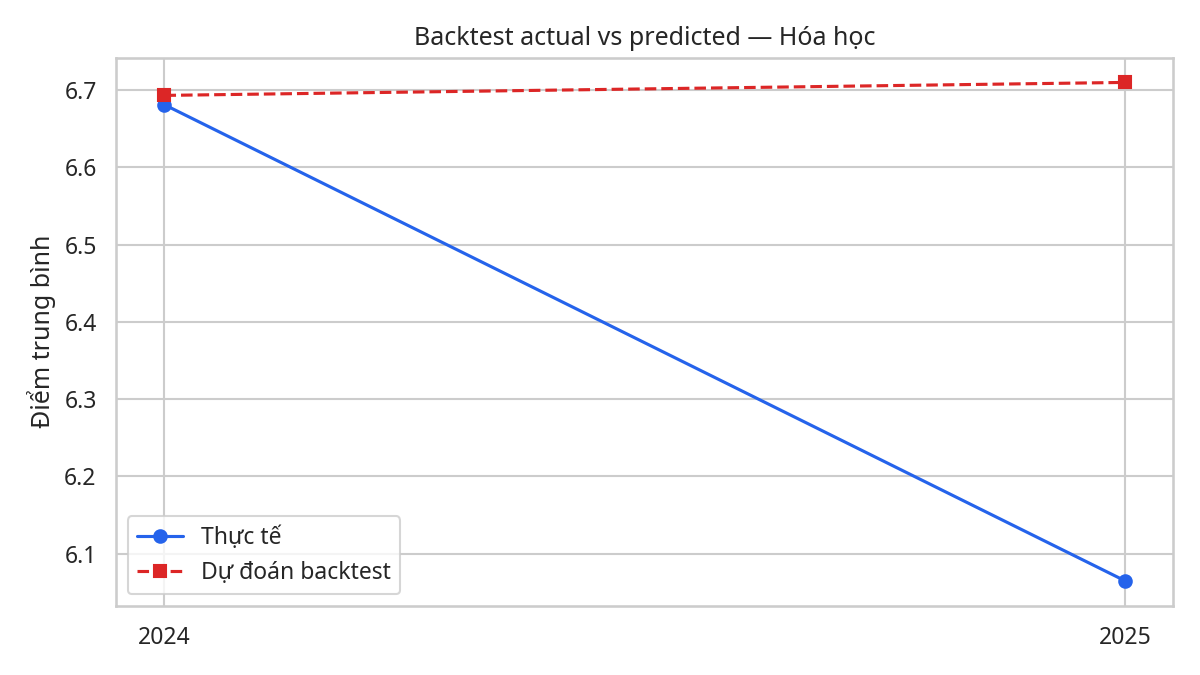

backtest_actual_vs_predicted_NgoaiNgu.png


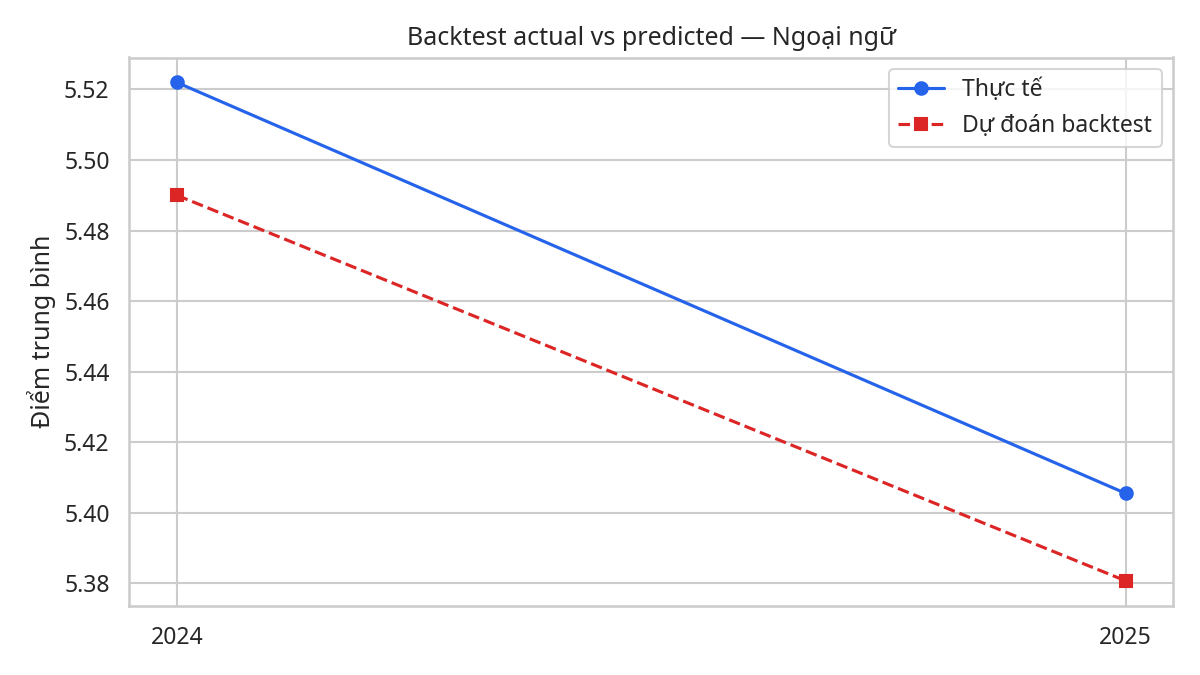

backtest_actual_vs_predicted_NguVan.png


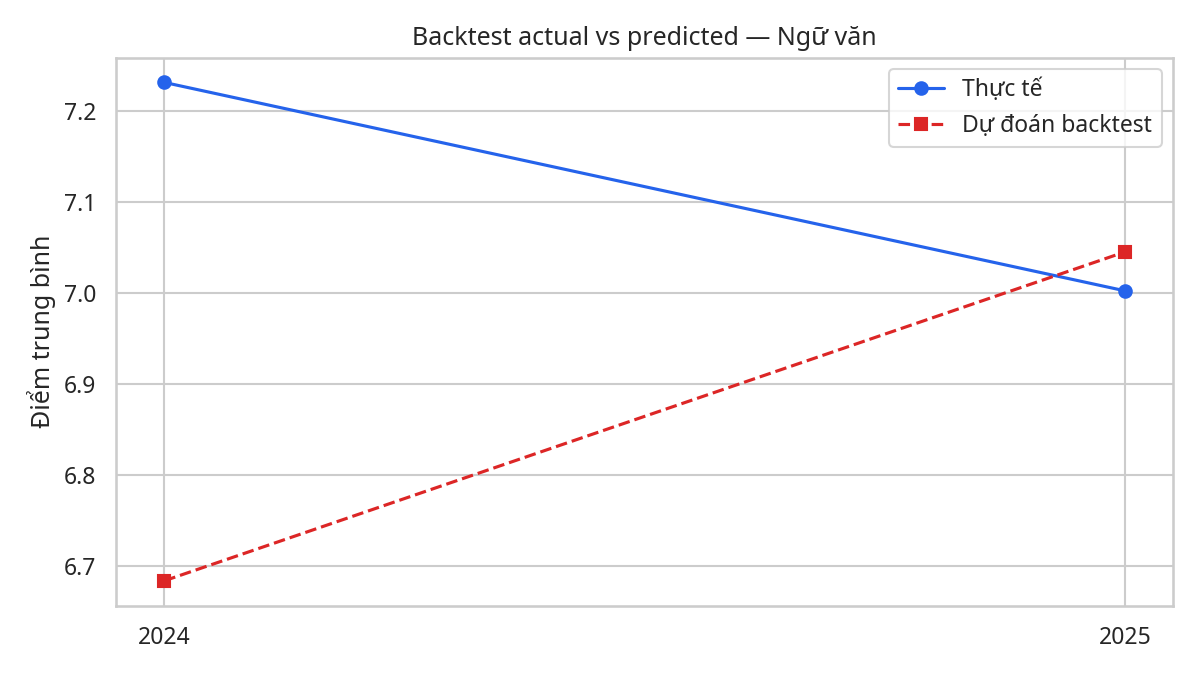

backtest_actual_vs_predicted_SinhHoc.png


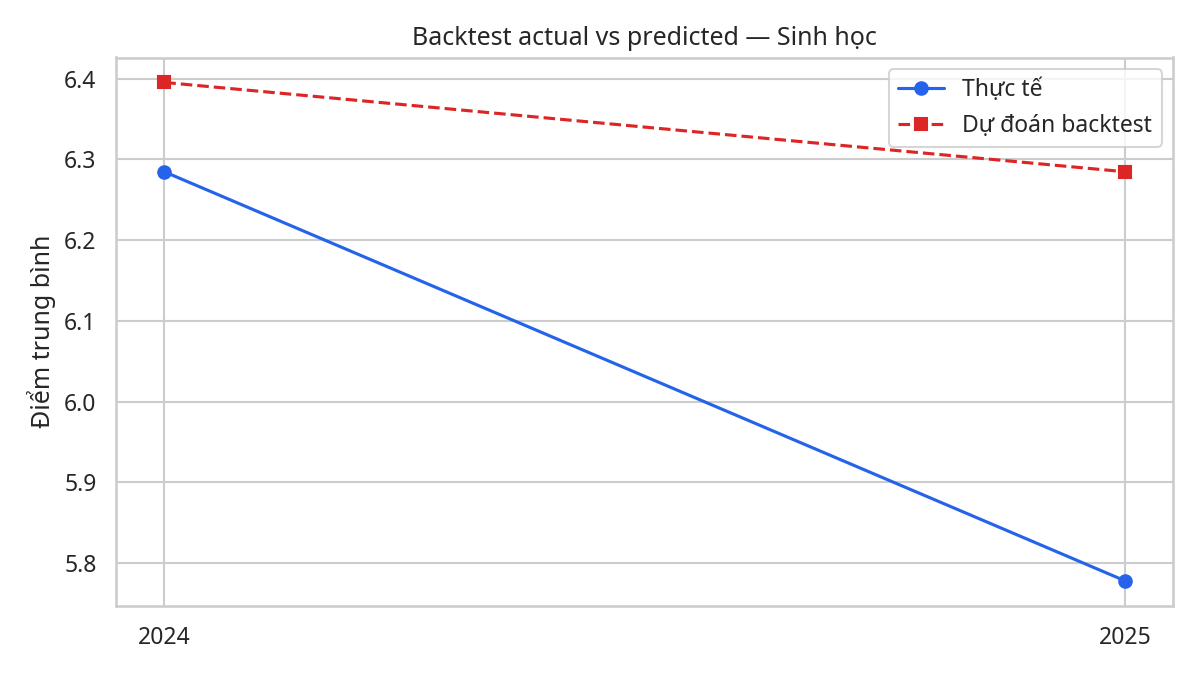

backtest_actual_vs_predicted_Toan.png


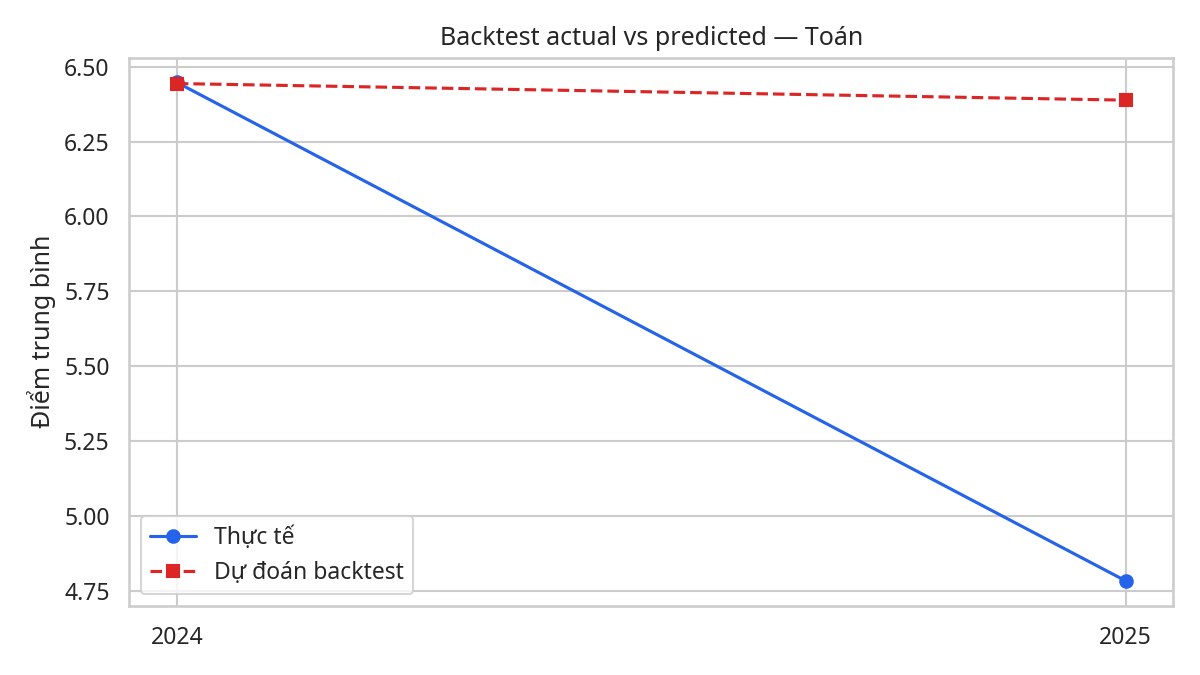

backtest_actual_vs_predicted_VatLy.png


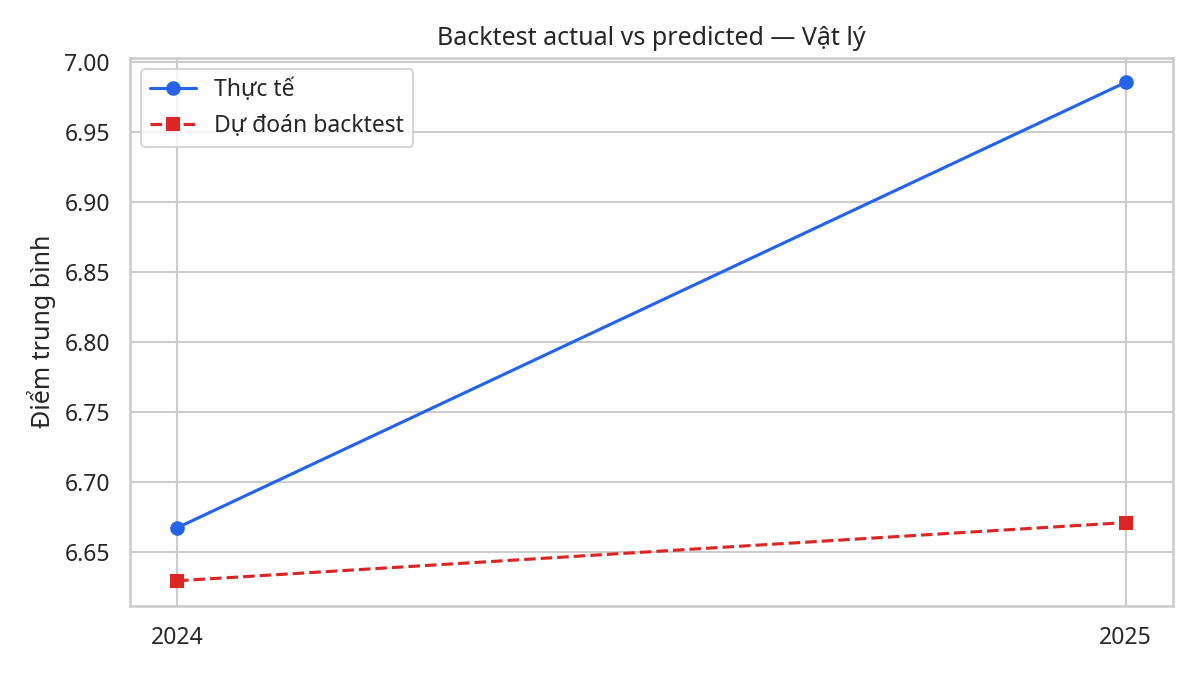

boxplot_CongNgheCongNghiep_by_year.png


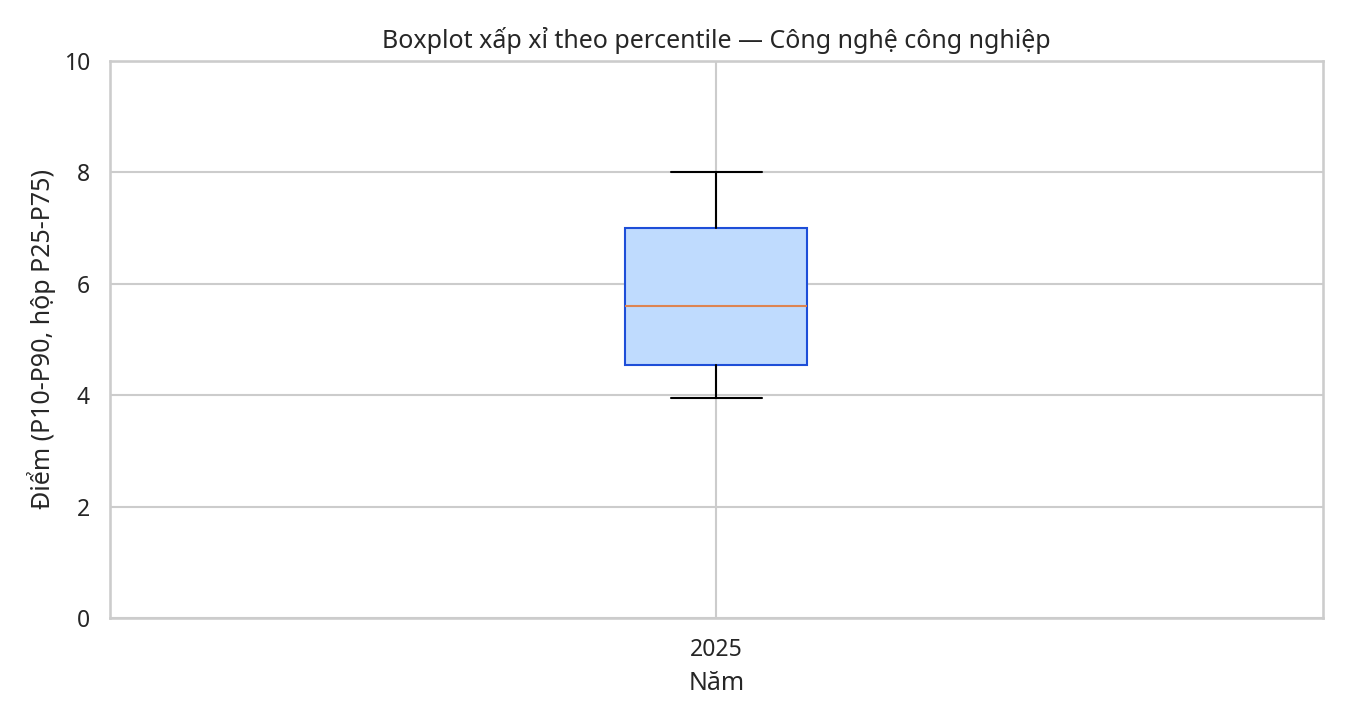

boxplot_CongNgheNongNghiep_by_year.png


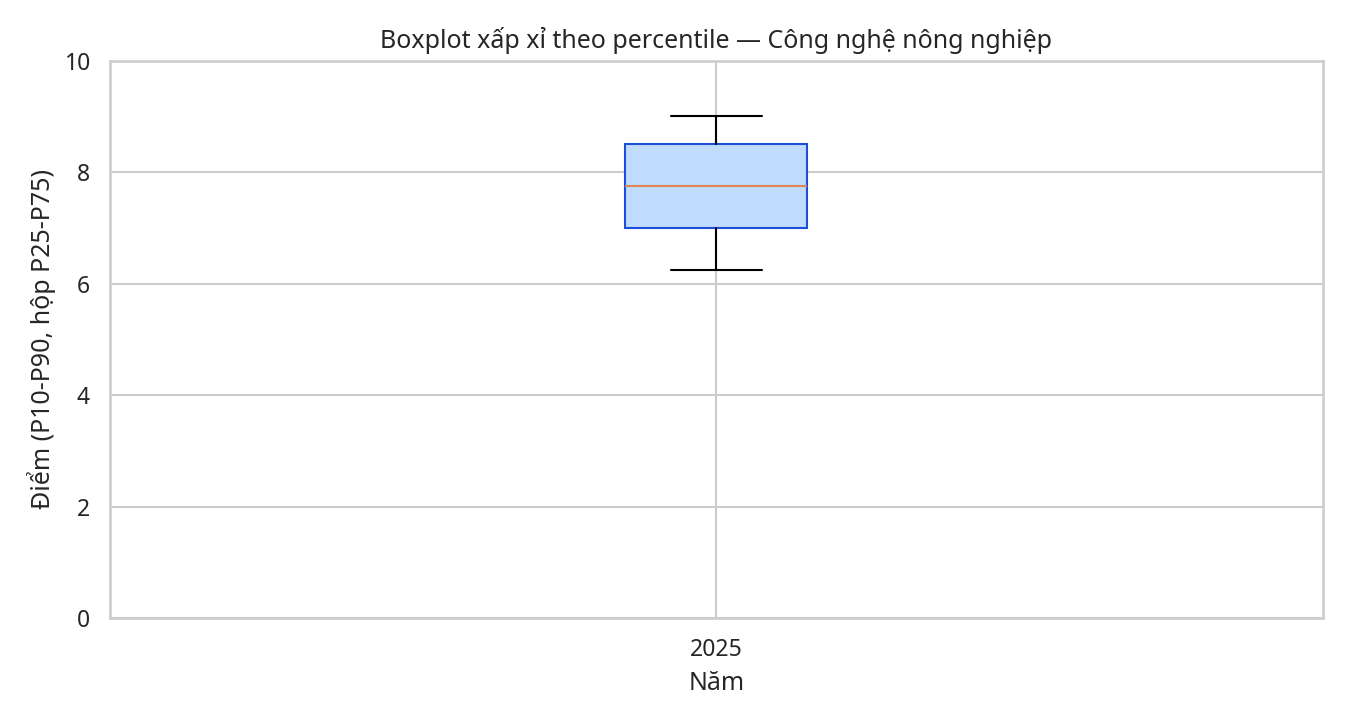

boxplot_DiaLy_by_year.png


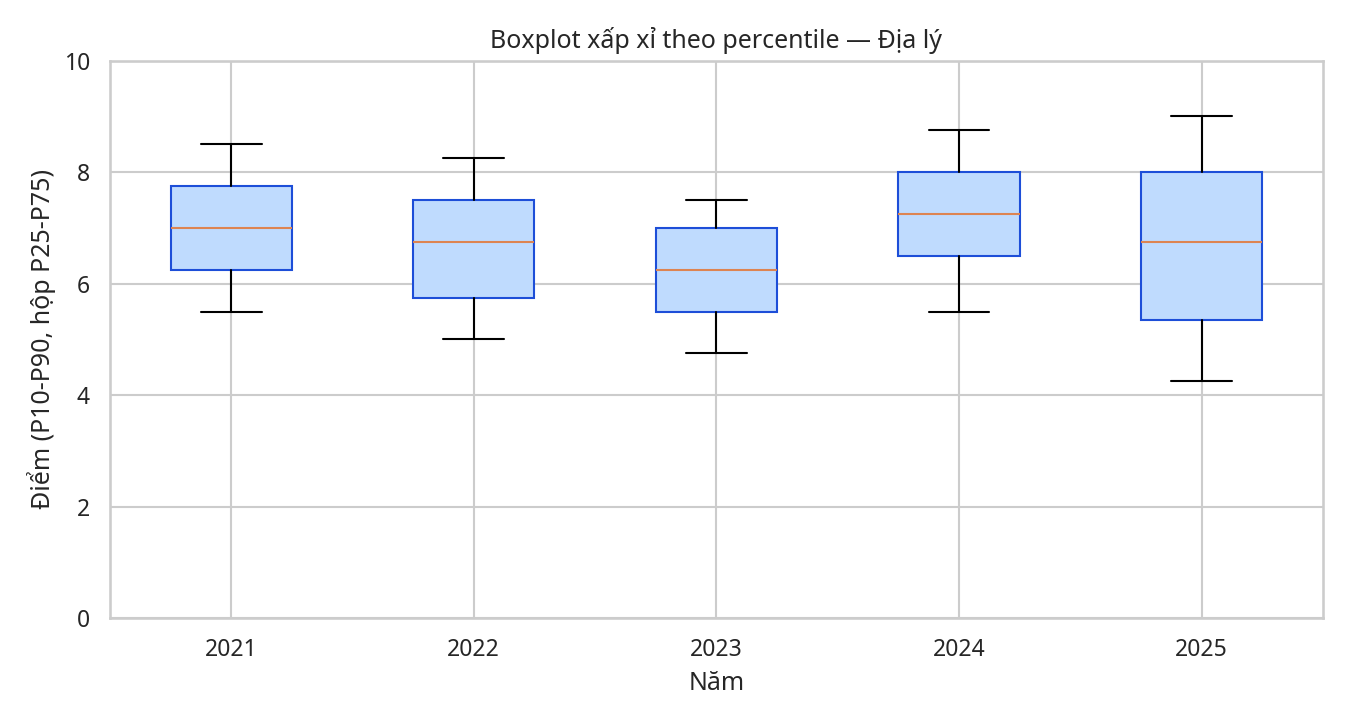

boxplot_GDCD_by_year.png


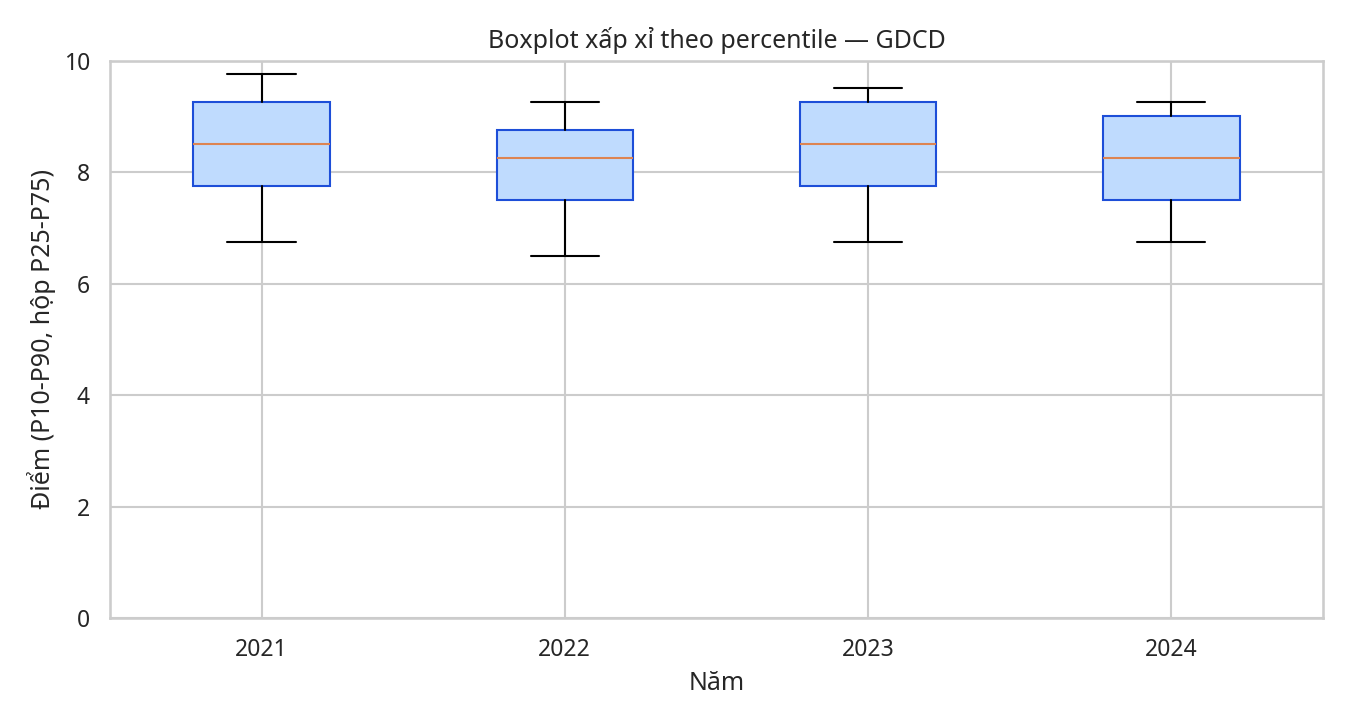

boxplot_HoaHoc_by_year.png


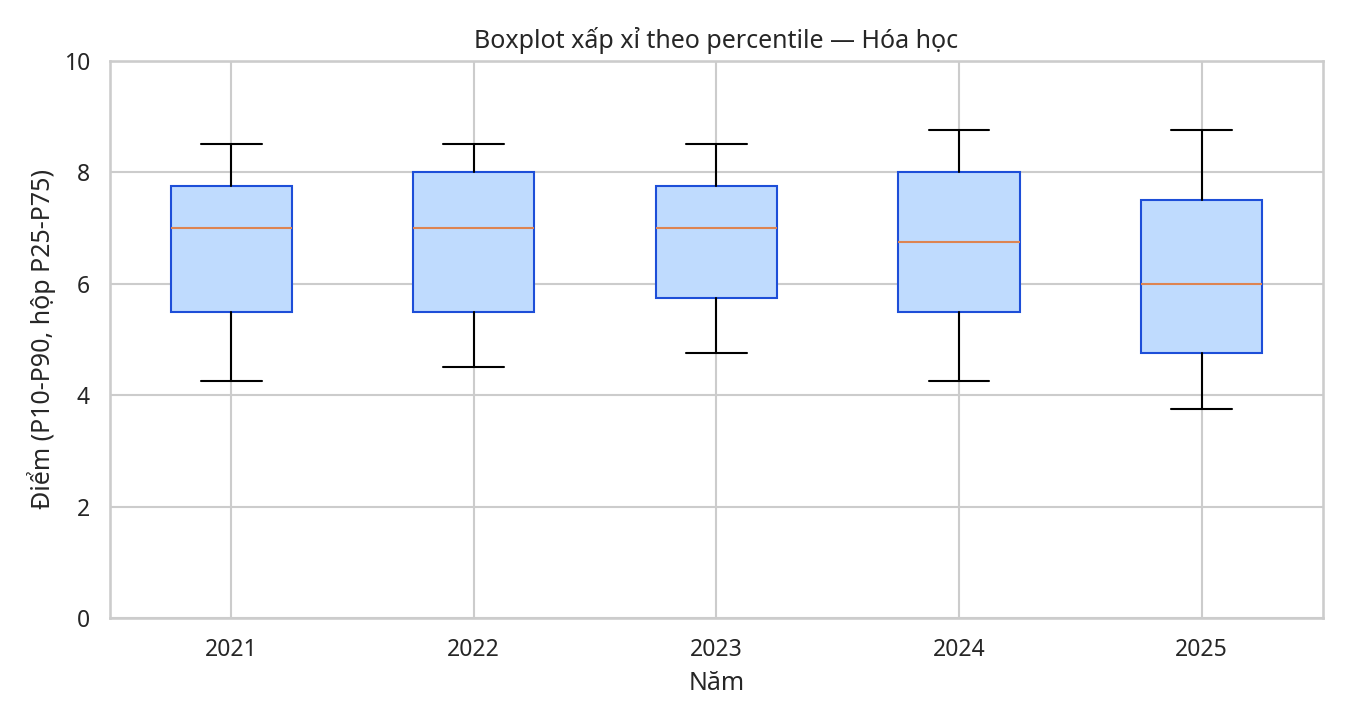

boxplot_KinhTePhapLuat_by_year.png


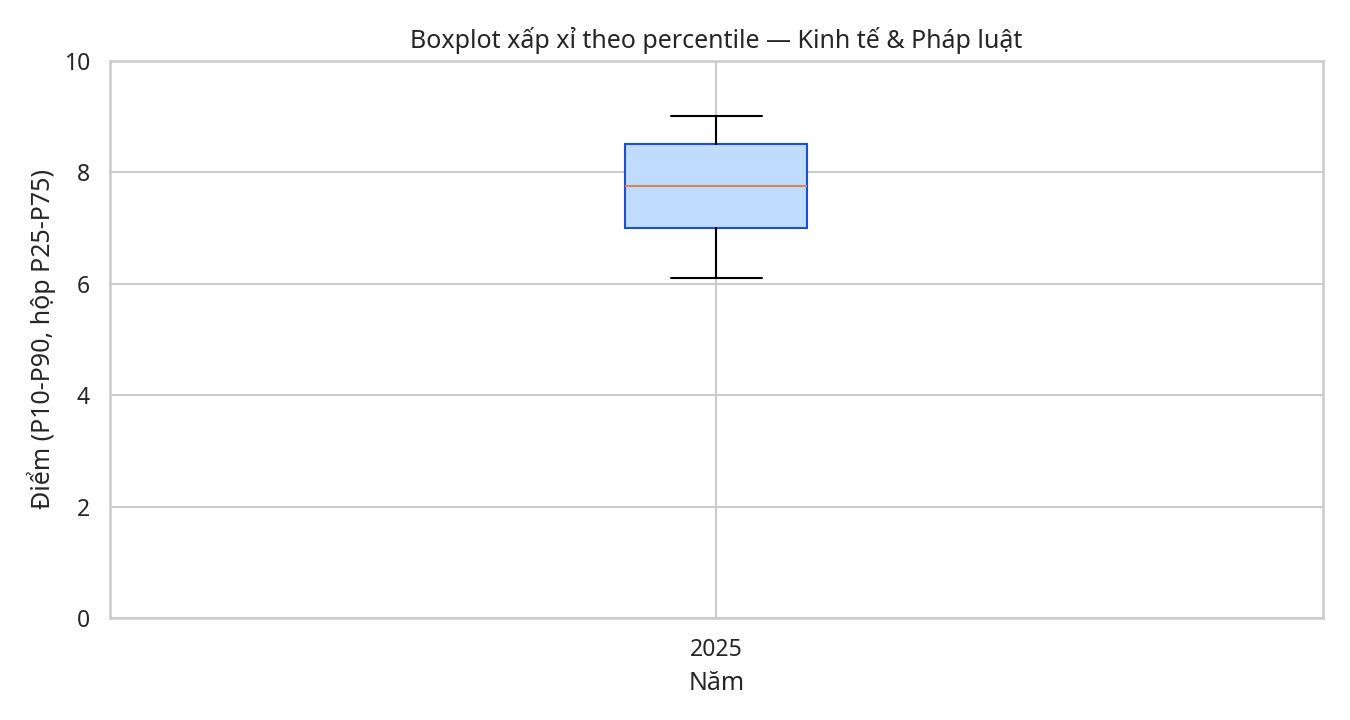

boxplot_LichSu_by_year.png


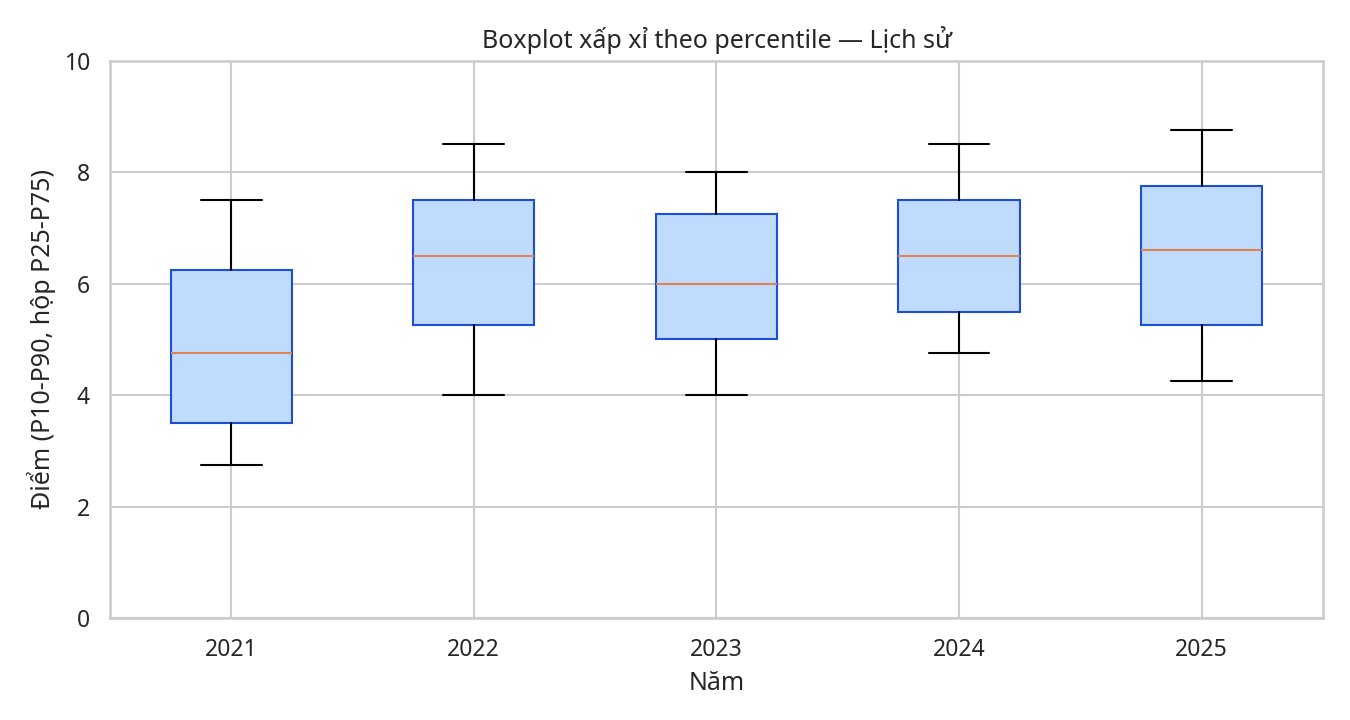

boxplot_NgoaiNgu_by_year.png


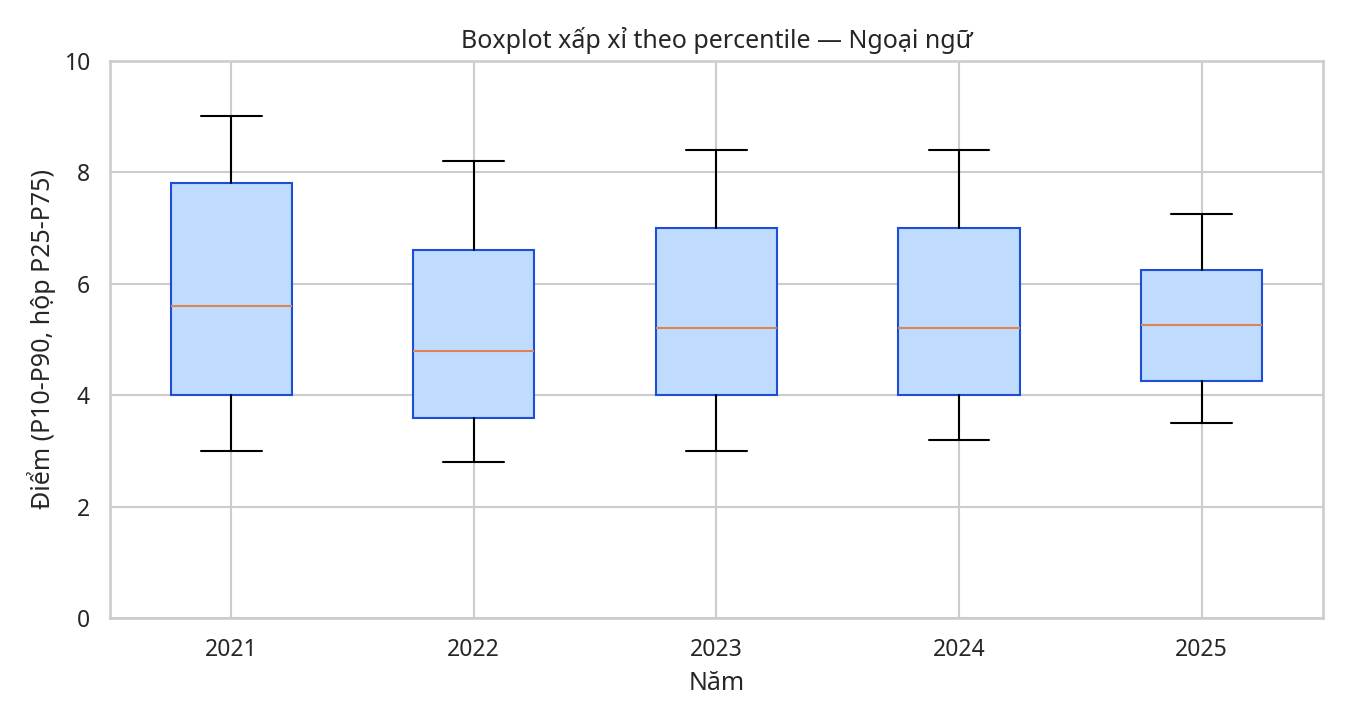

boxplot_NguVan_by_year.png


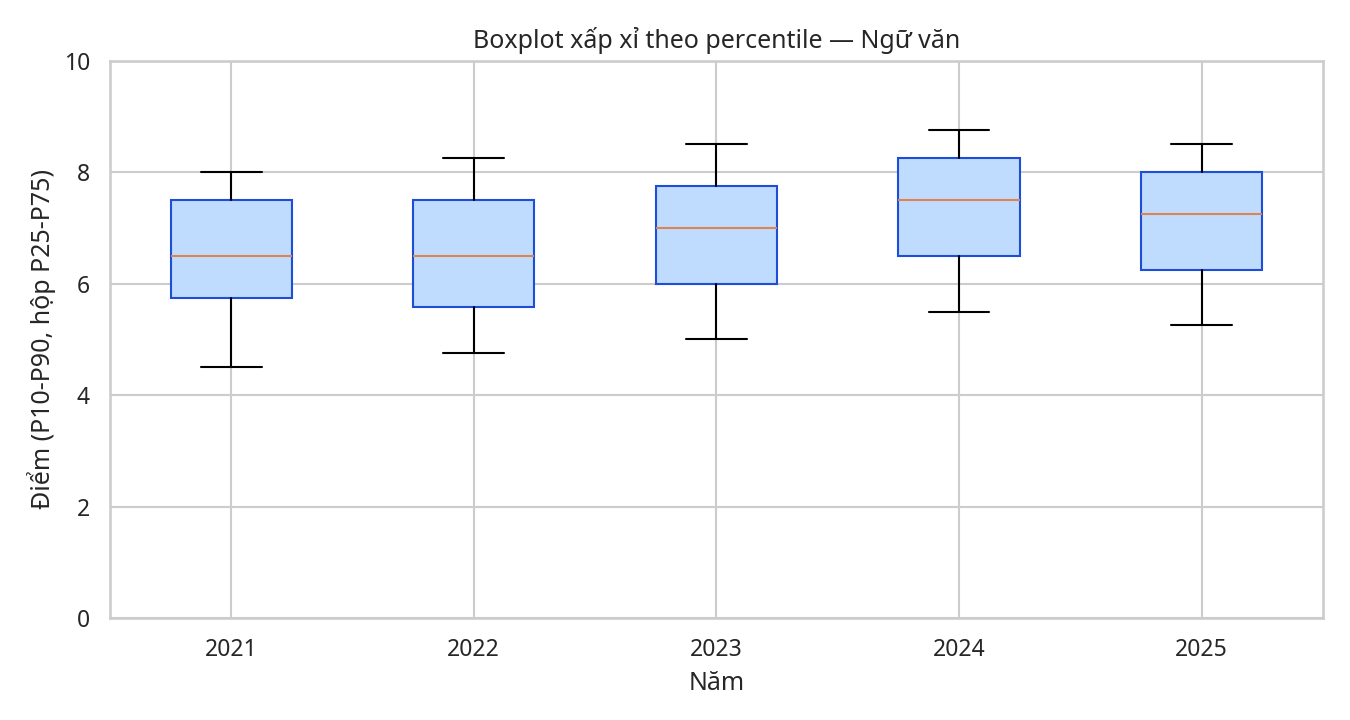

boxplot_SinhHoc_by_year.png


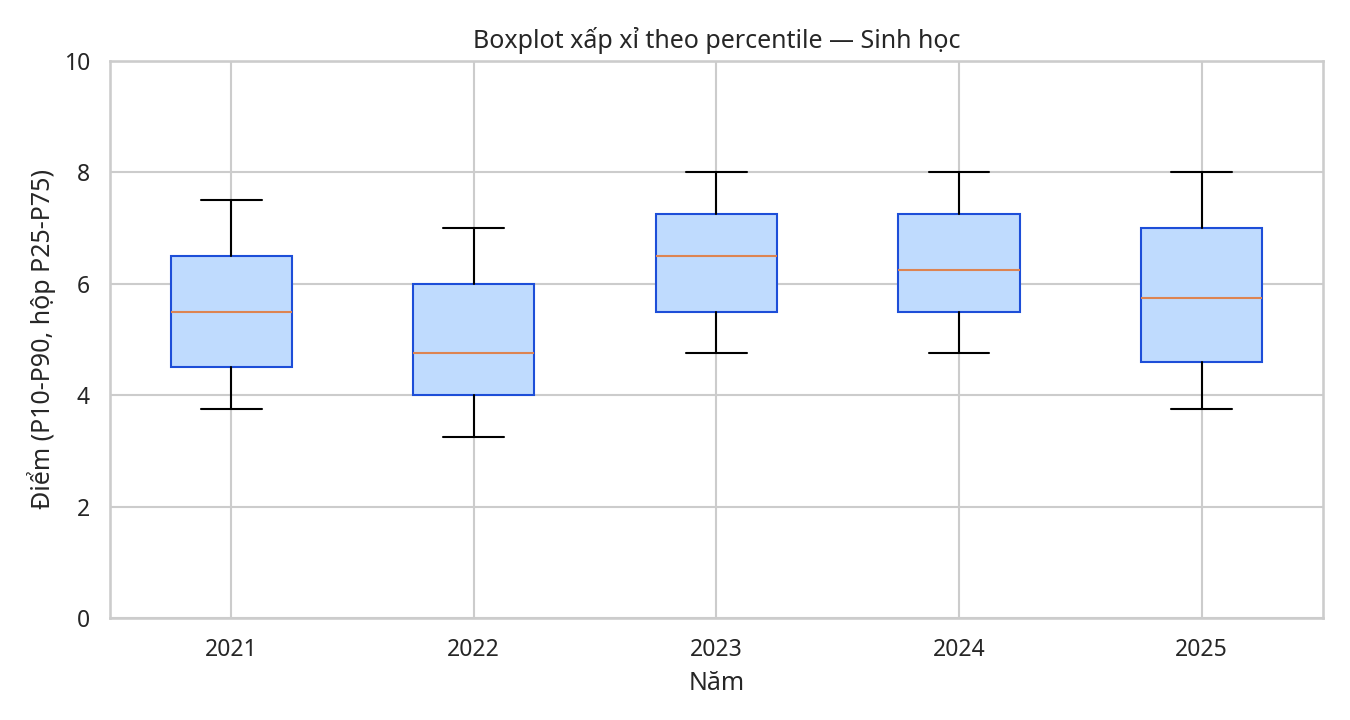

boxplot_TinHoc_by_year.png


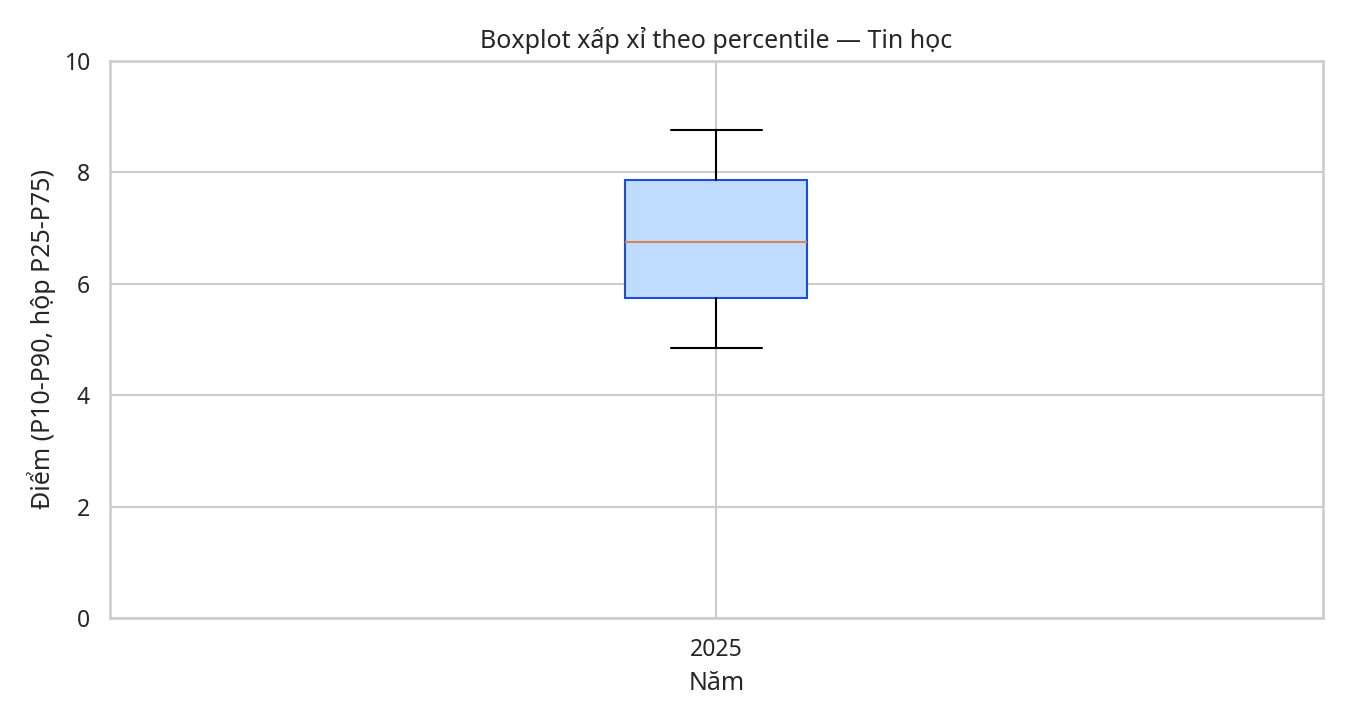

boxplot_Toan_by_year.png


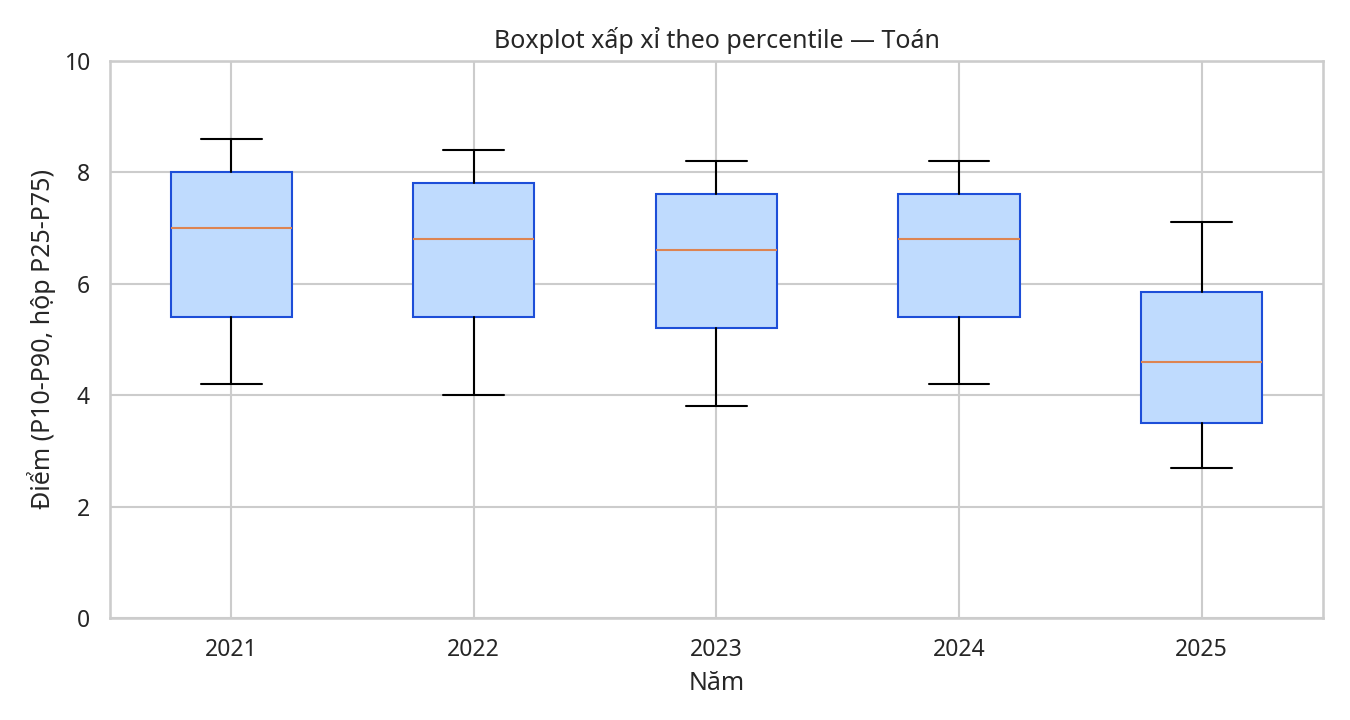

boxplot_VatLy_by_year.png


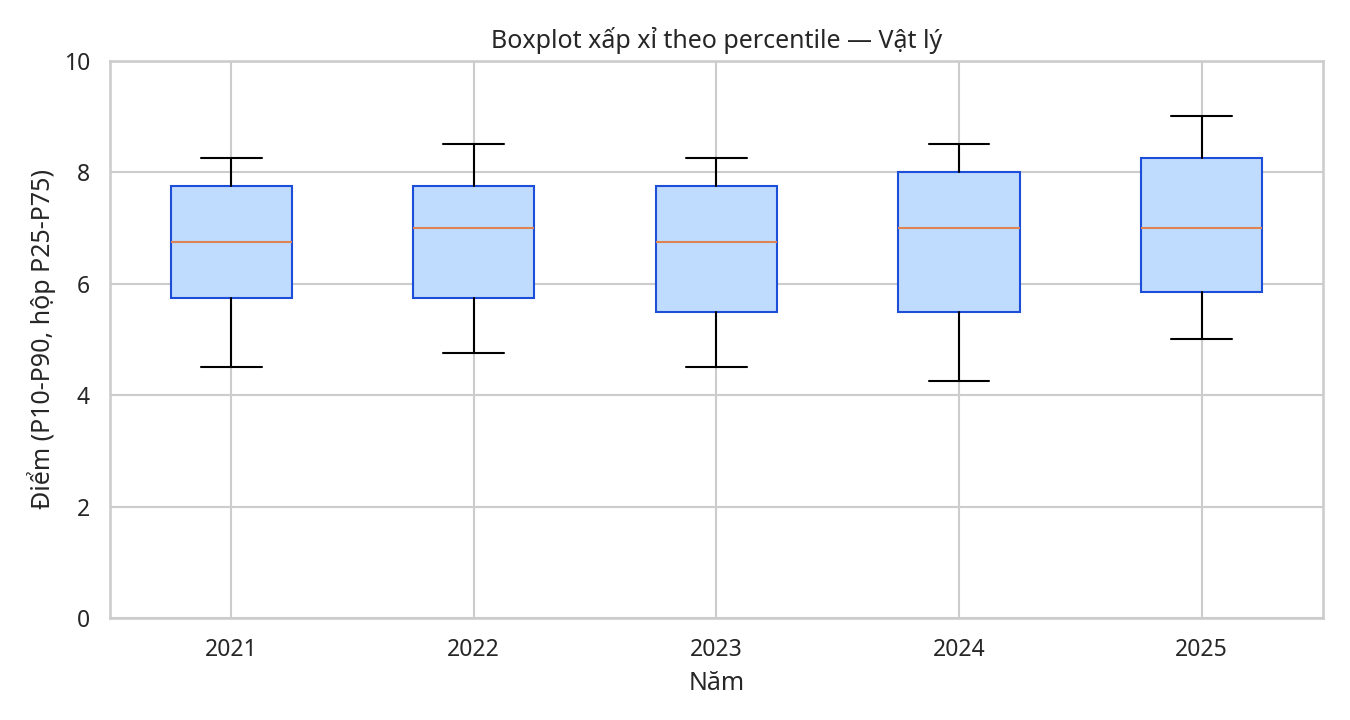

candidates_by_year.png


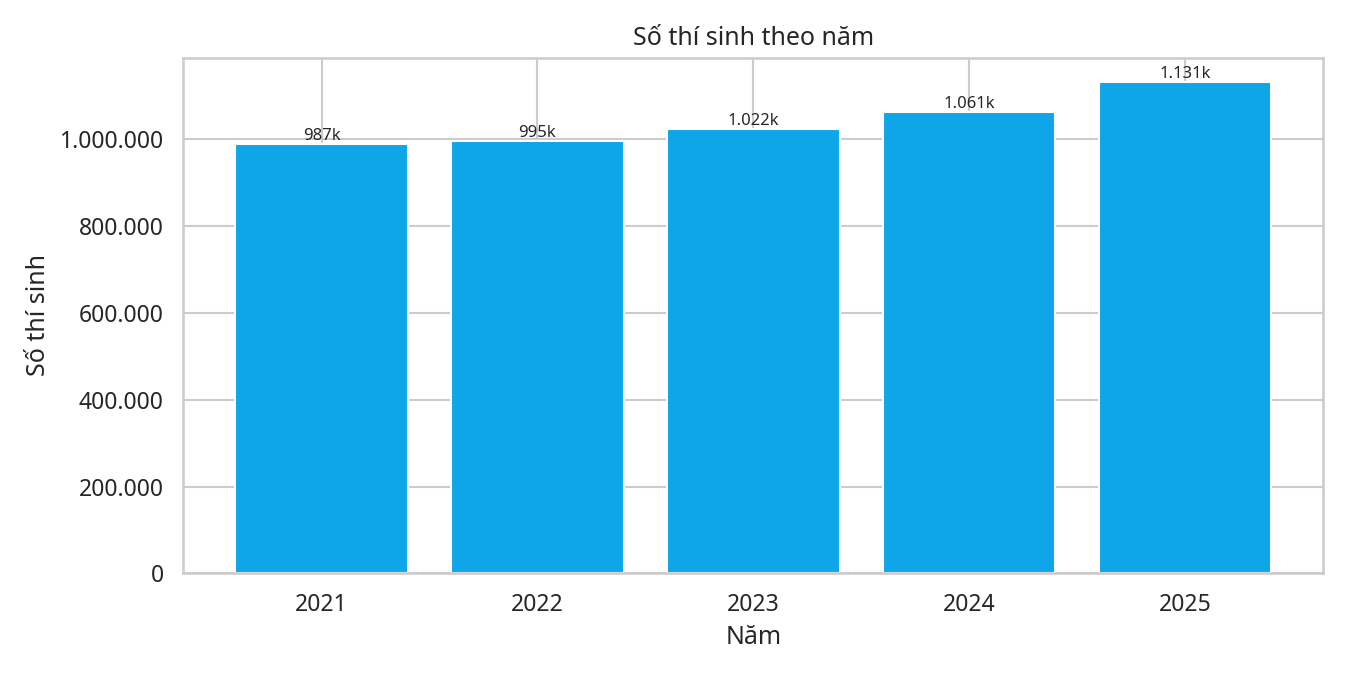

combination_trends.png


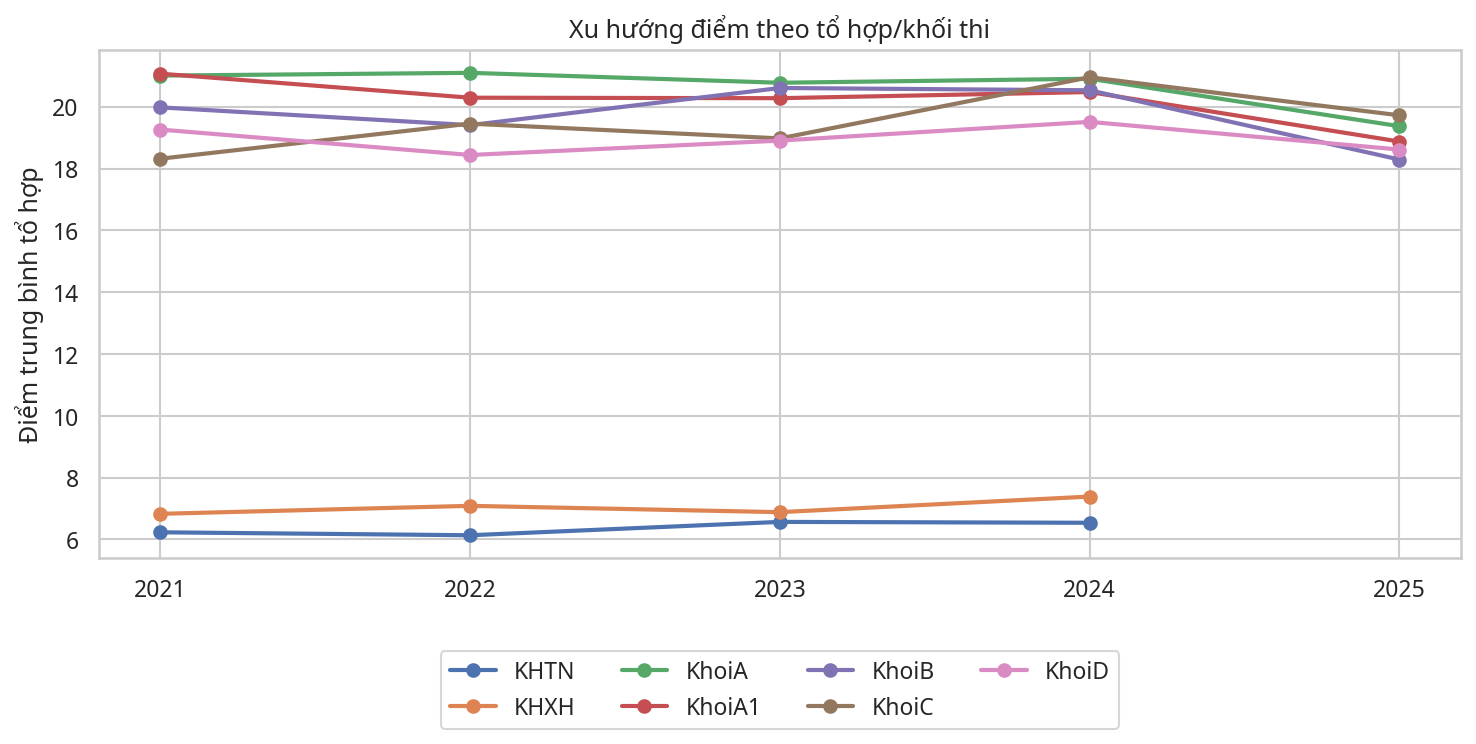

correlation_heatmap_2021.png


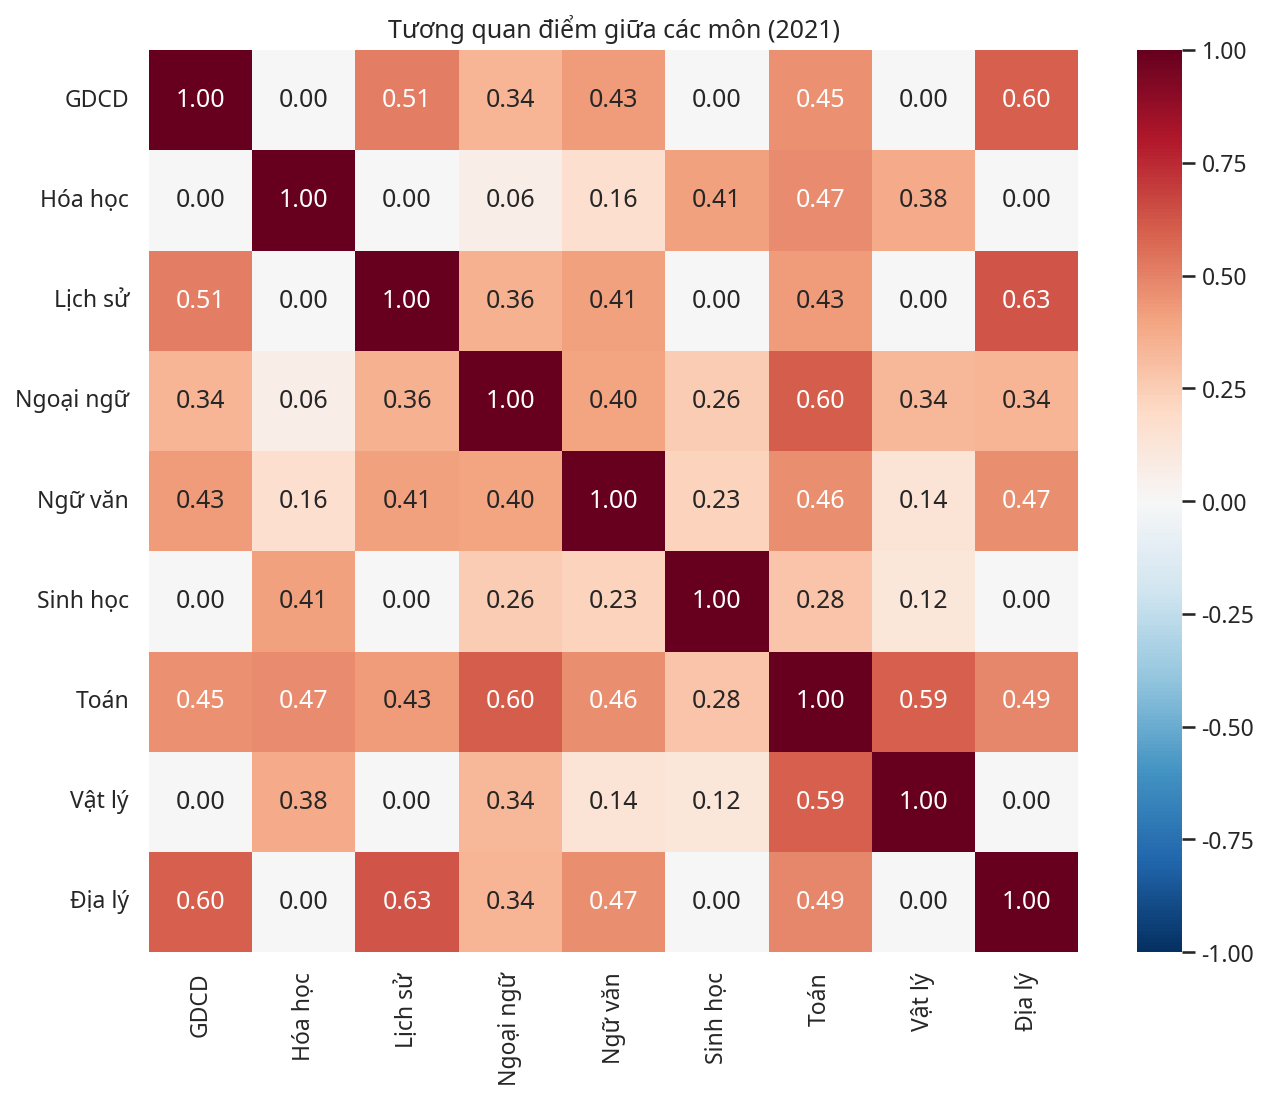

correlation_heatmap_2022.png


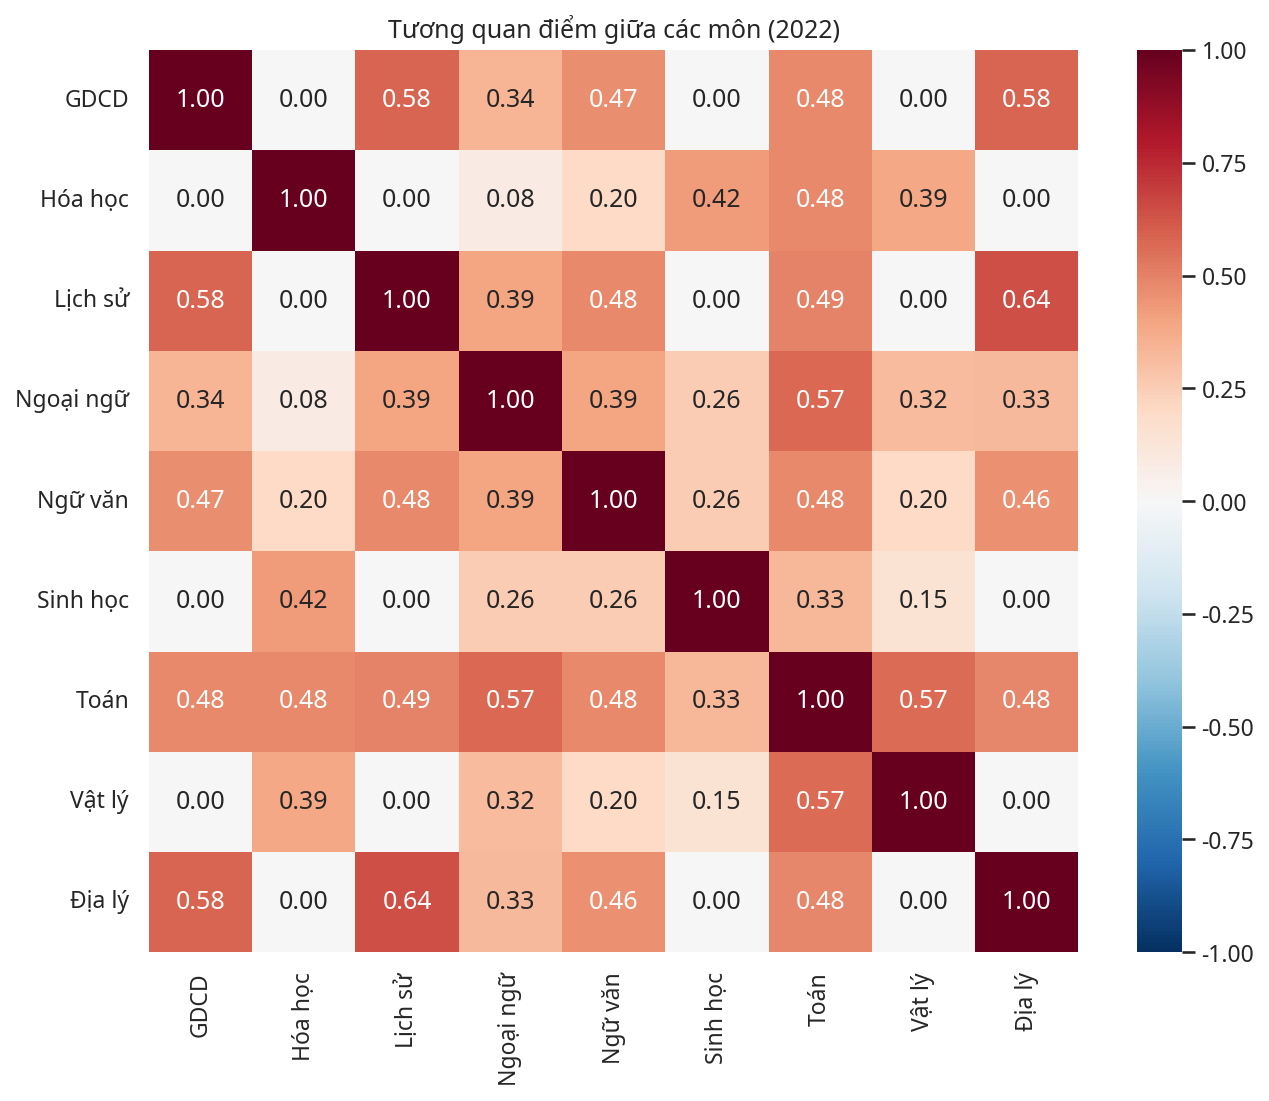

correlation_heatmap_2023.png


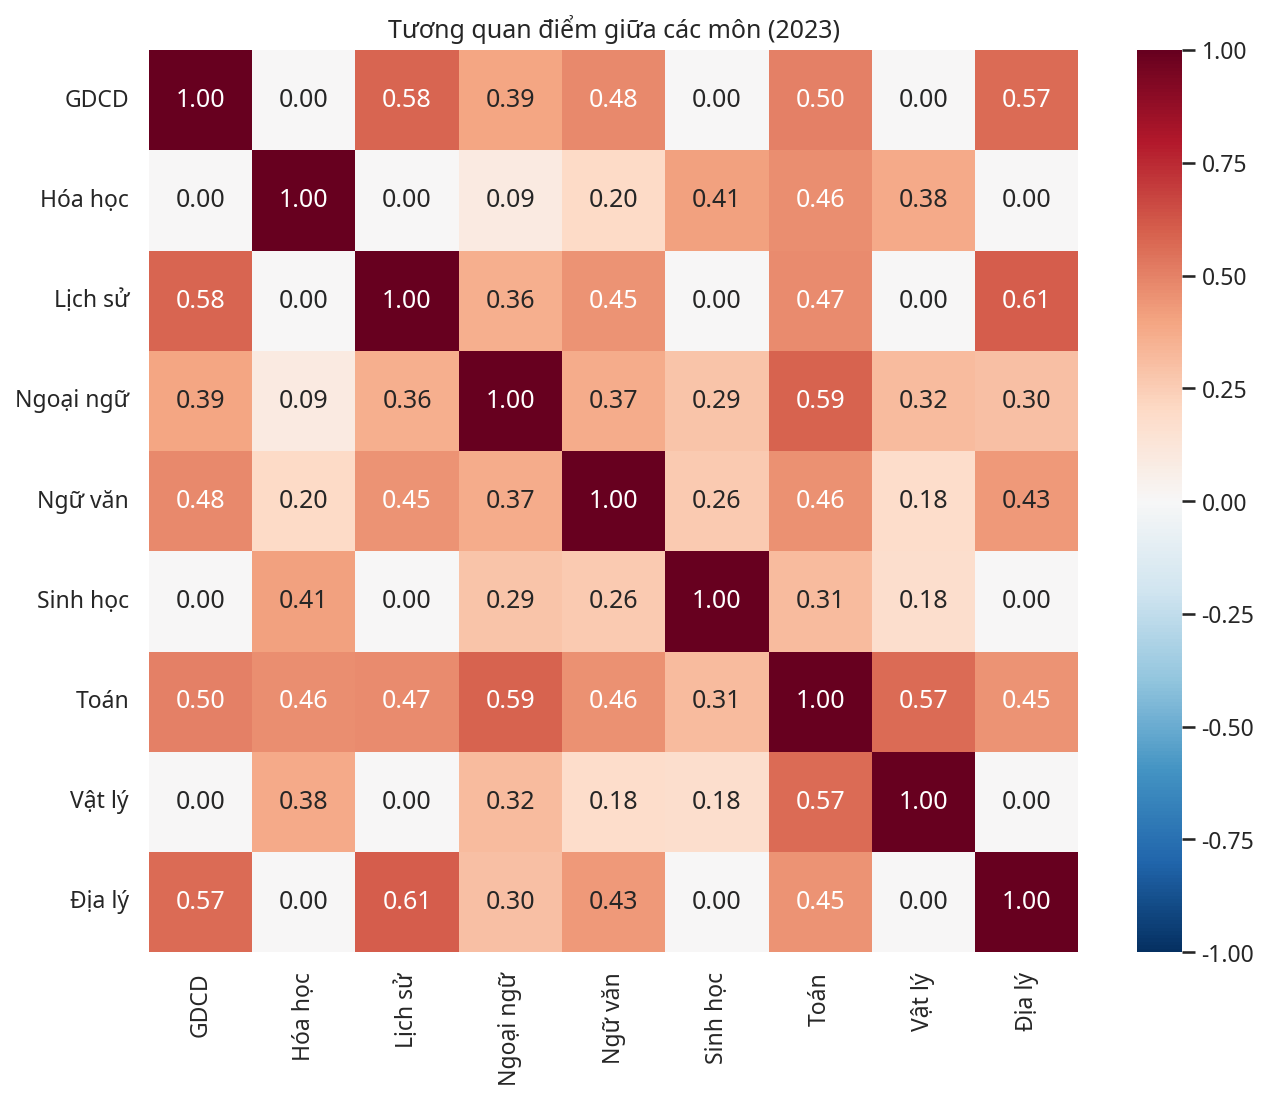

correlation_heatmap_2024.png


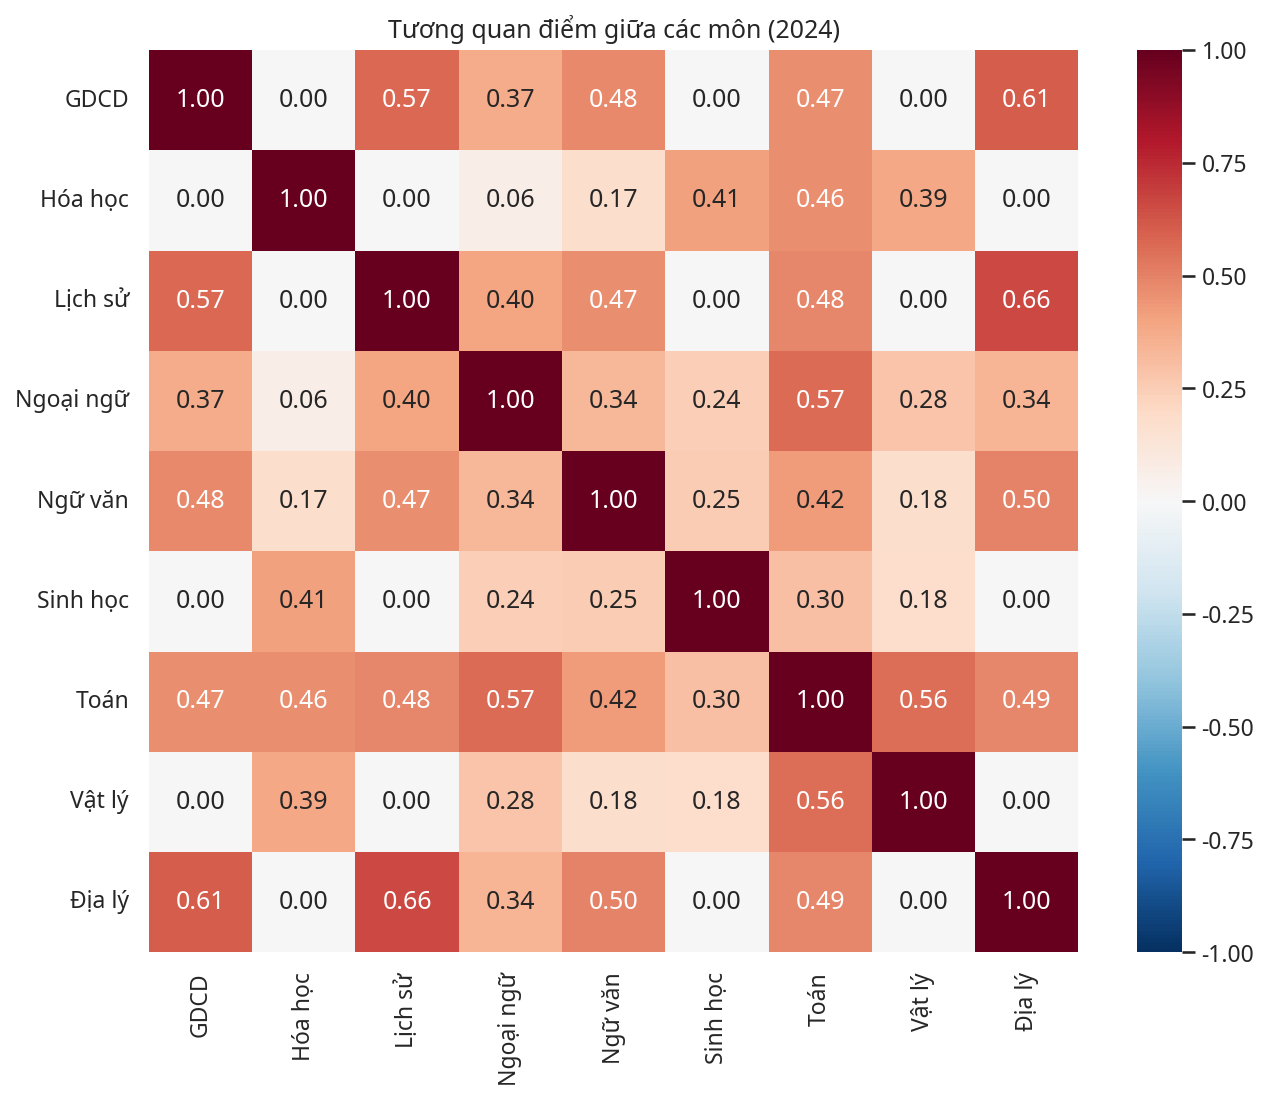

correlation_heatmap_2025.png


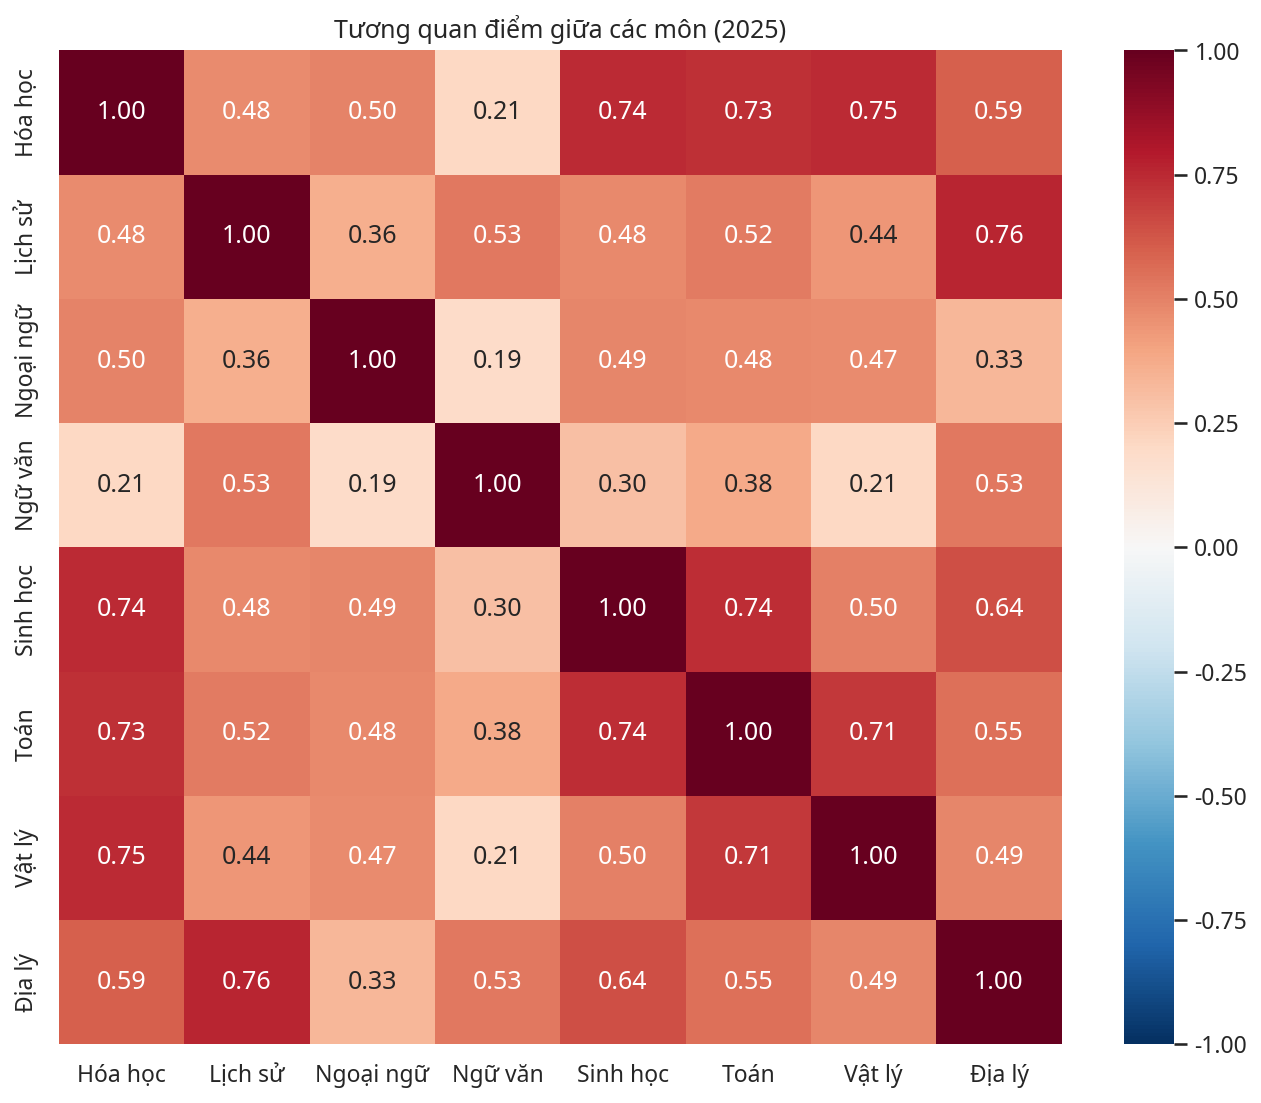

data_quality_missingness.png


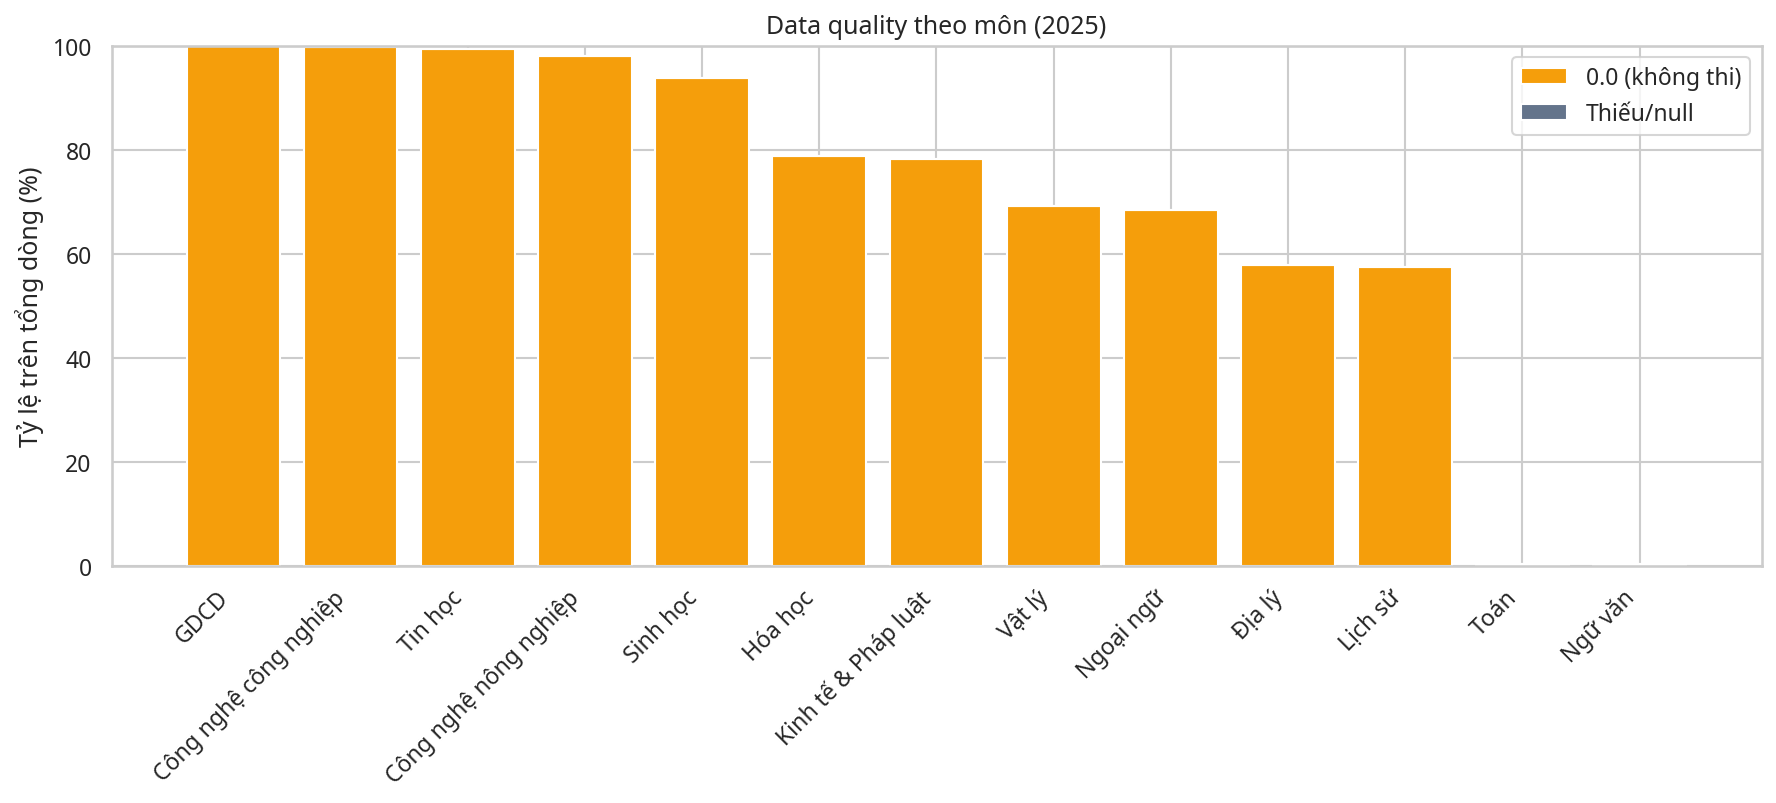

forecast_HoaHoc.png


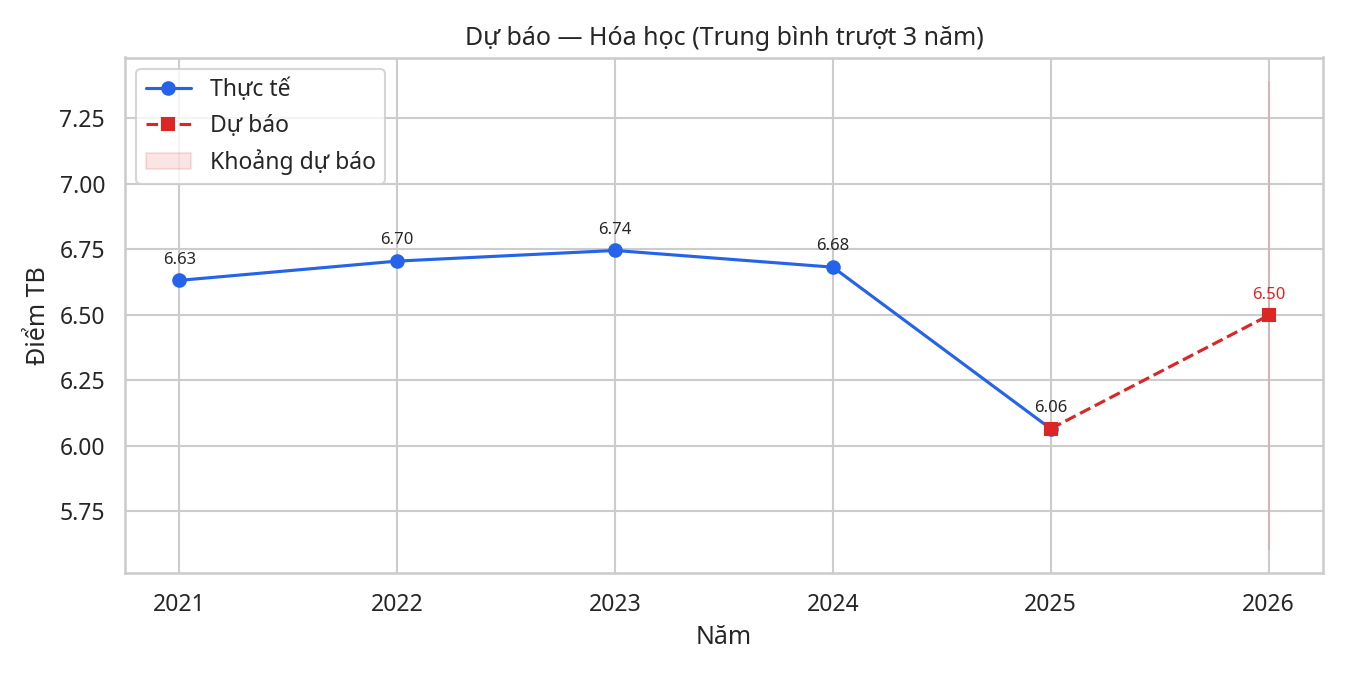

forecast_NgoaiNgu.png


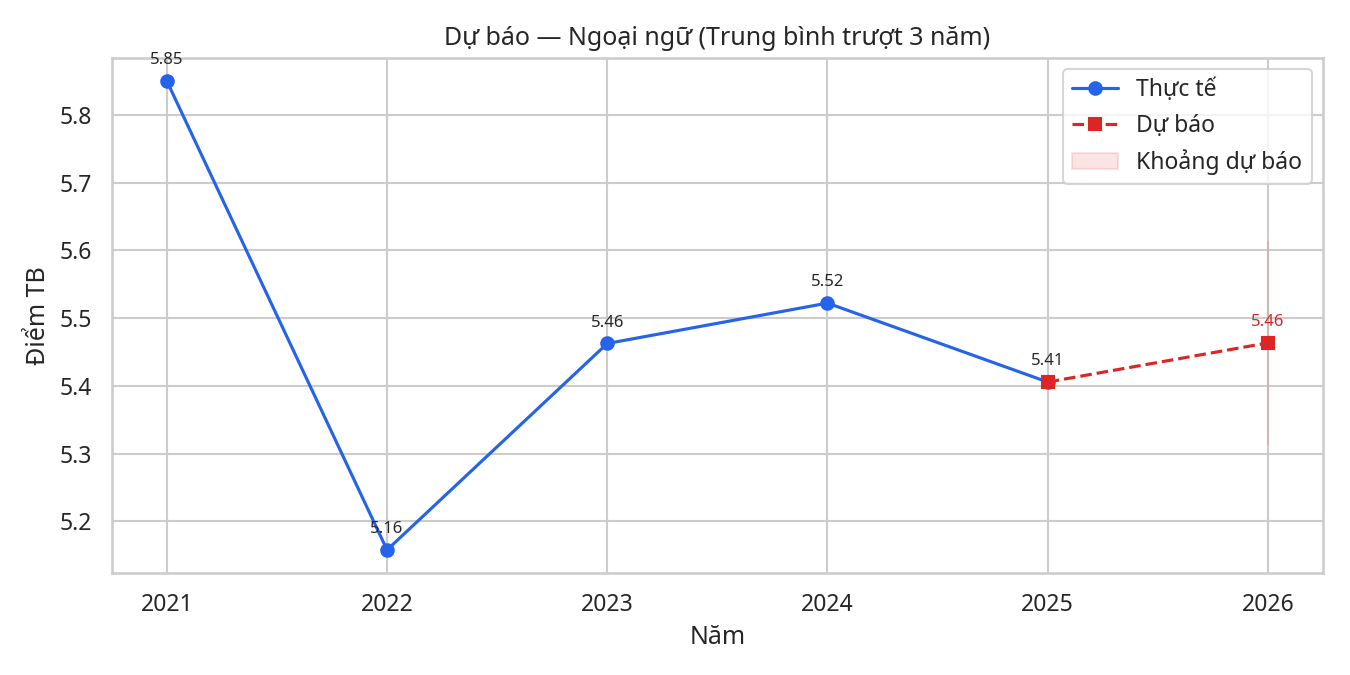

forecast_NguVan.png


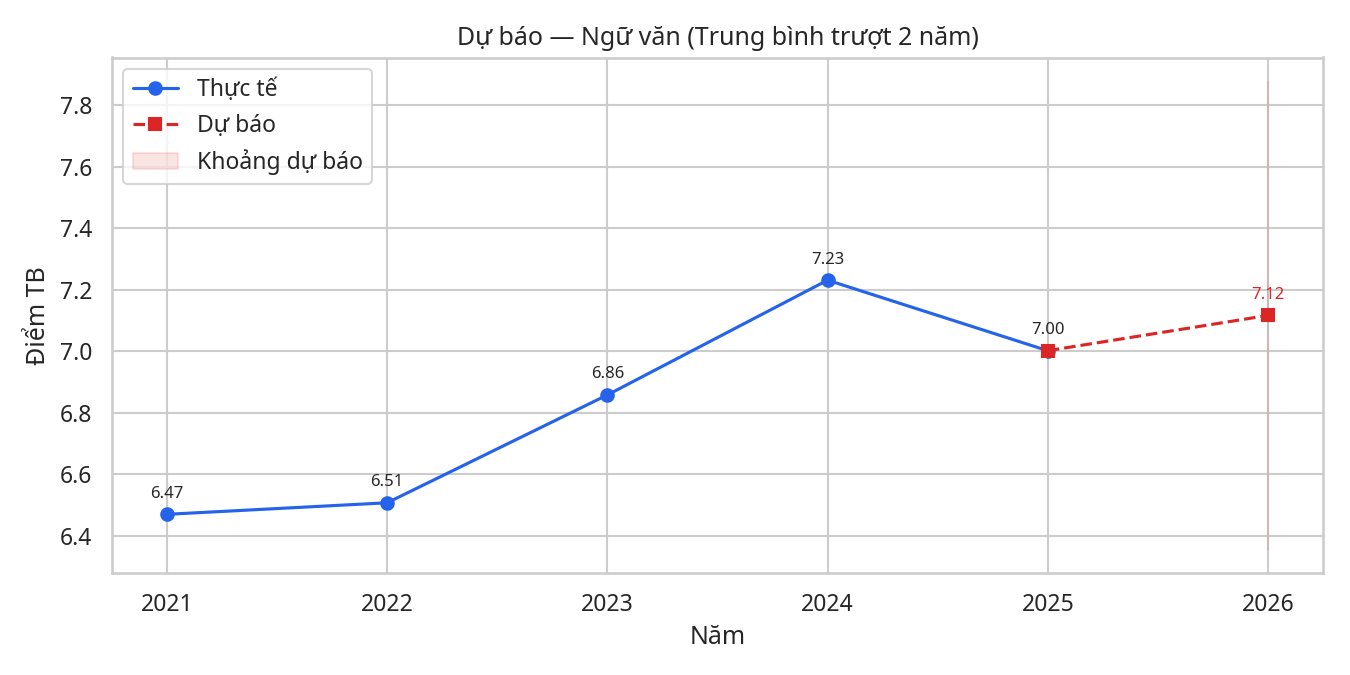

forecast_SinhHoc.png


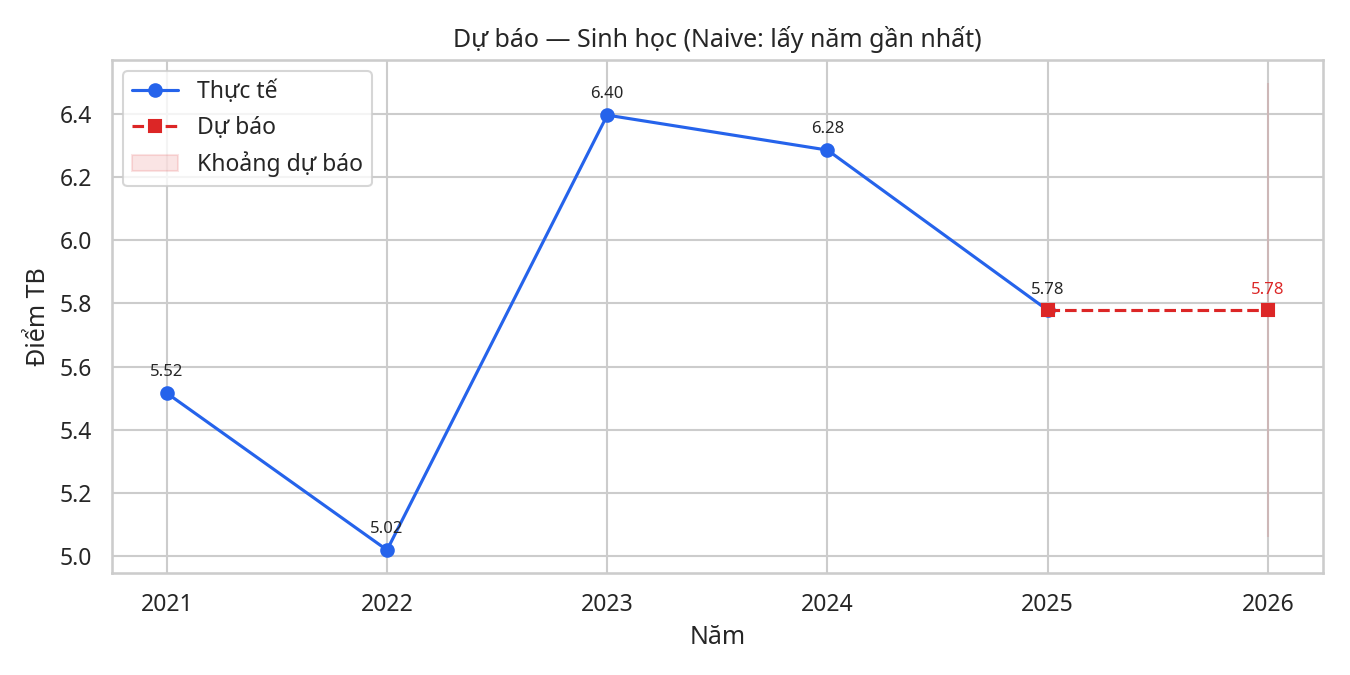

forecast_Toan.png


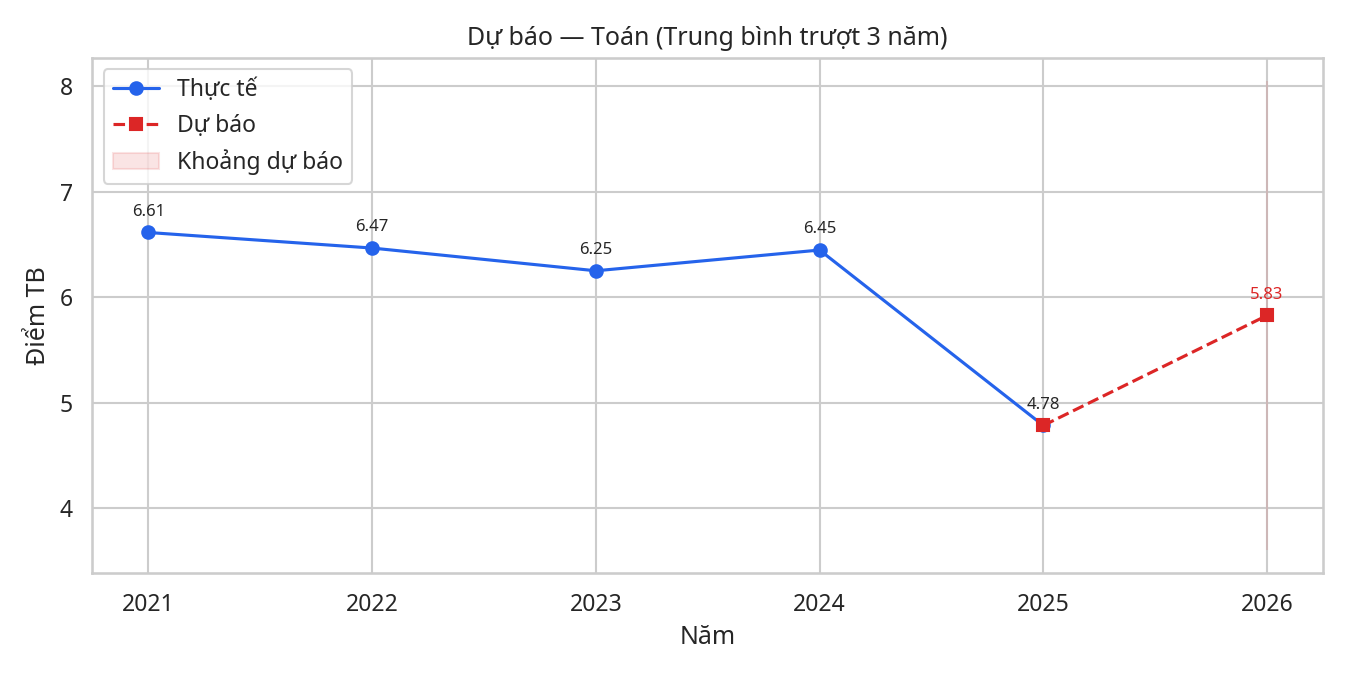

forecast_VatLy.png


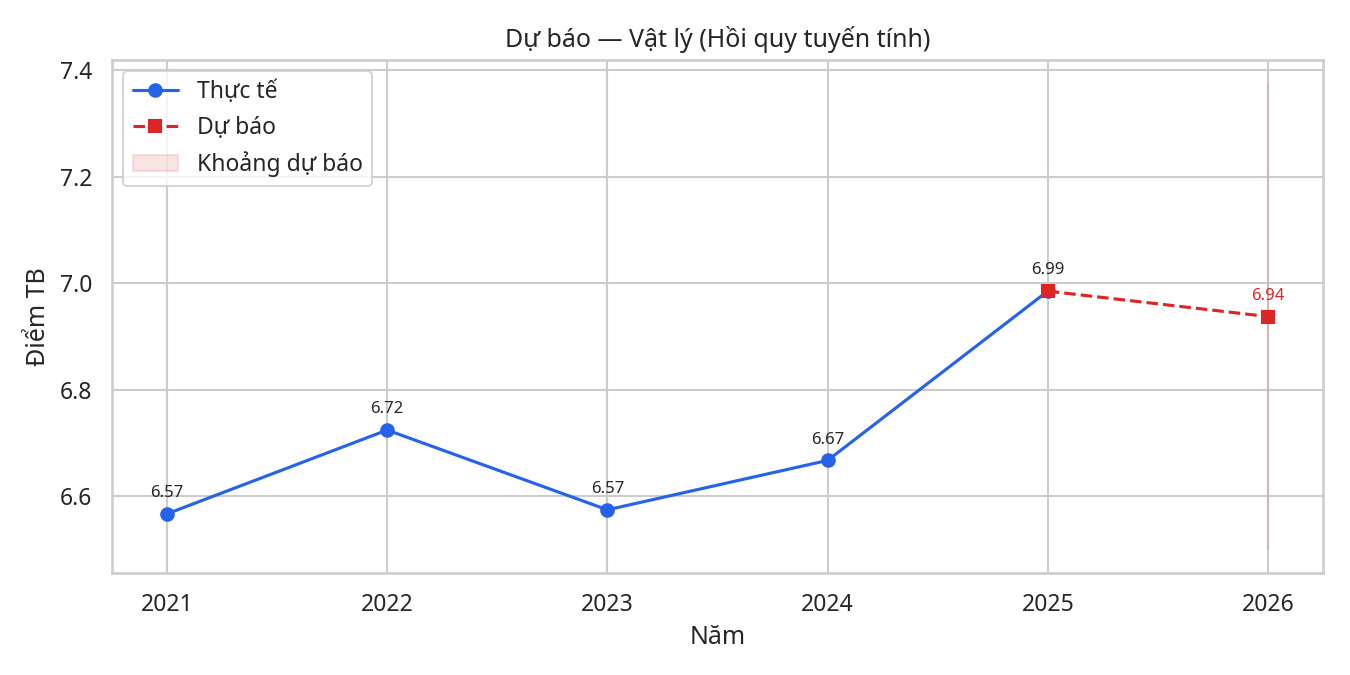

heatmap_HoaHoc_2025.png


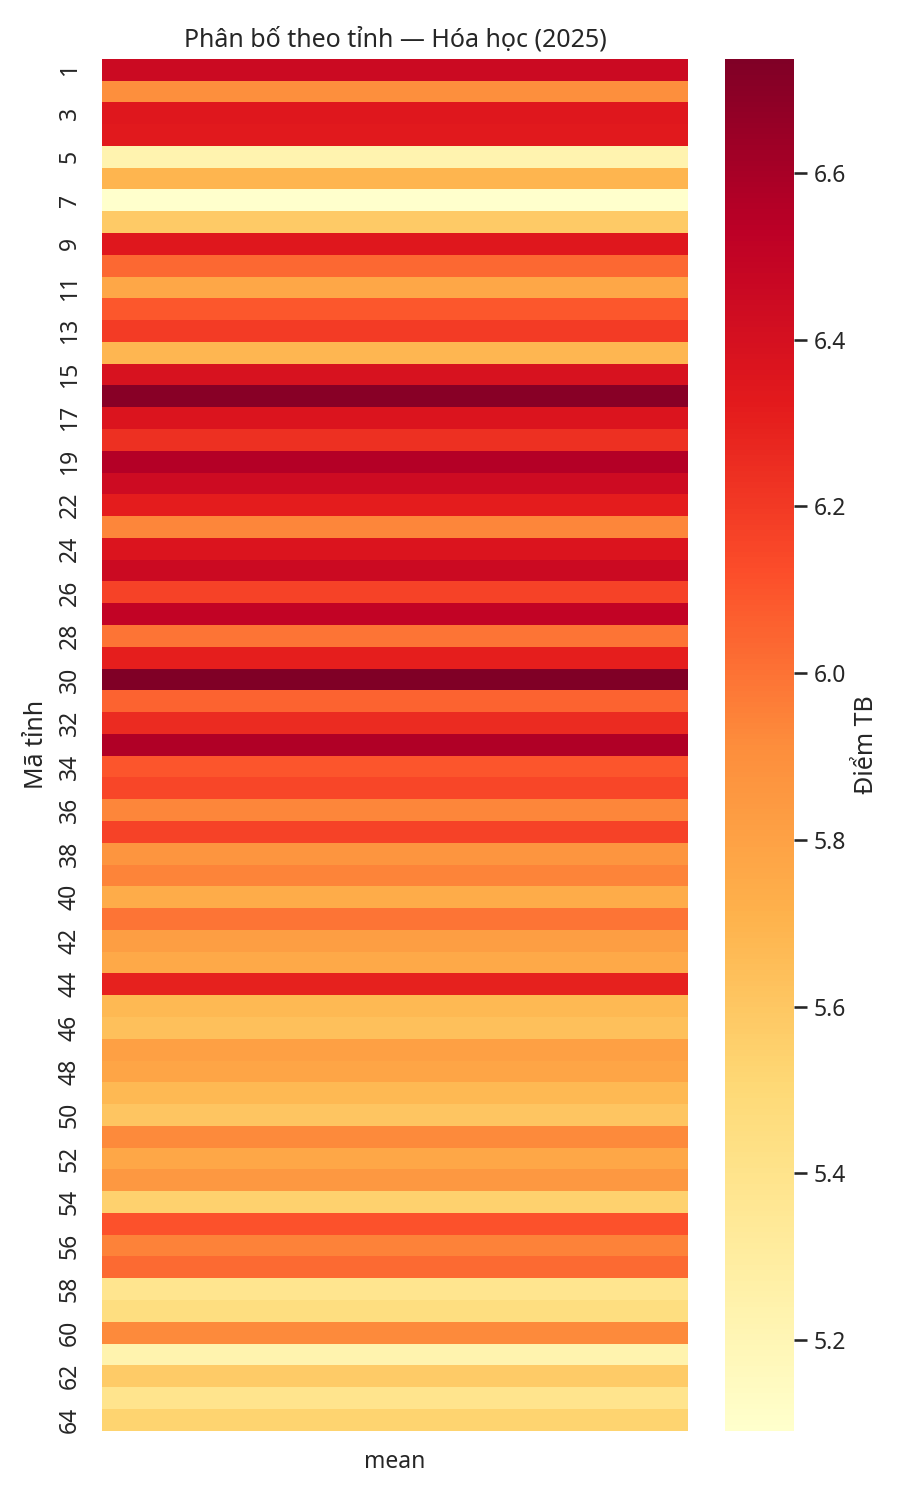

heatmap_NgoaiNgu_2025.png


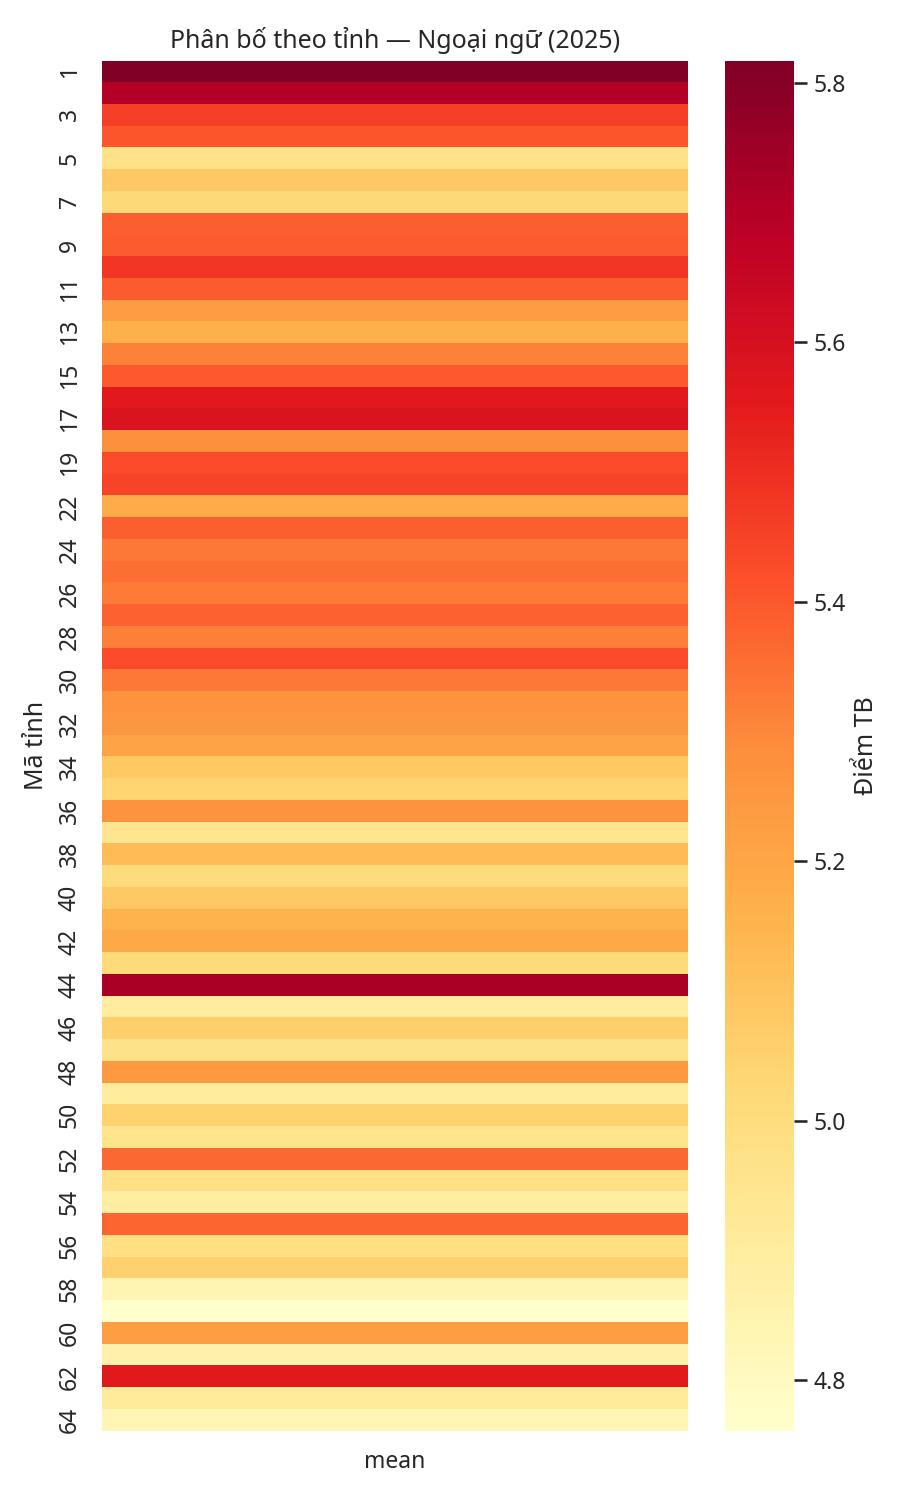

heatmap_NguVan_2025.png


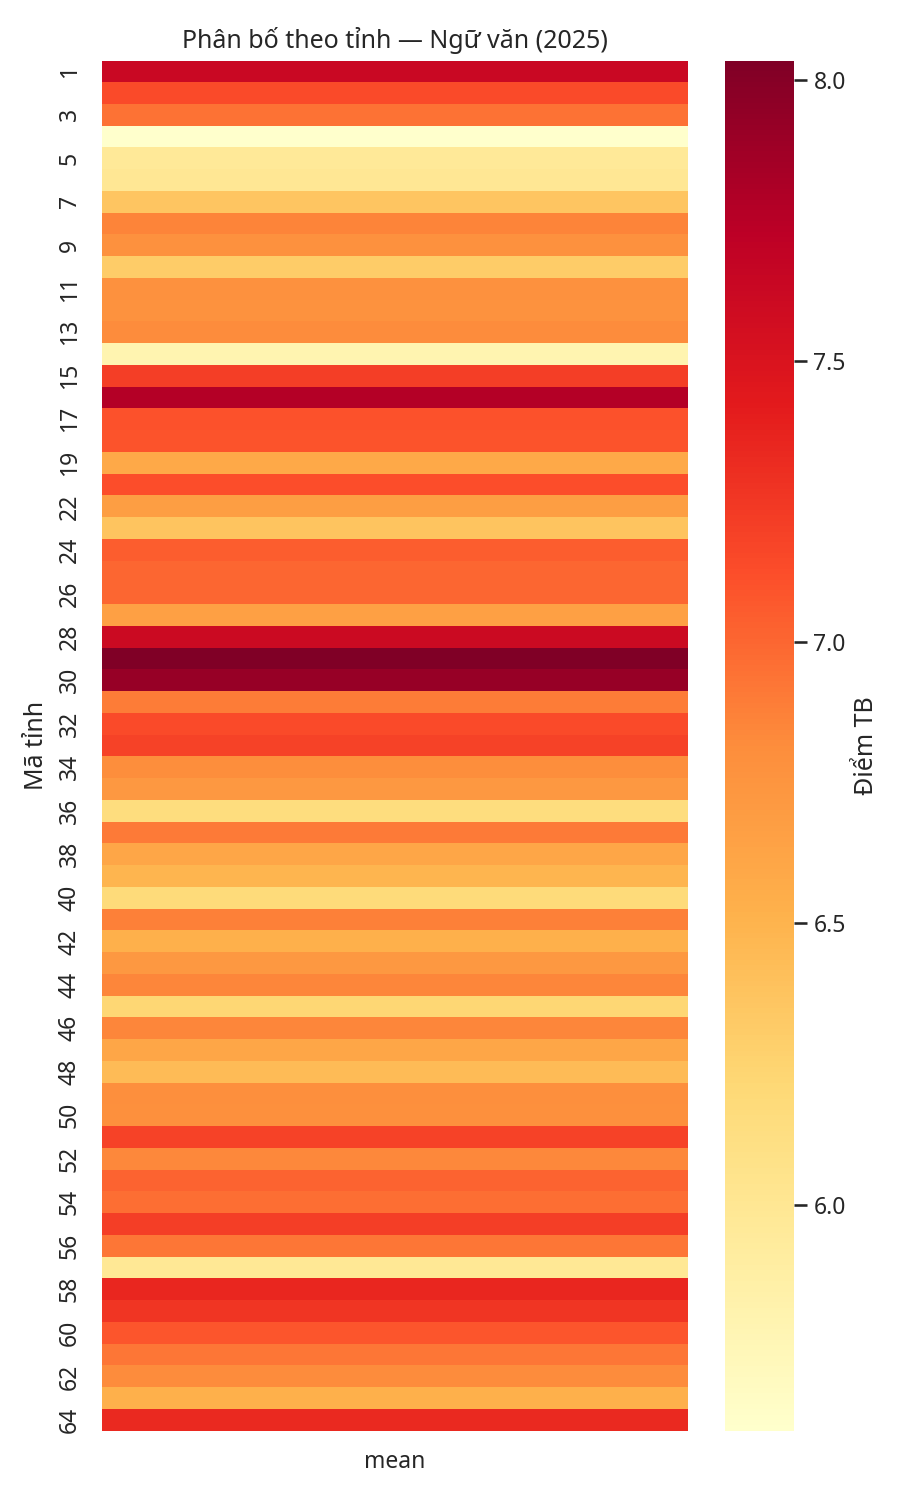

heatmap_SinhHoc_2025.png


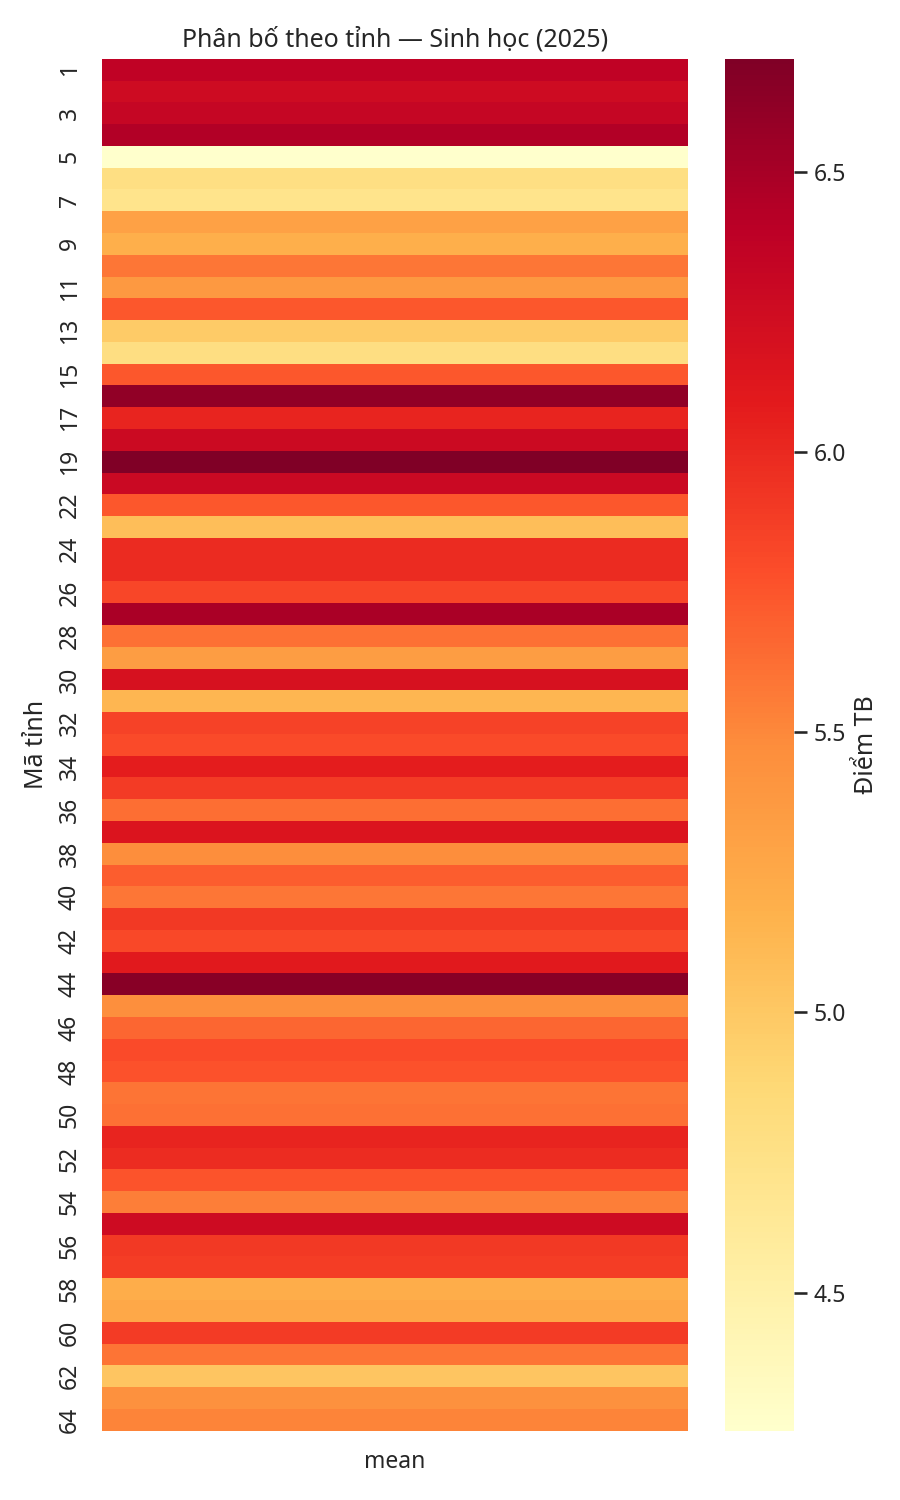

heatmap_Toan_2025.png


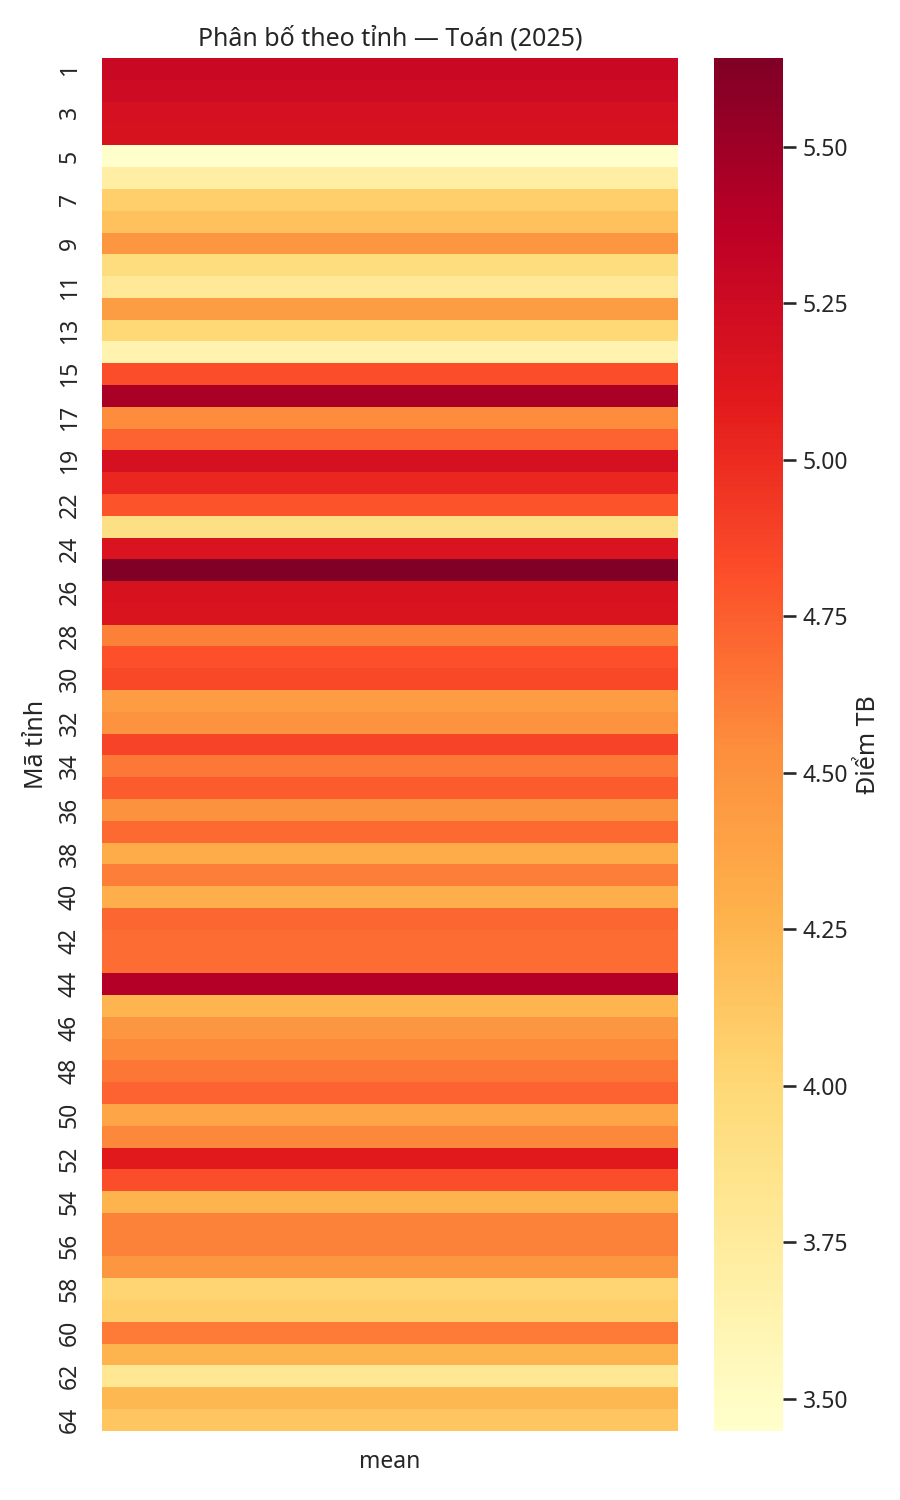

heatmap_VatLy_2025.png


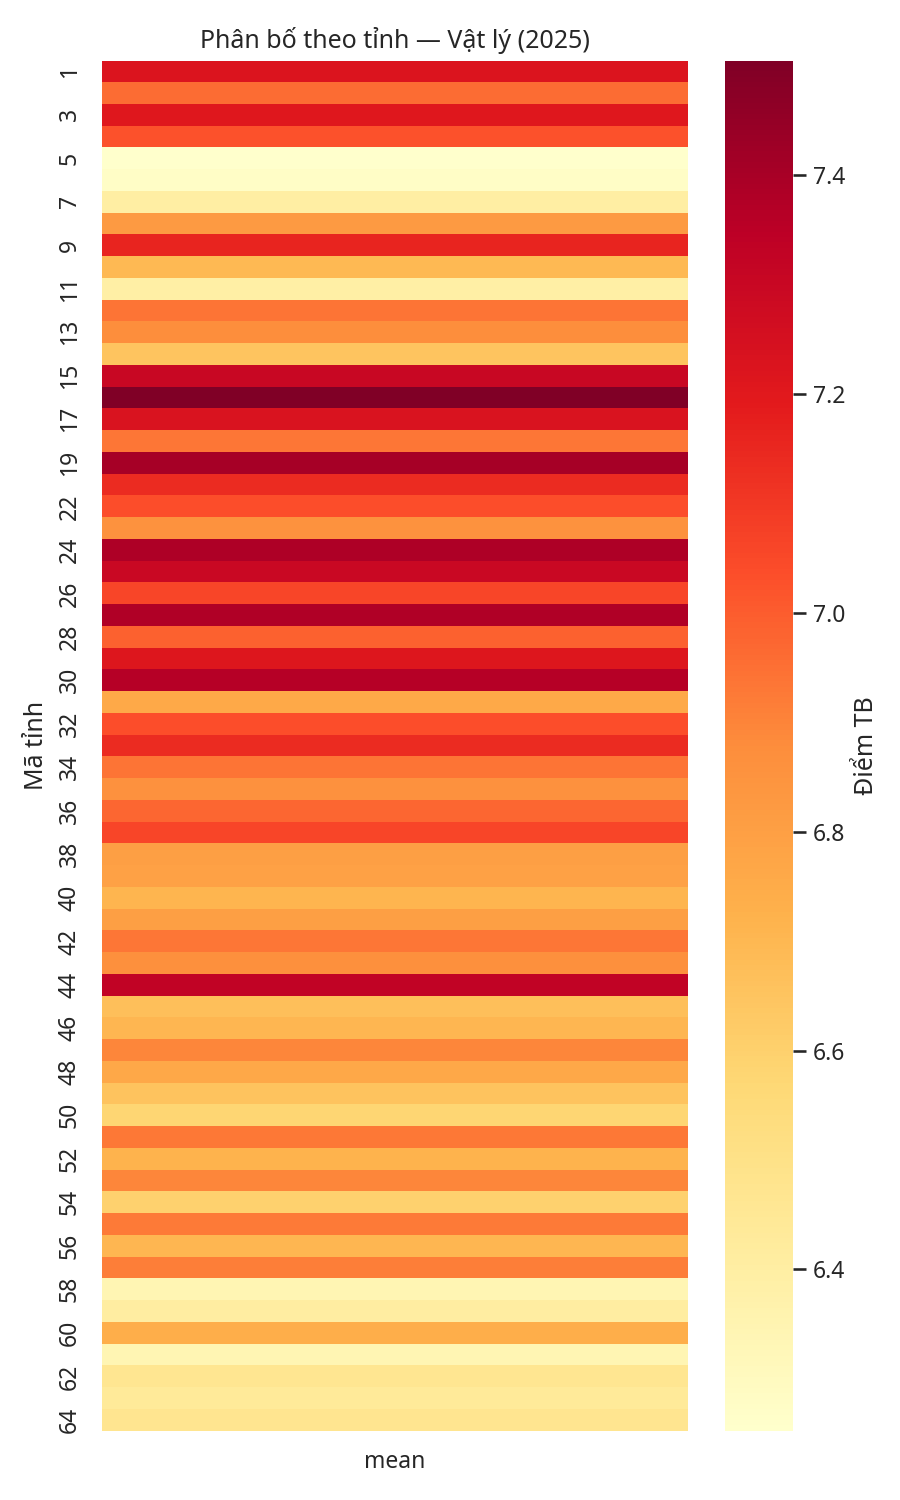

histogram_CongNgheCongNghiep_2025.png


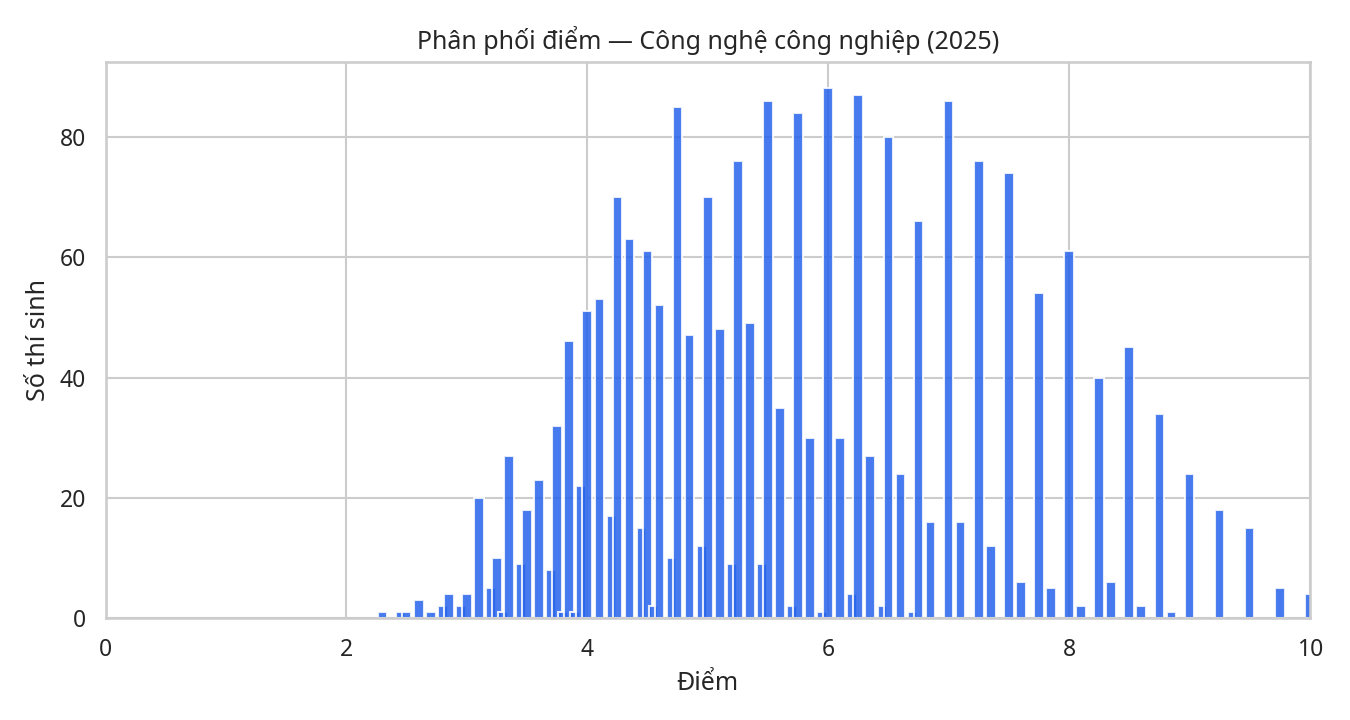

histogram_CongNgheNongNghiep_2025.png


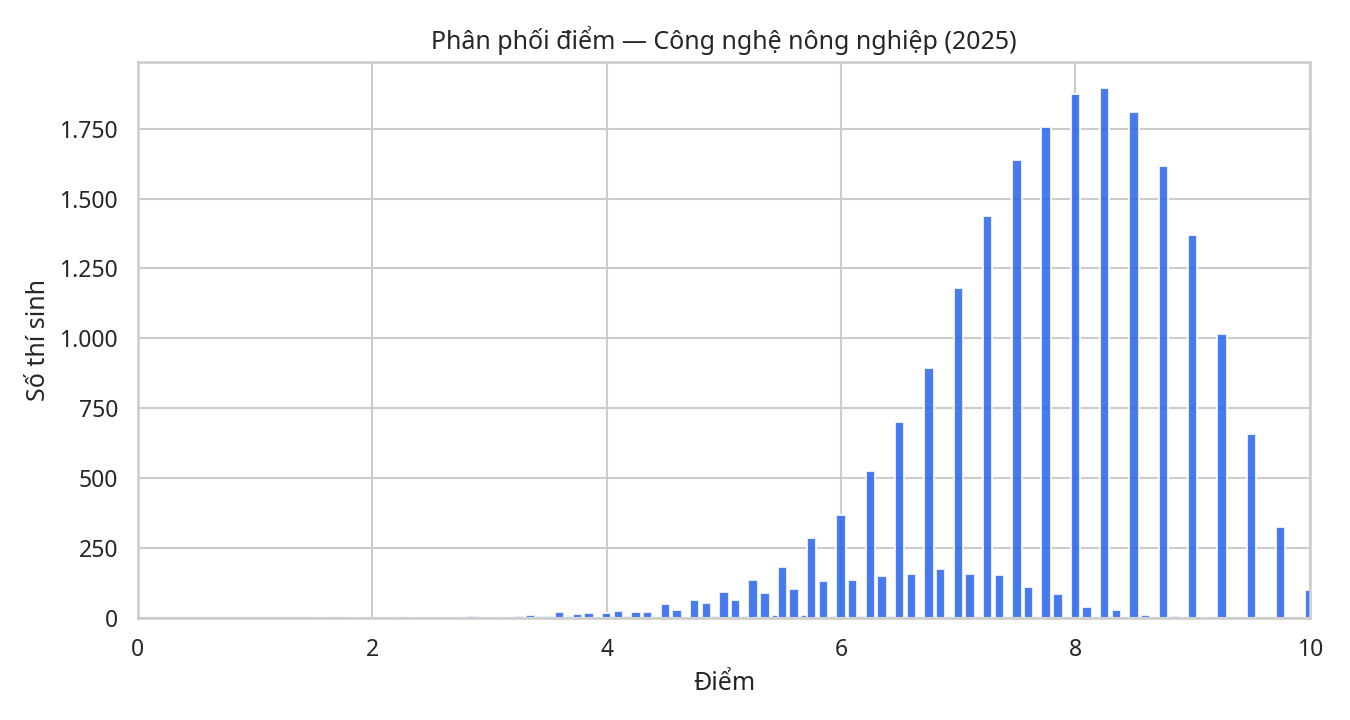

histogram_DiaLy_2025.png


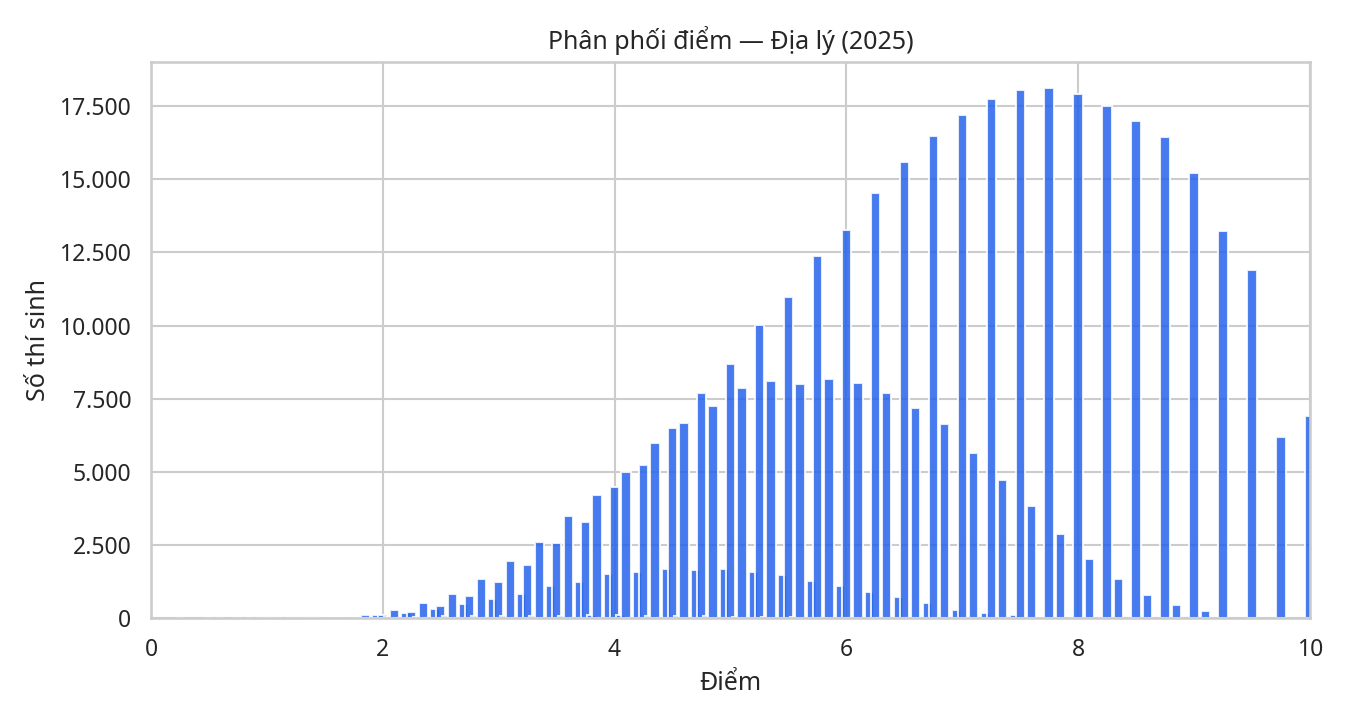

histogram_HoaHoc_2025.png


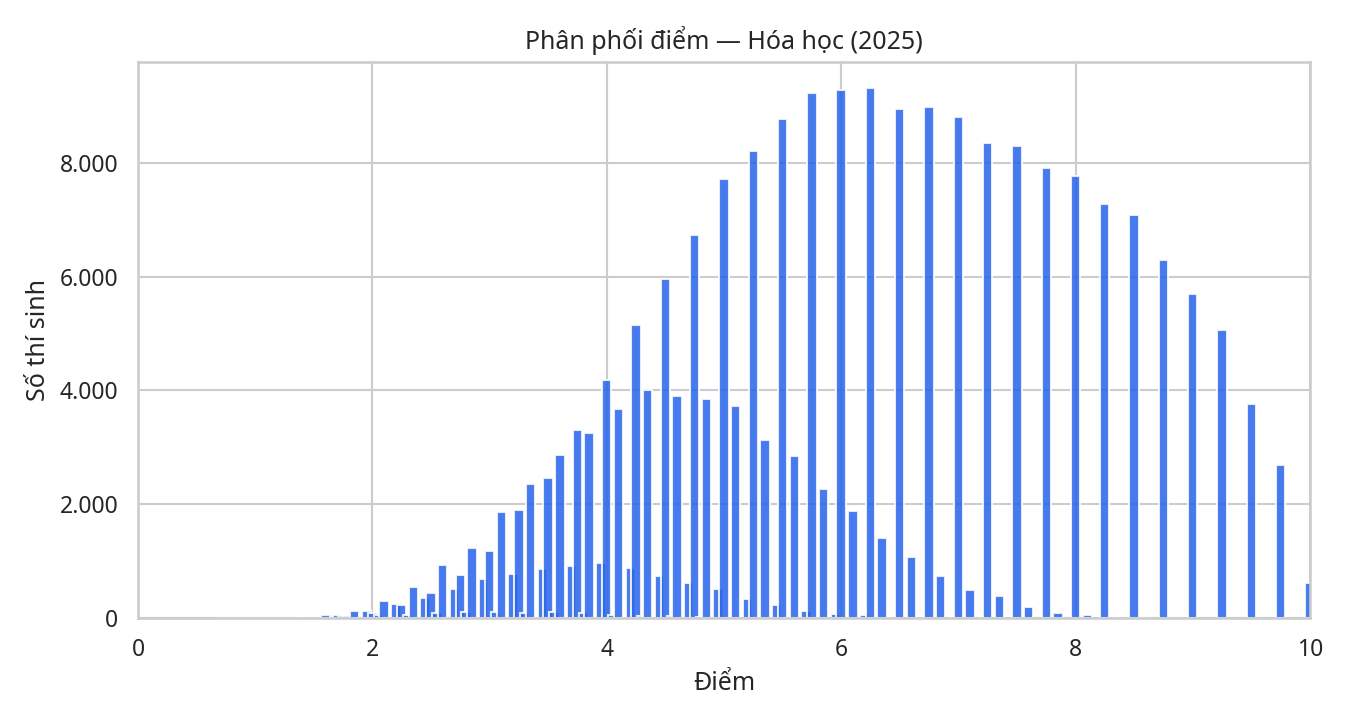

histogram_KinhTePhapLuat_2025.png


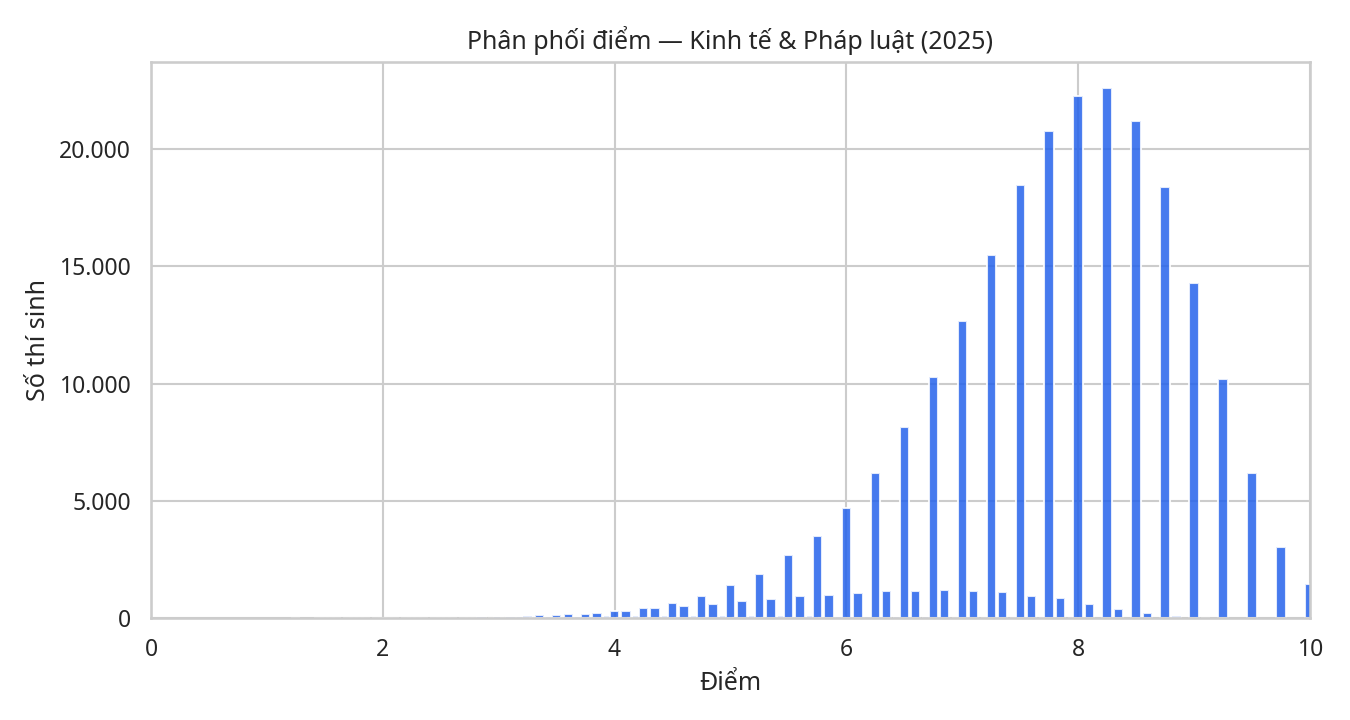

histogram_LichSu_2025.png


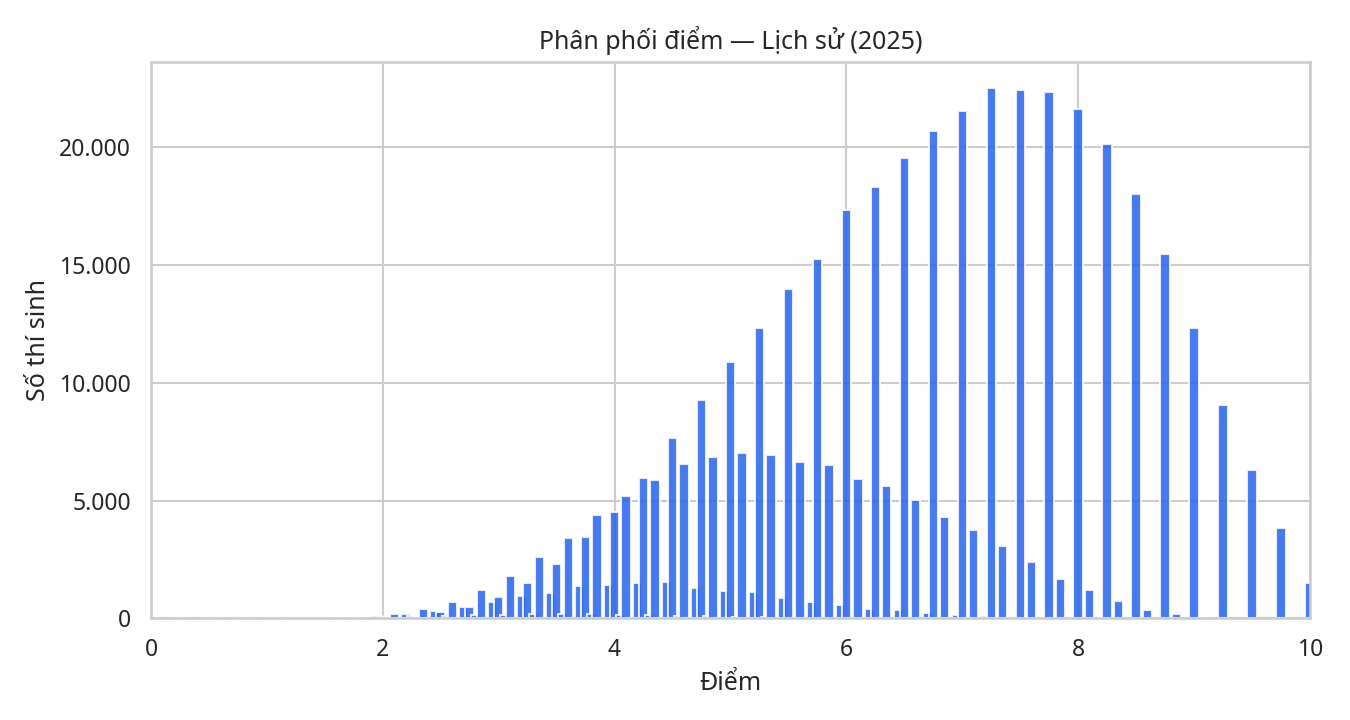

histogram_NgoaiNgu_2025.png


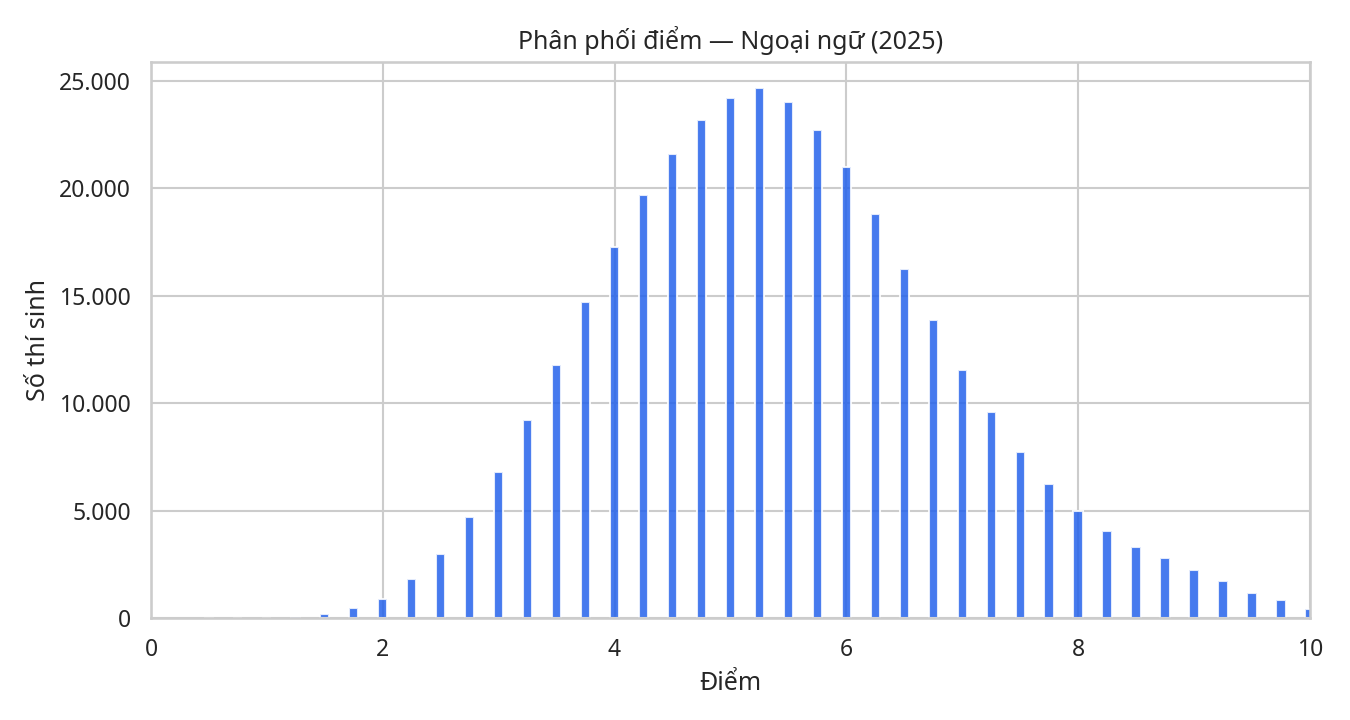

histogram_NguVan_2025.png


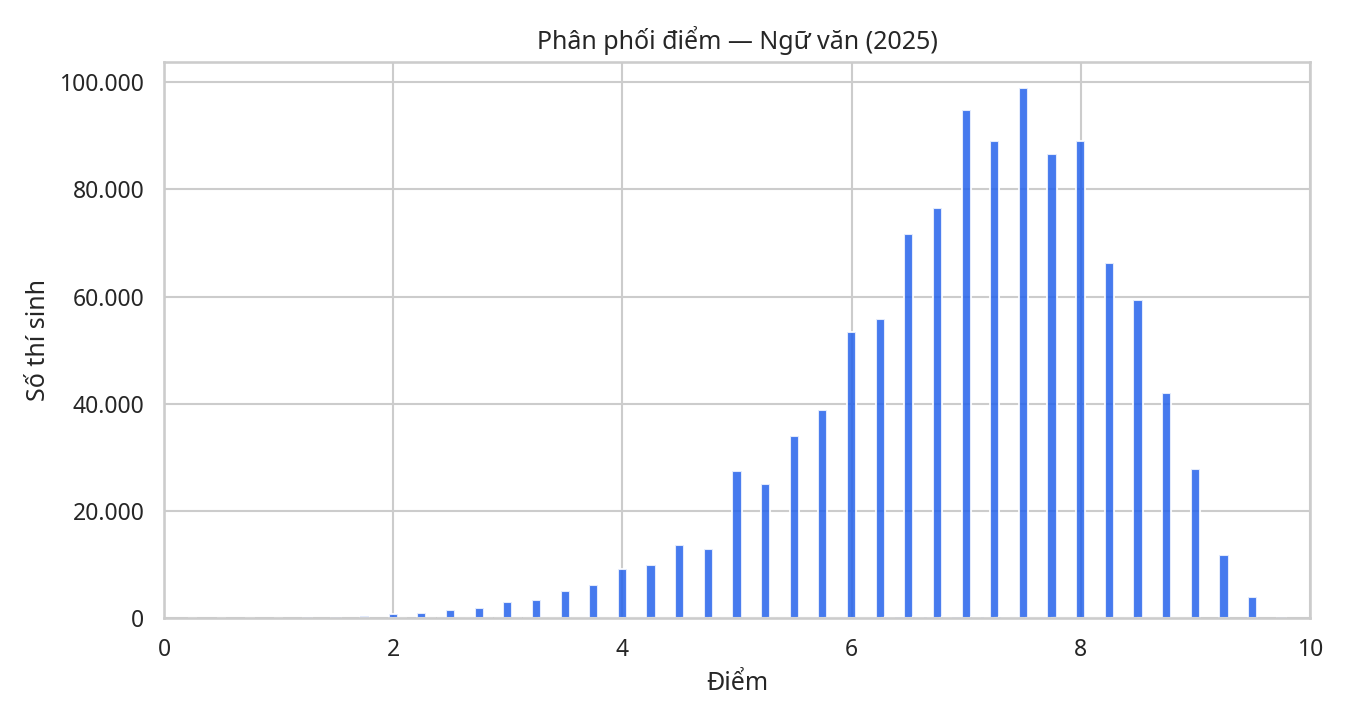

histogram_SinhHoc_2025.png


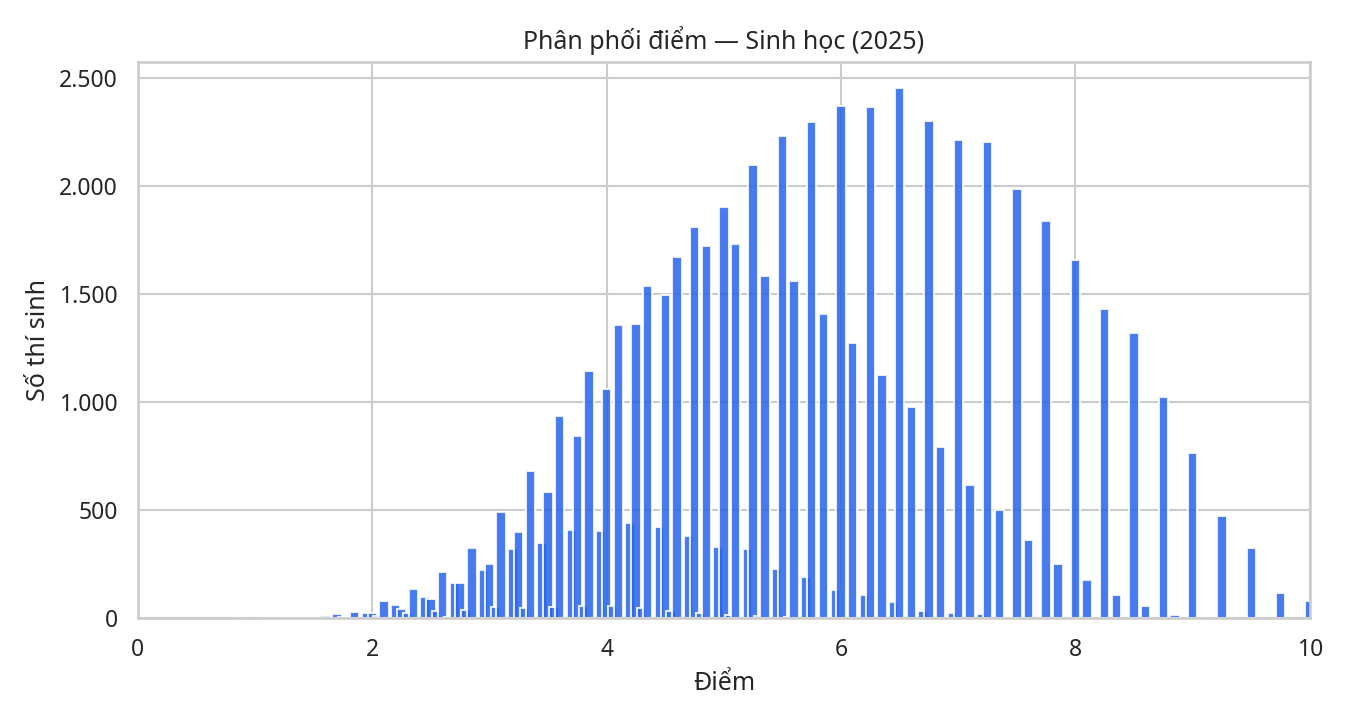

histogram_TinHoc_2025.png


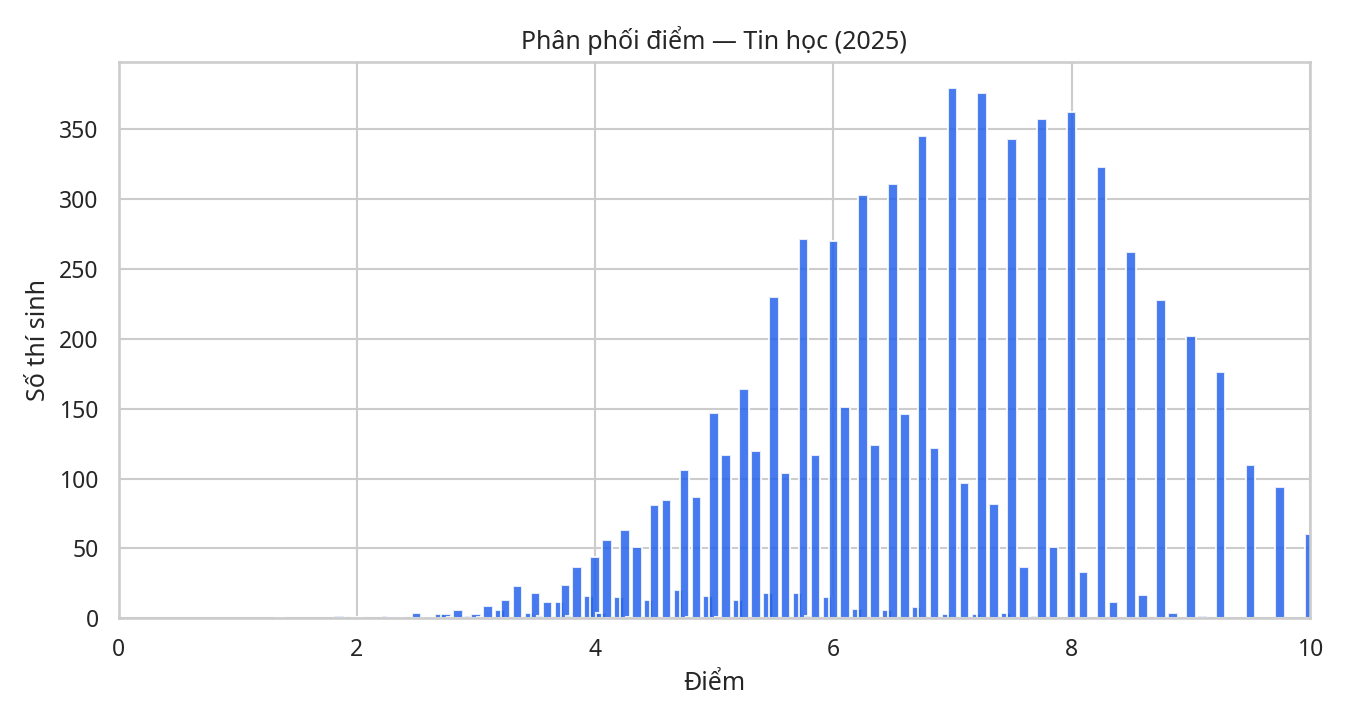

histogram_Toan_2025.png


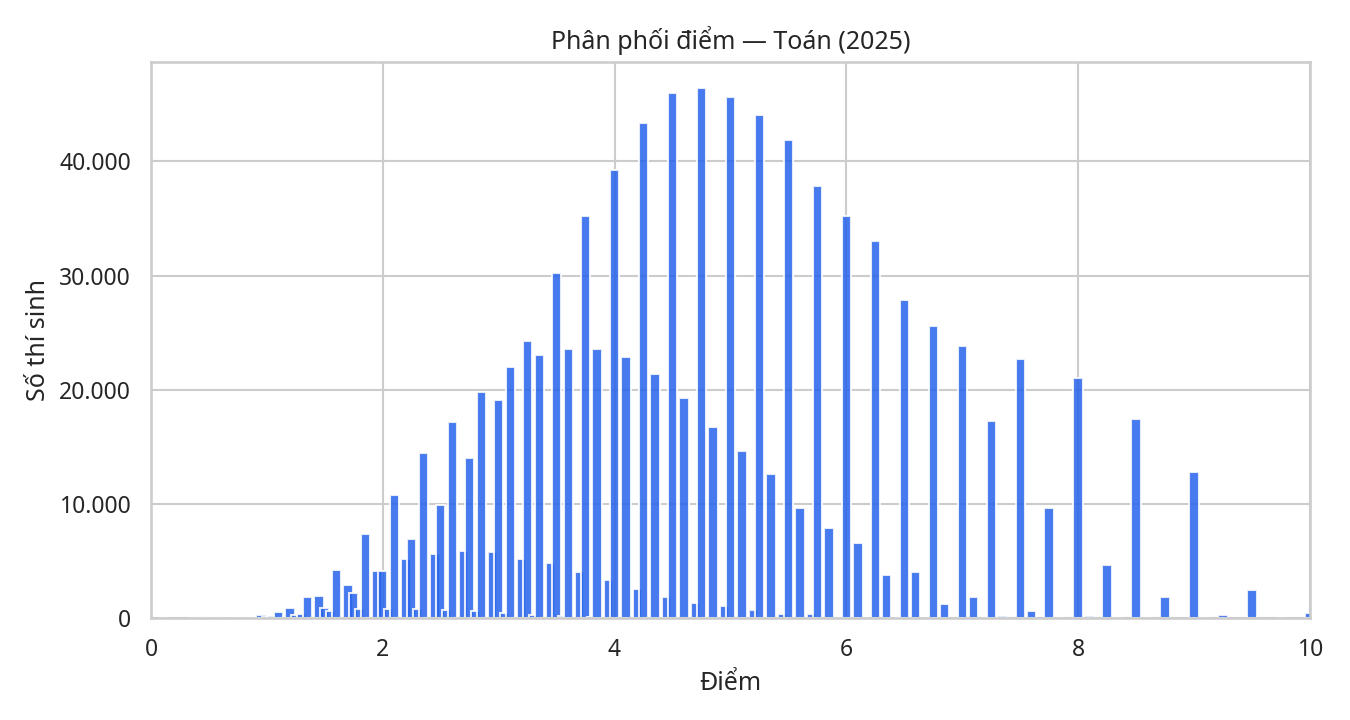

histogram_VatLy_2025.png


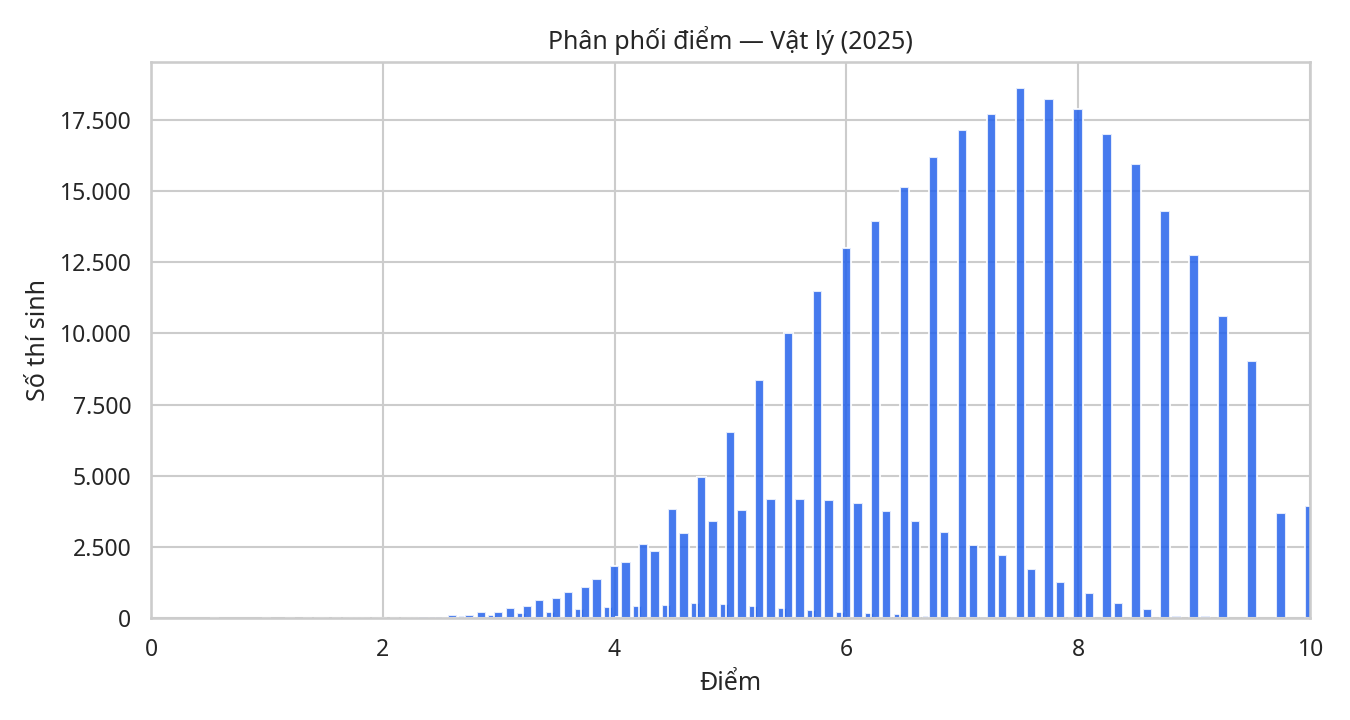

mean_by_year_CongNgheCongNghiep.png


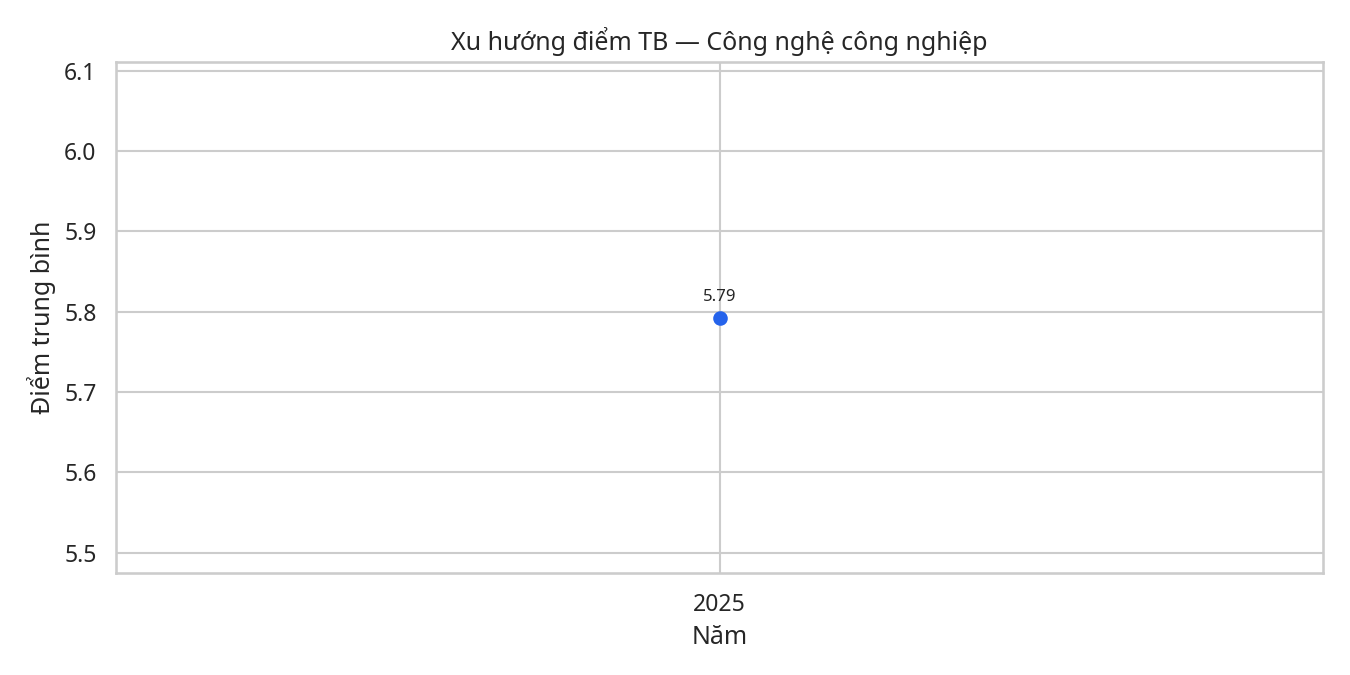

mean_by_year_CongNgheNongNghiep.png


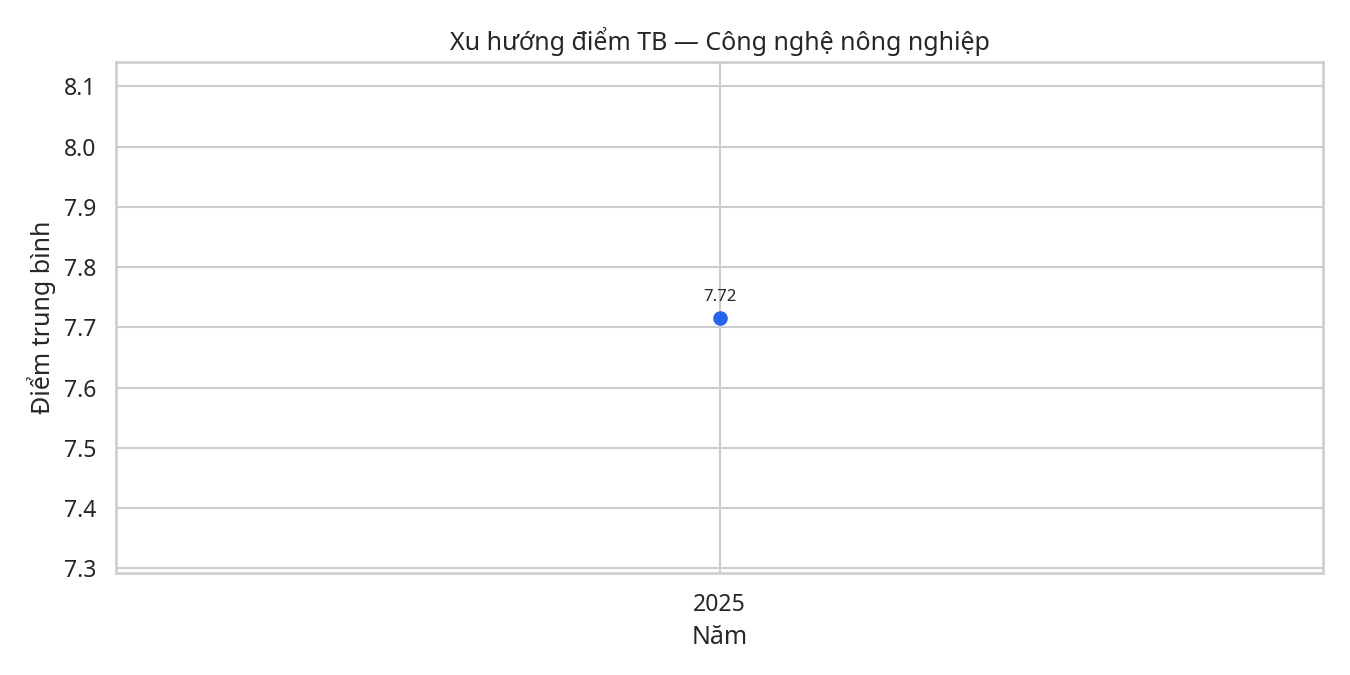

mean_by_year_DiaLy.png


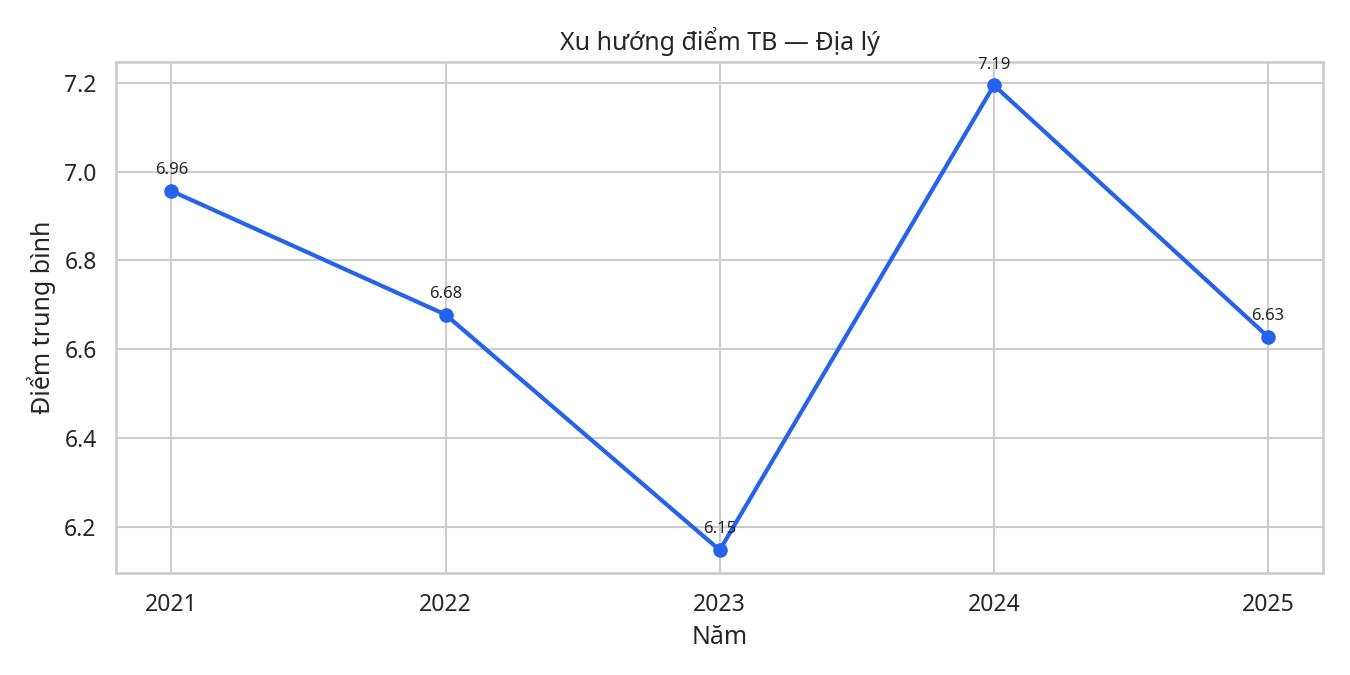

mean_by_year_GDCD.png


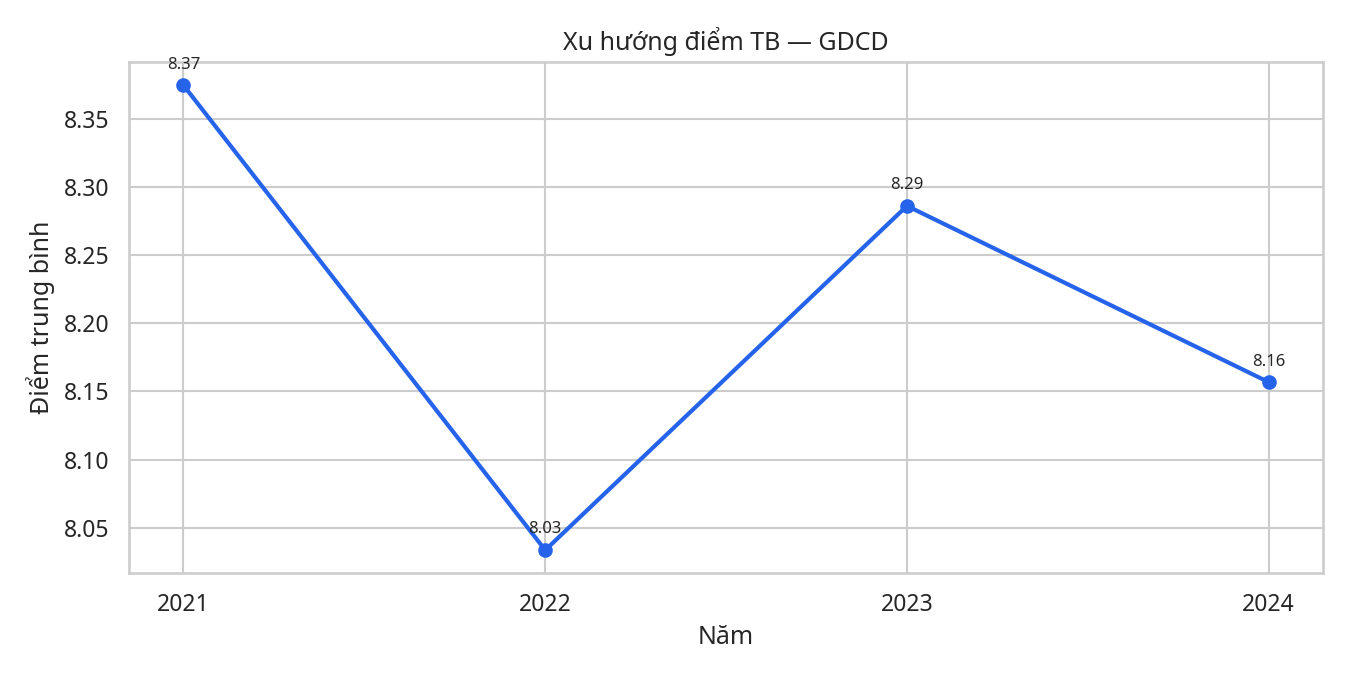

mean_by_year_HoaHoc.png


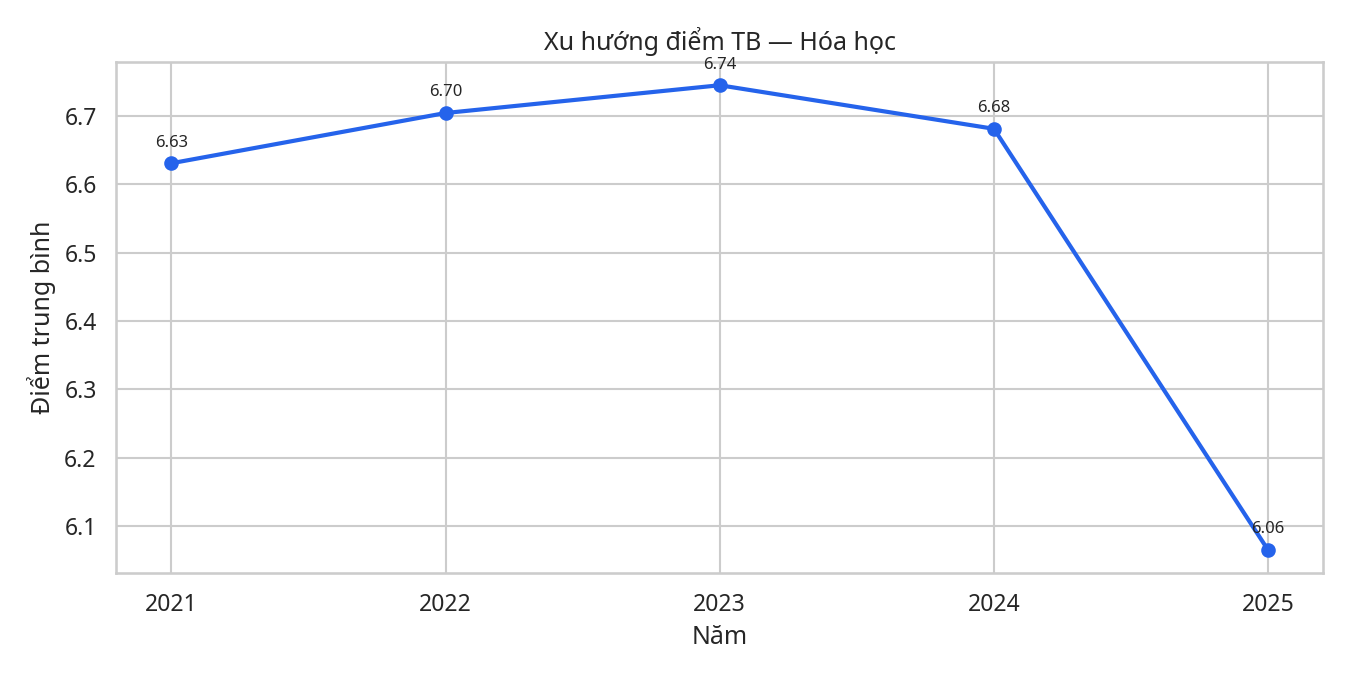

mean_by_year_KinhTePhapLuat.png


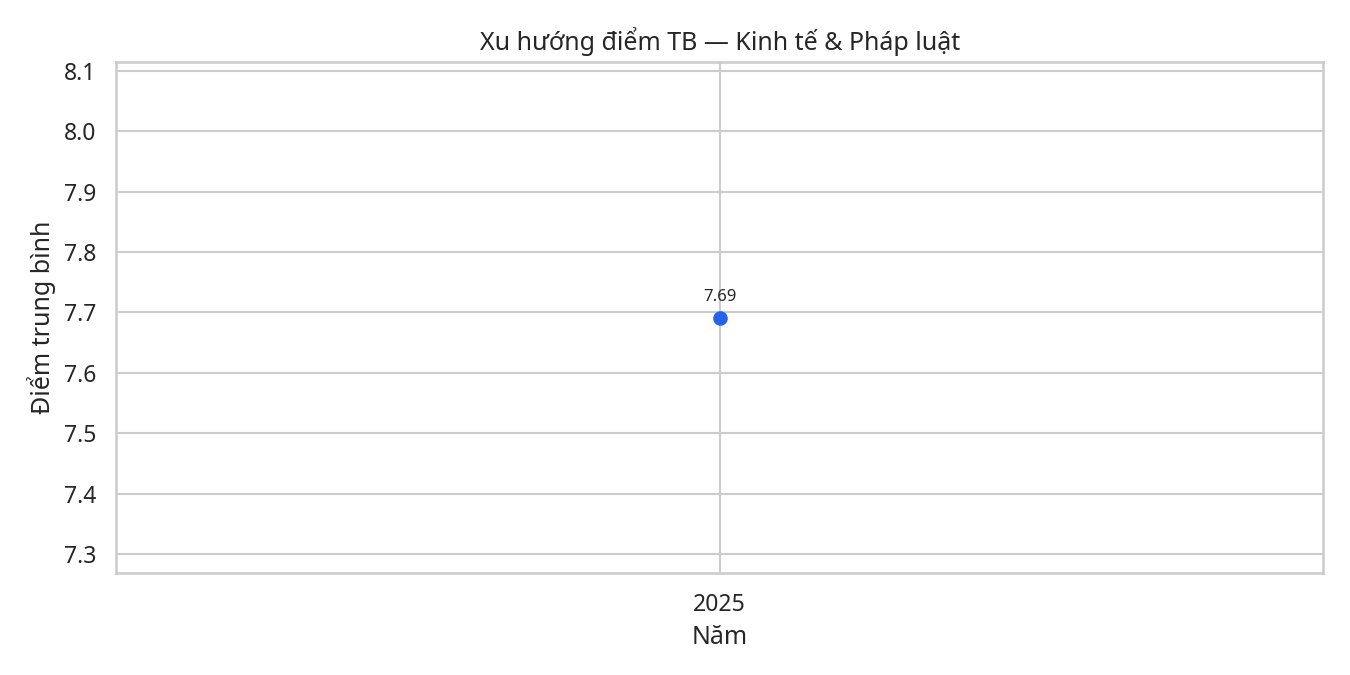

mean_by_year_LichSu.png


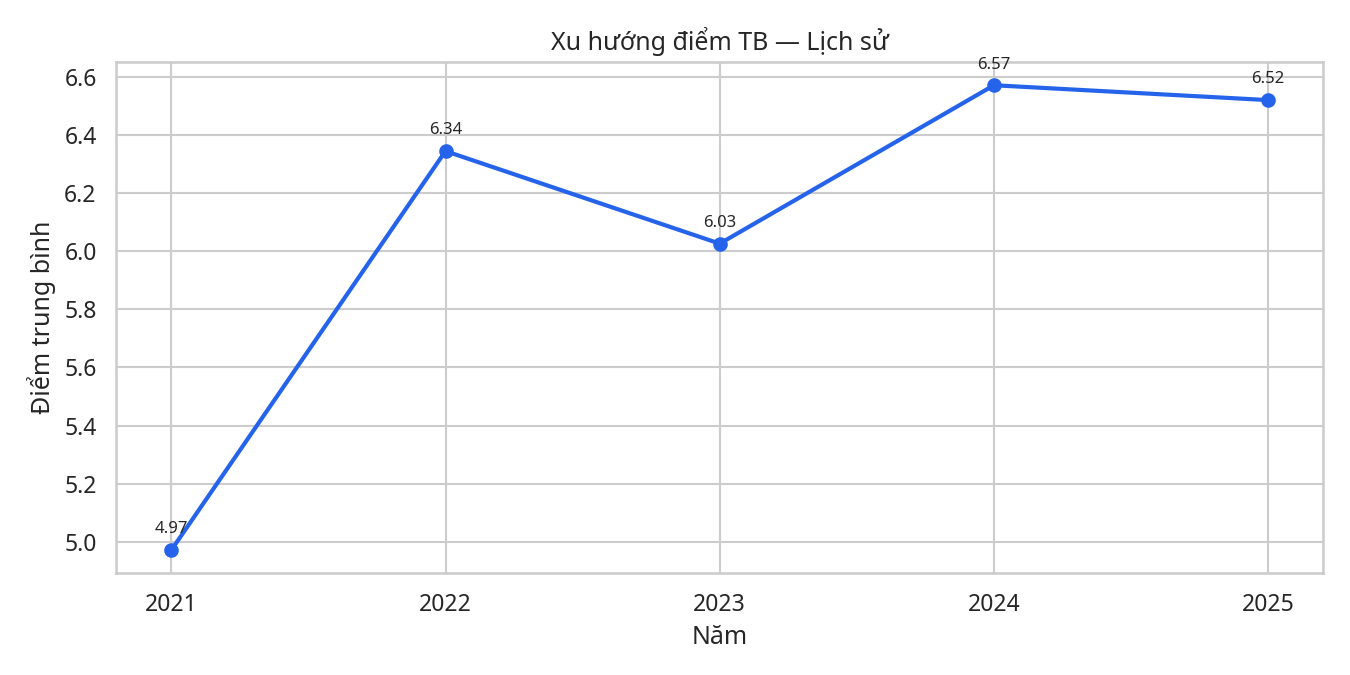

mean_by_year_NgoaiNgu.png


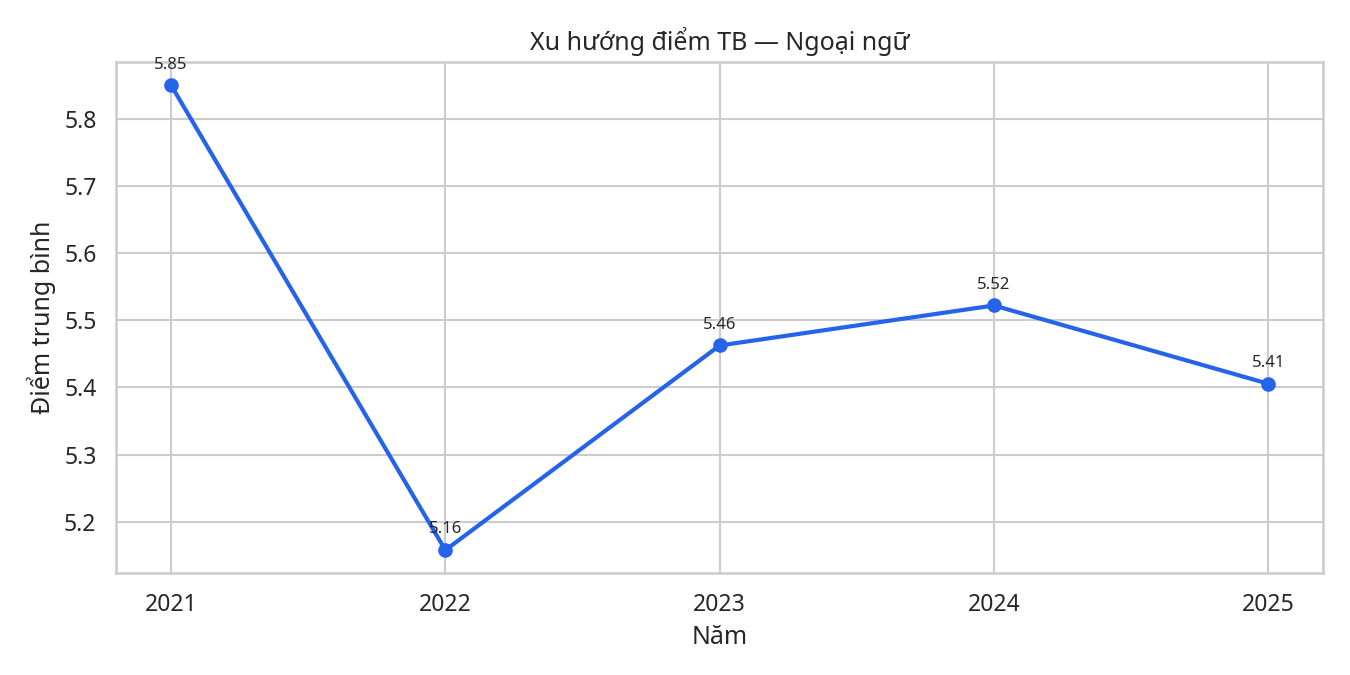

mean_by_year_NguVan.png


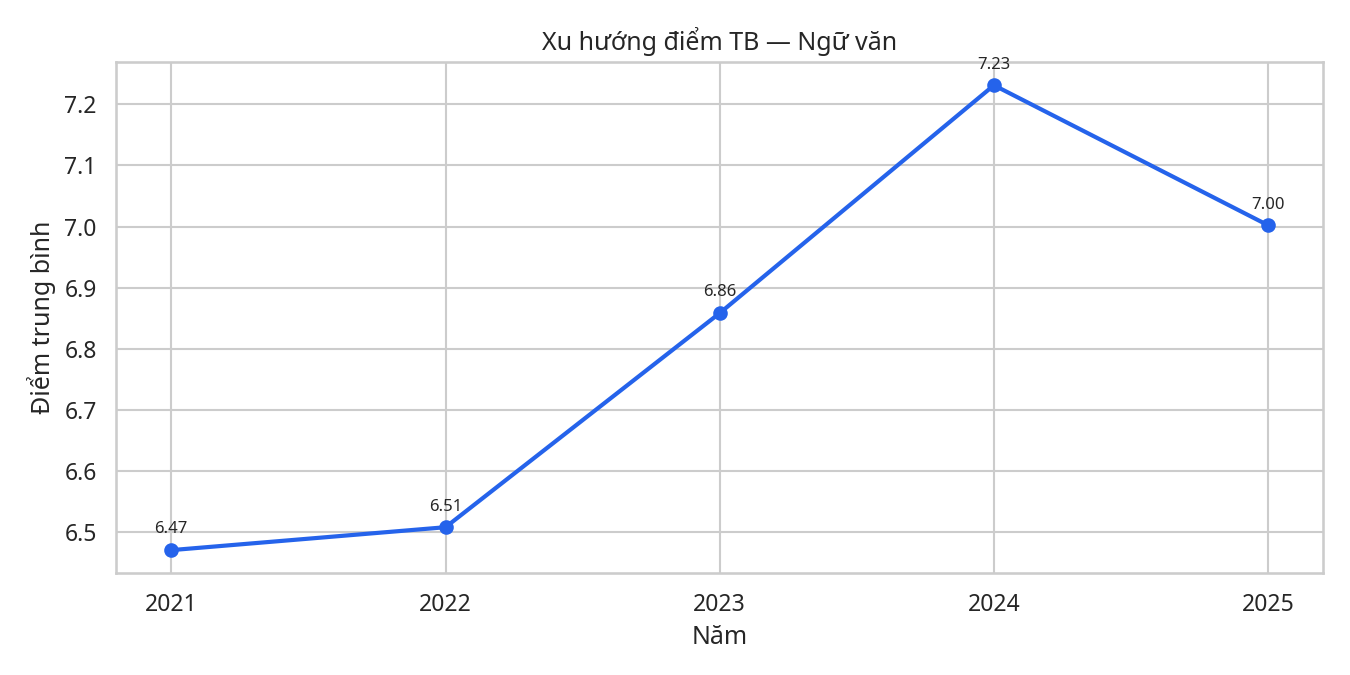

mean_by_year_SinhHoc.png


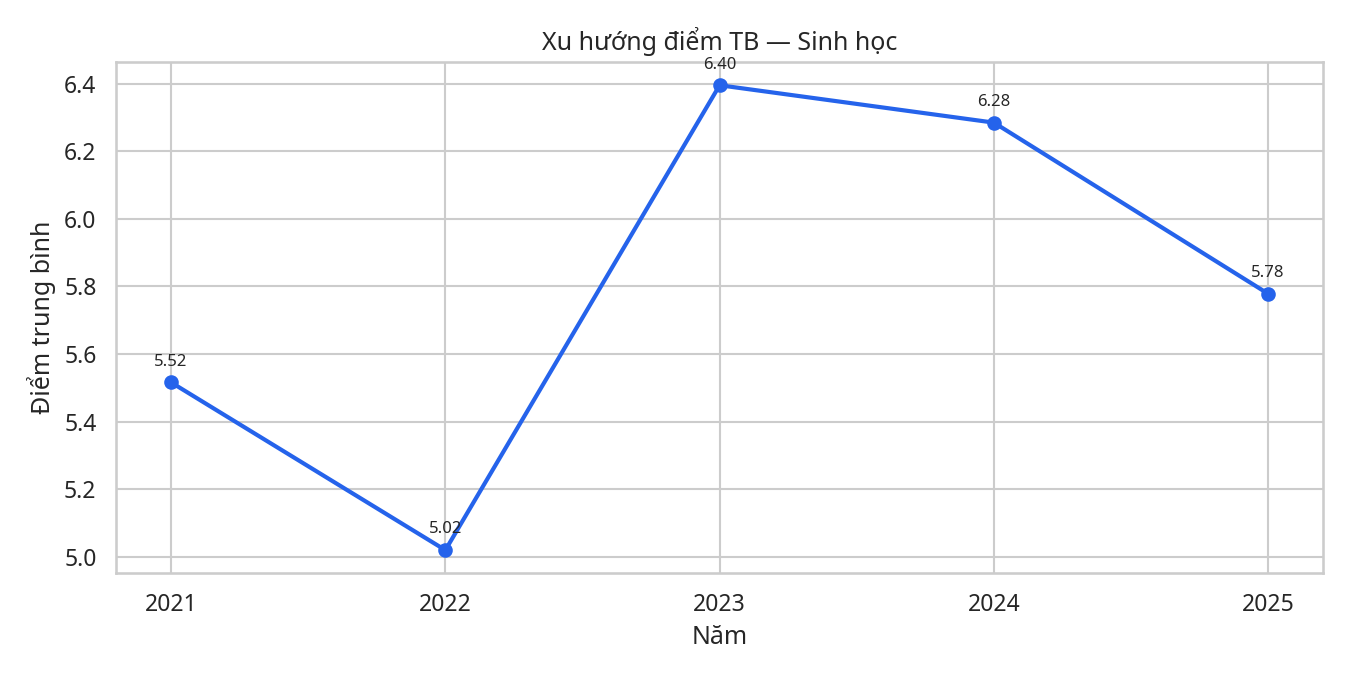

mean_by_year_TinHoc.png


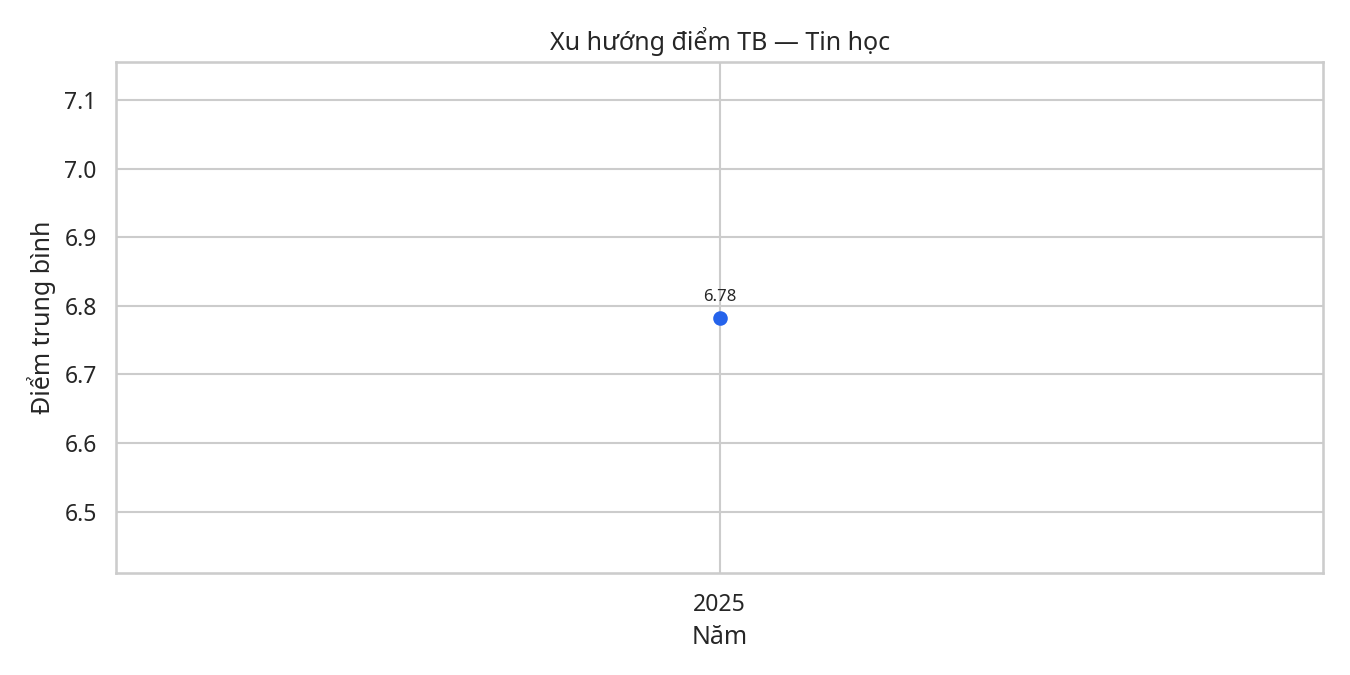

mean_by_year_Toan.png


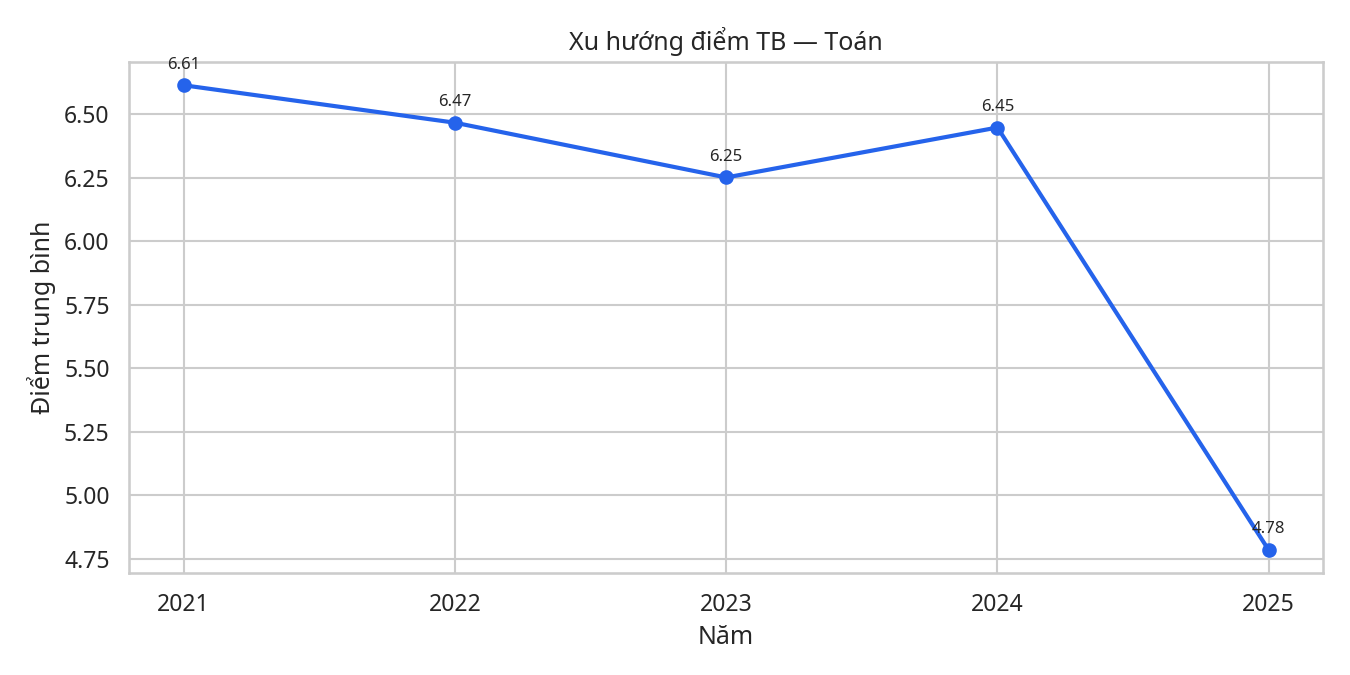

mean_by_year_VatLy.png


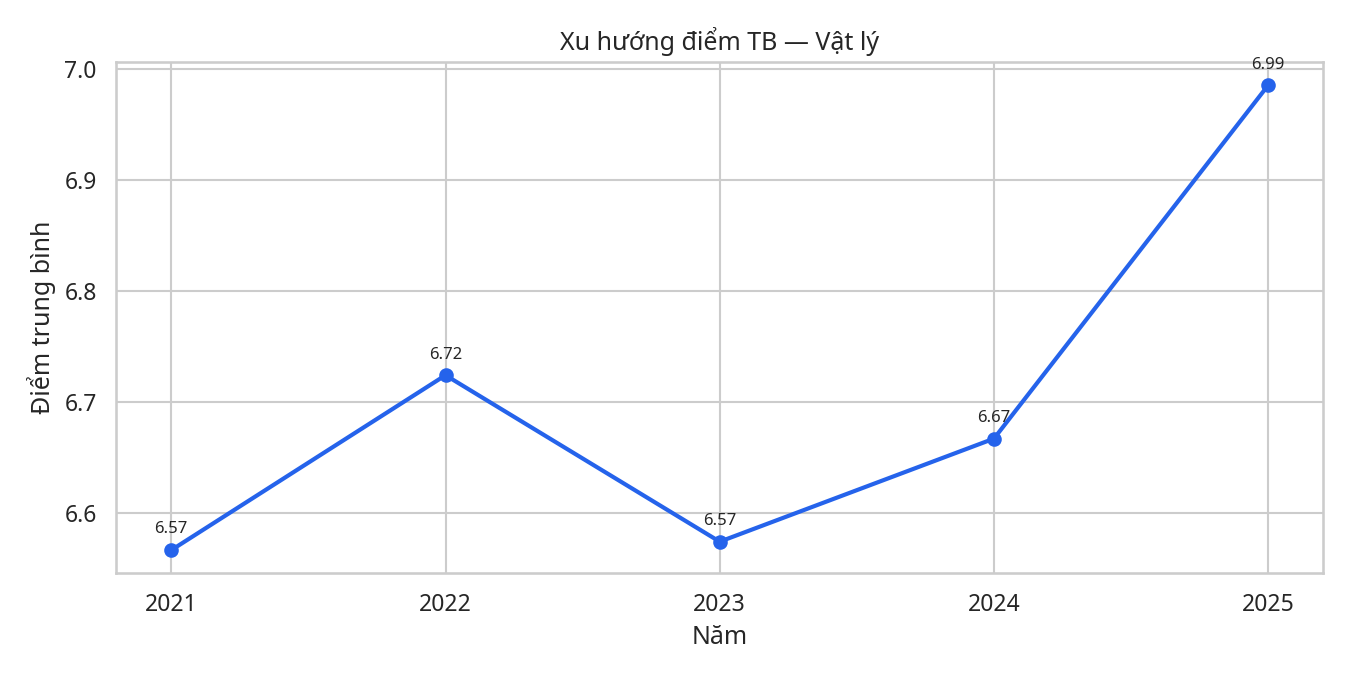

pct_ge_8_by_year.png


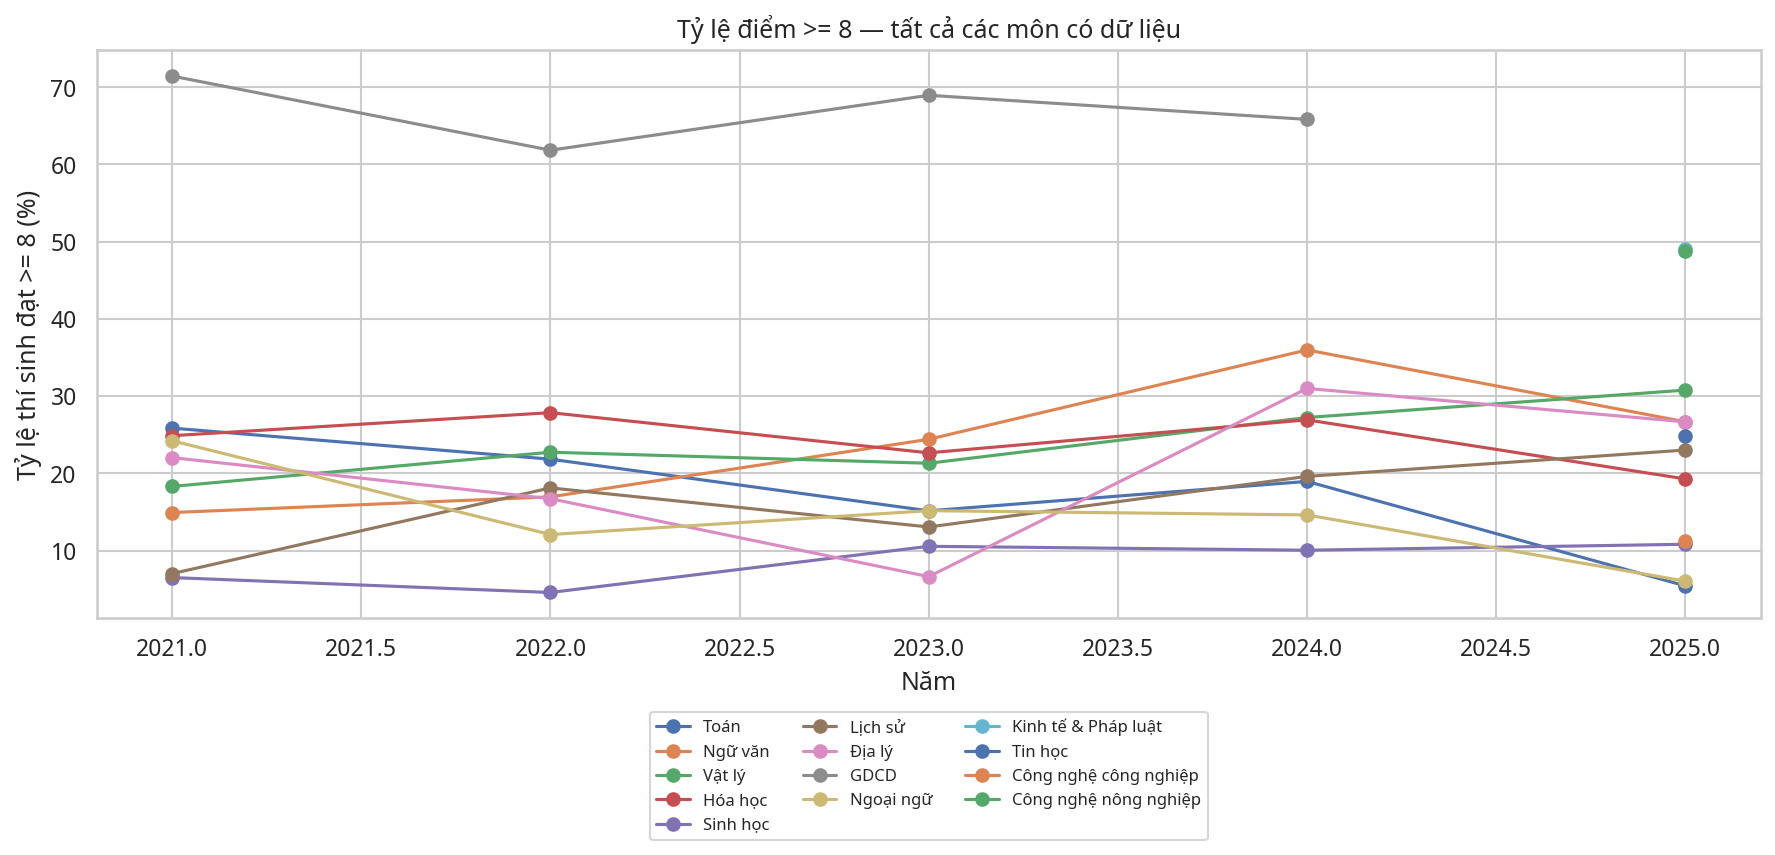

province_volatility_HoaHoc.png


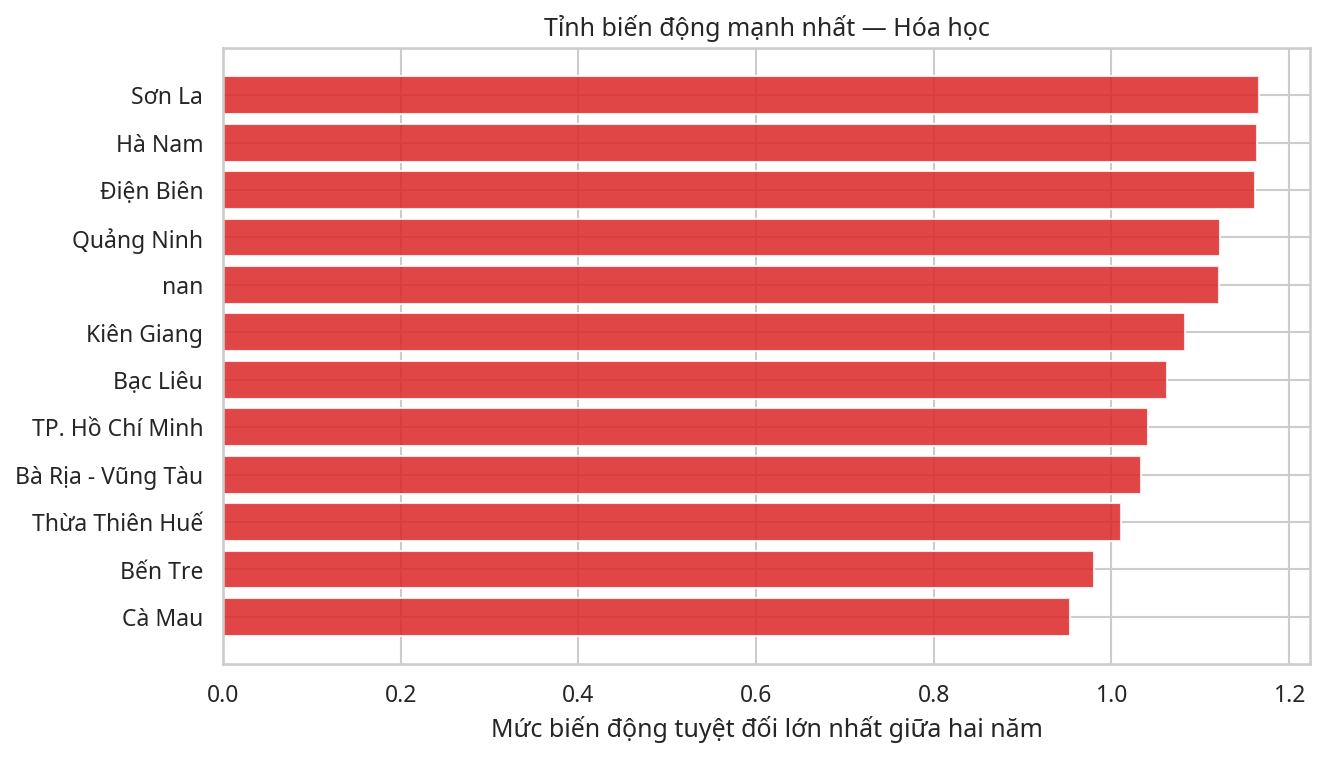

province_volatility_NgoaiNgu.png


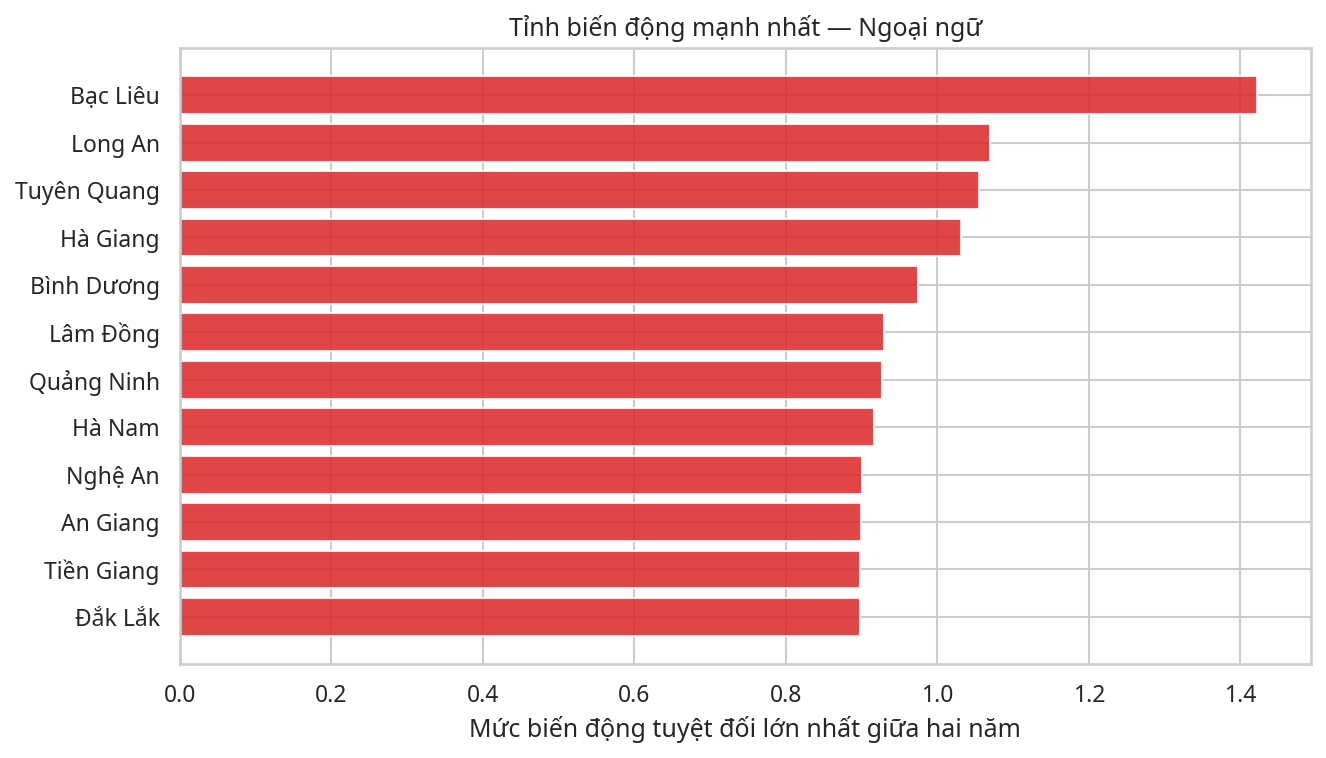

province_volatility_NguVan.png


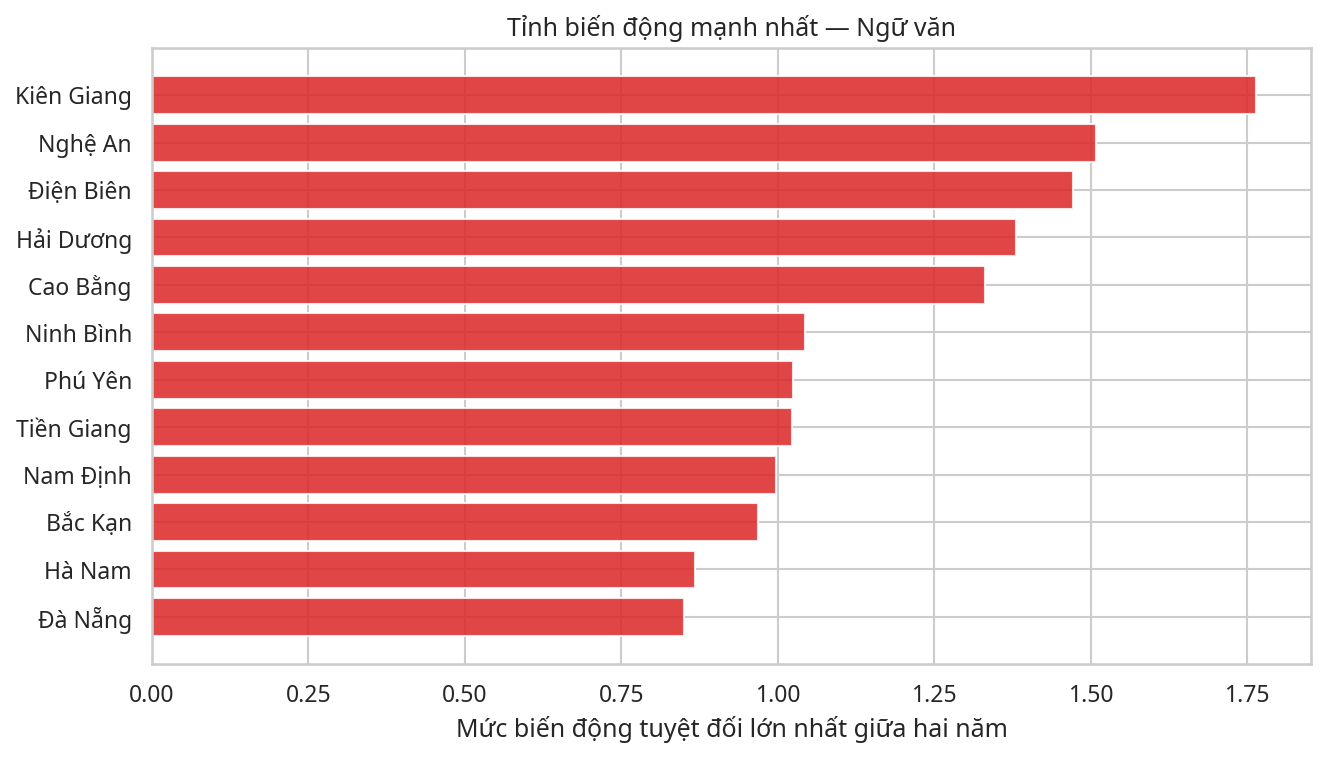

province_volatility_SinhHoc.png


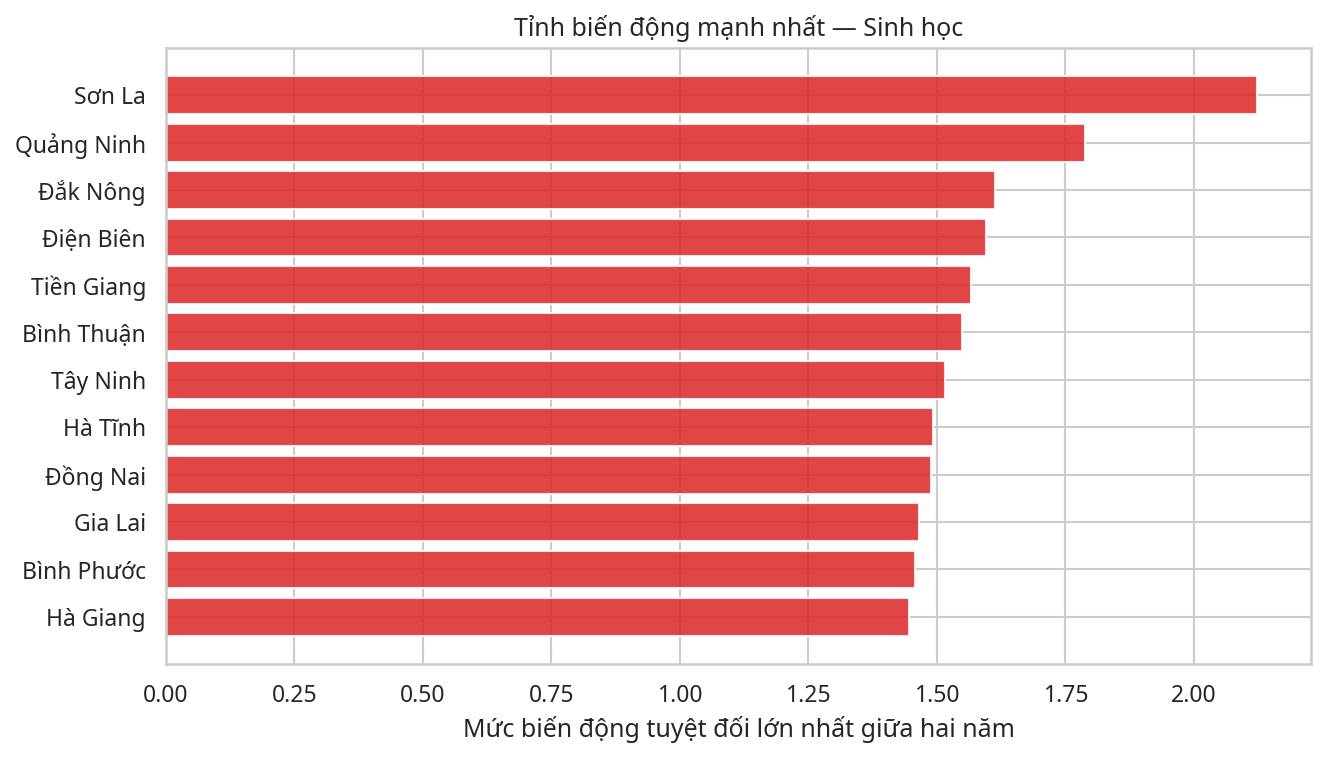

province_volatility_Toan.png


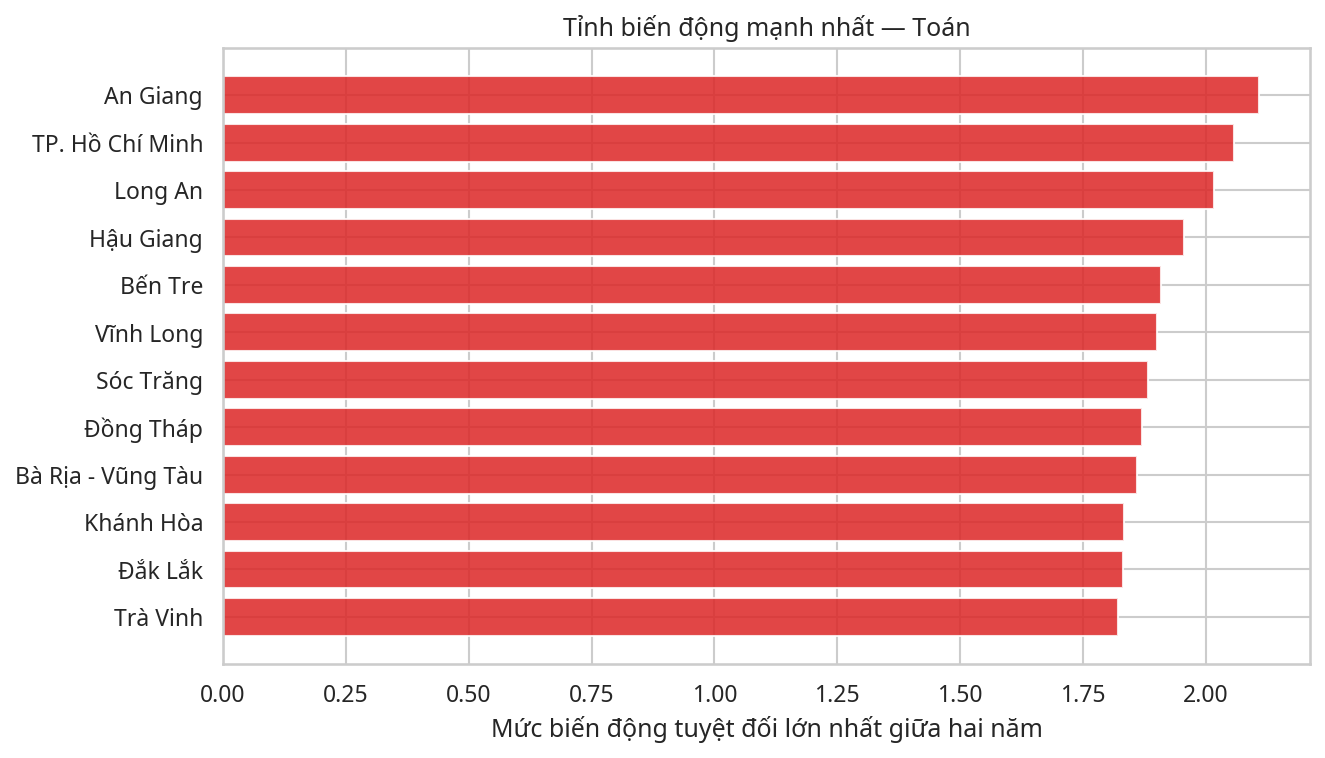

province_volatility_VatLy.png


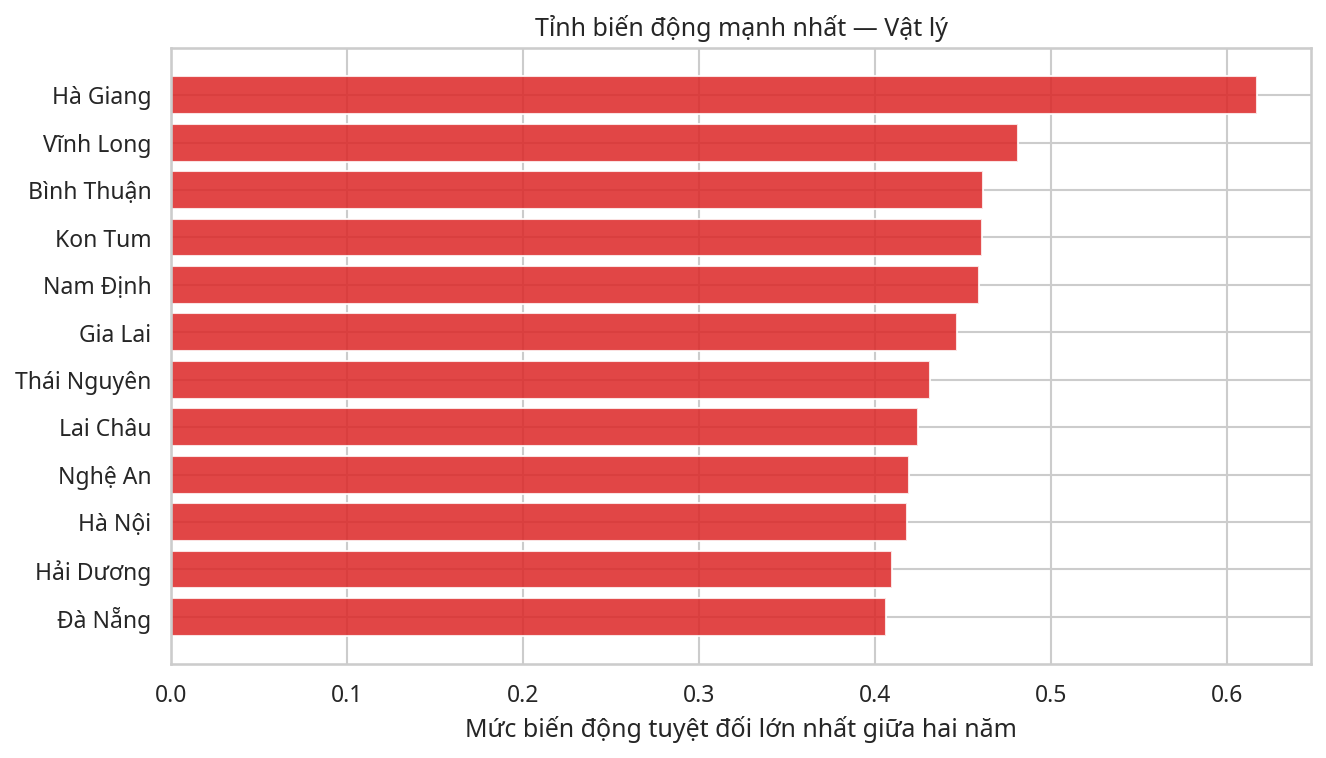

region_comparison_HoaHoc.png


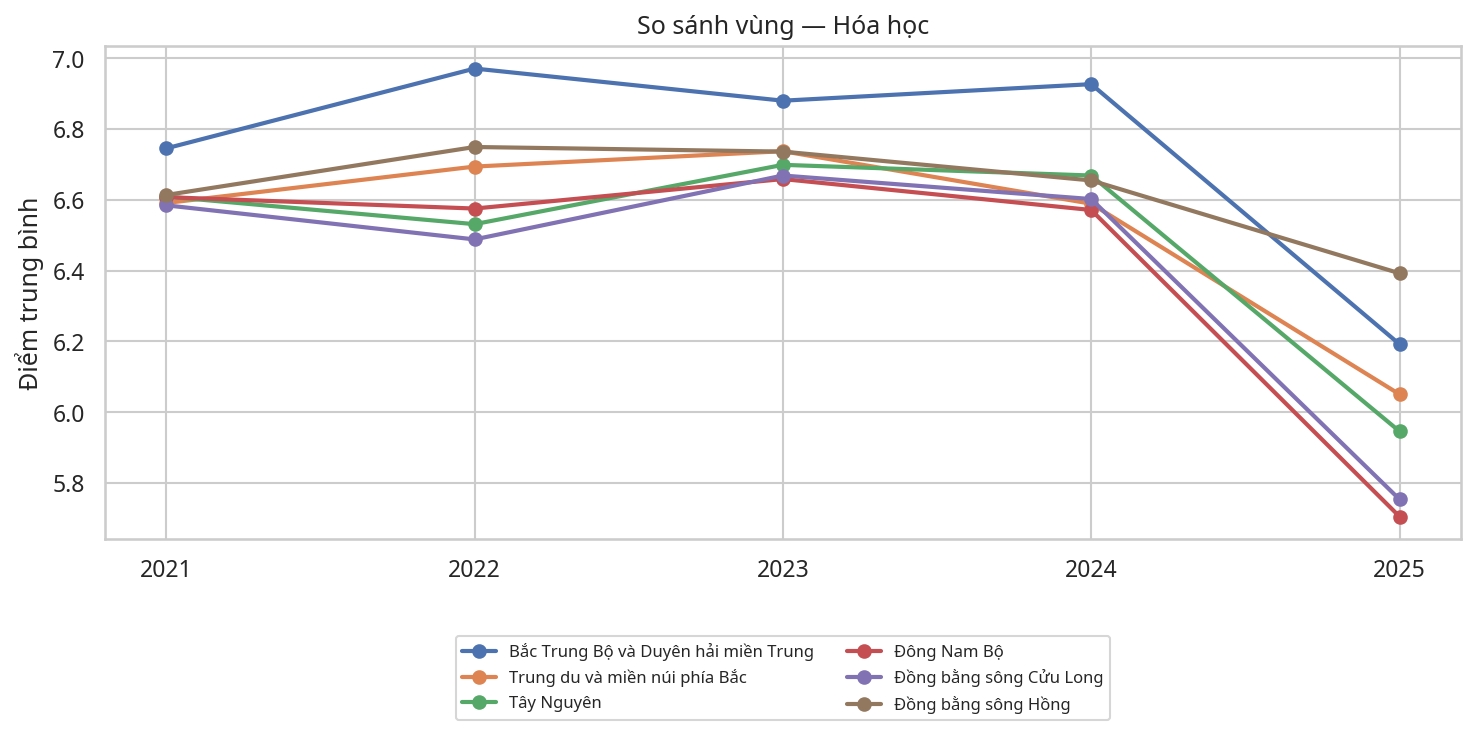

region_comparison_NgoaiNgu.png


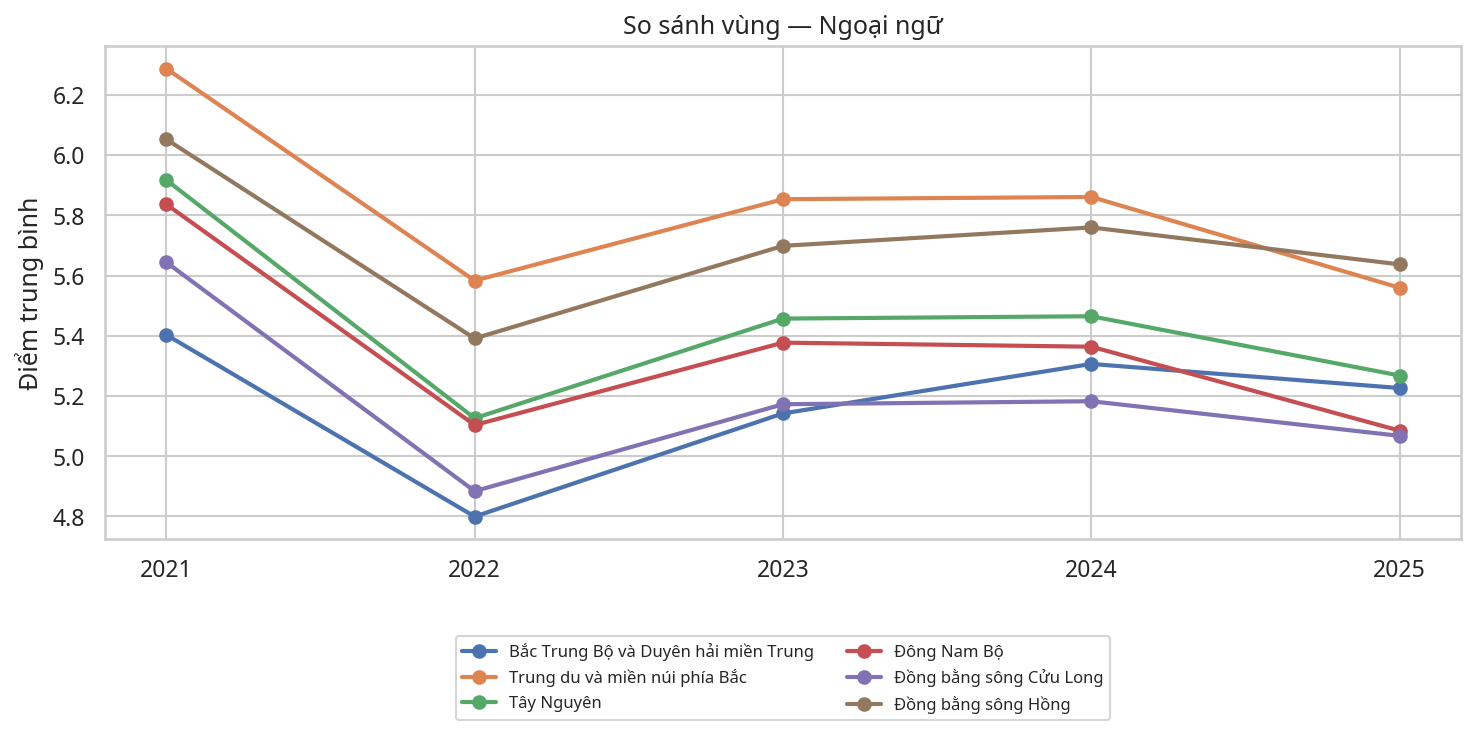

region_comparison_NguVan.png


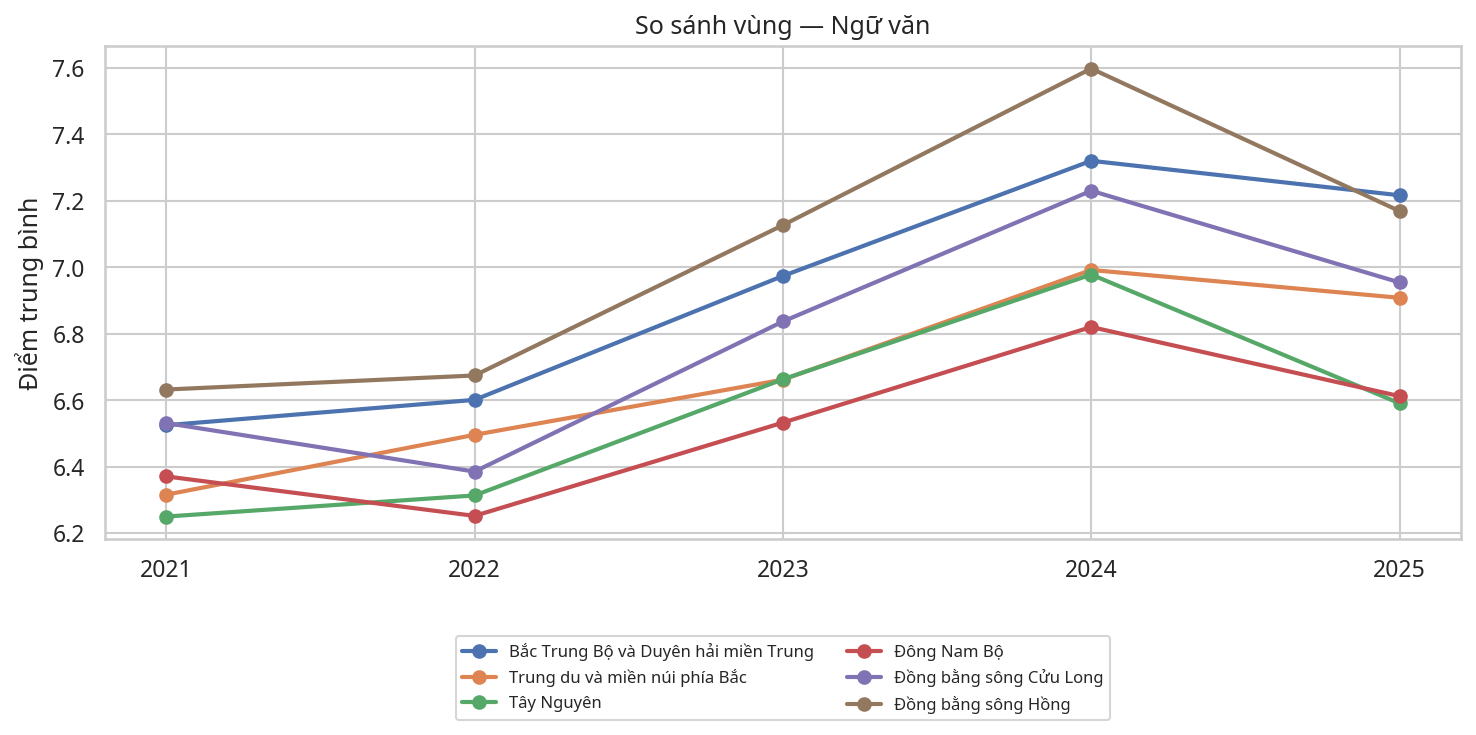

region_comparison_SinhHoc.png


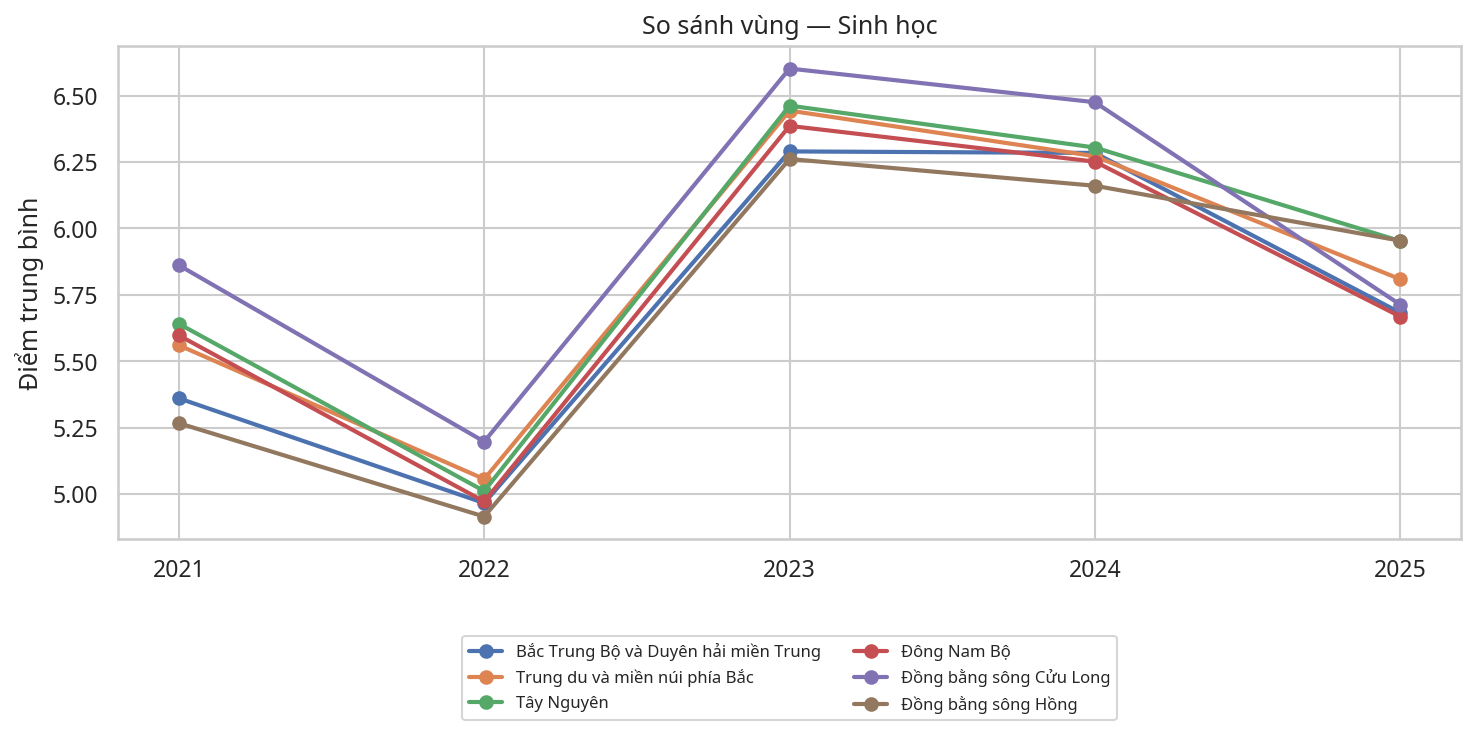

region_comparison_Toan.png


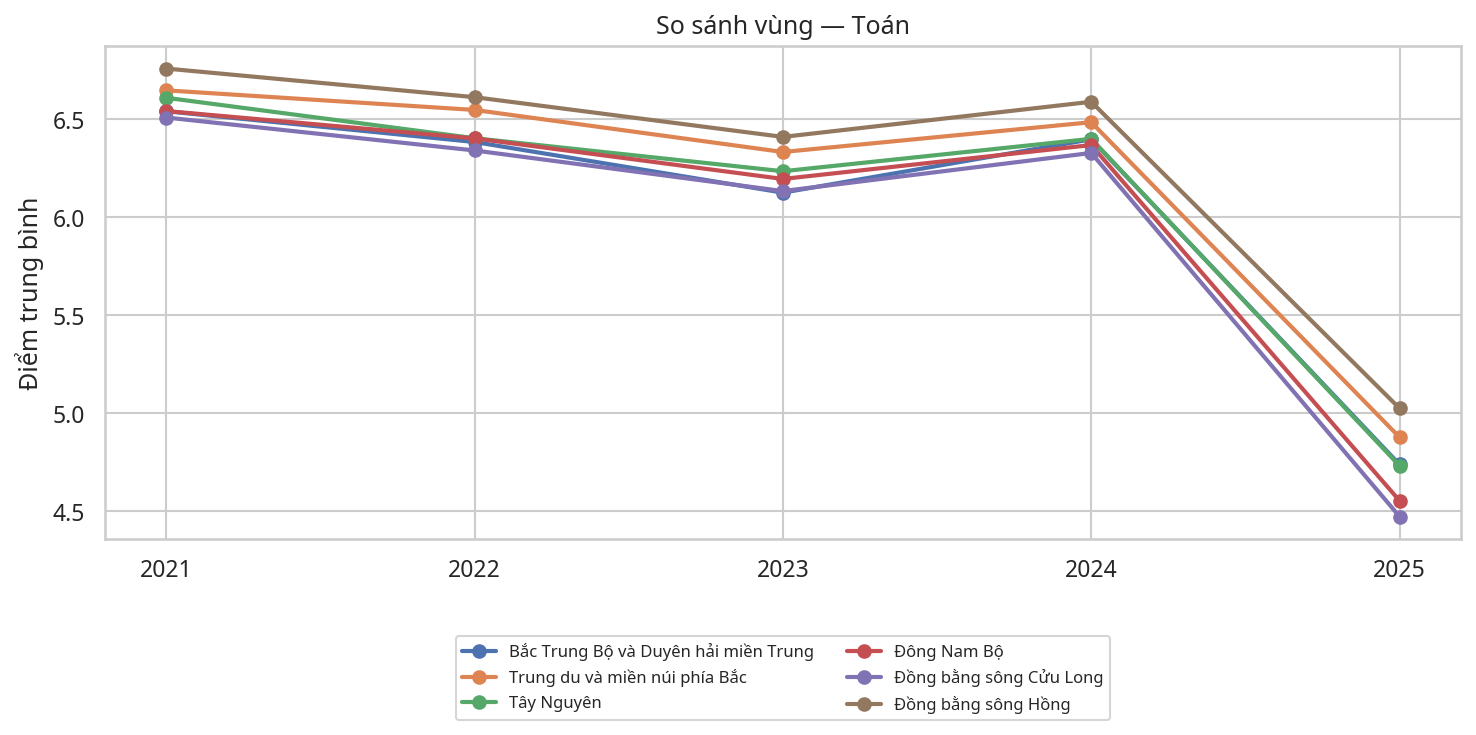

region_comparison_VatLy.png


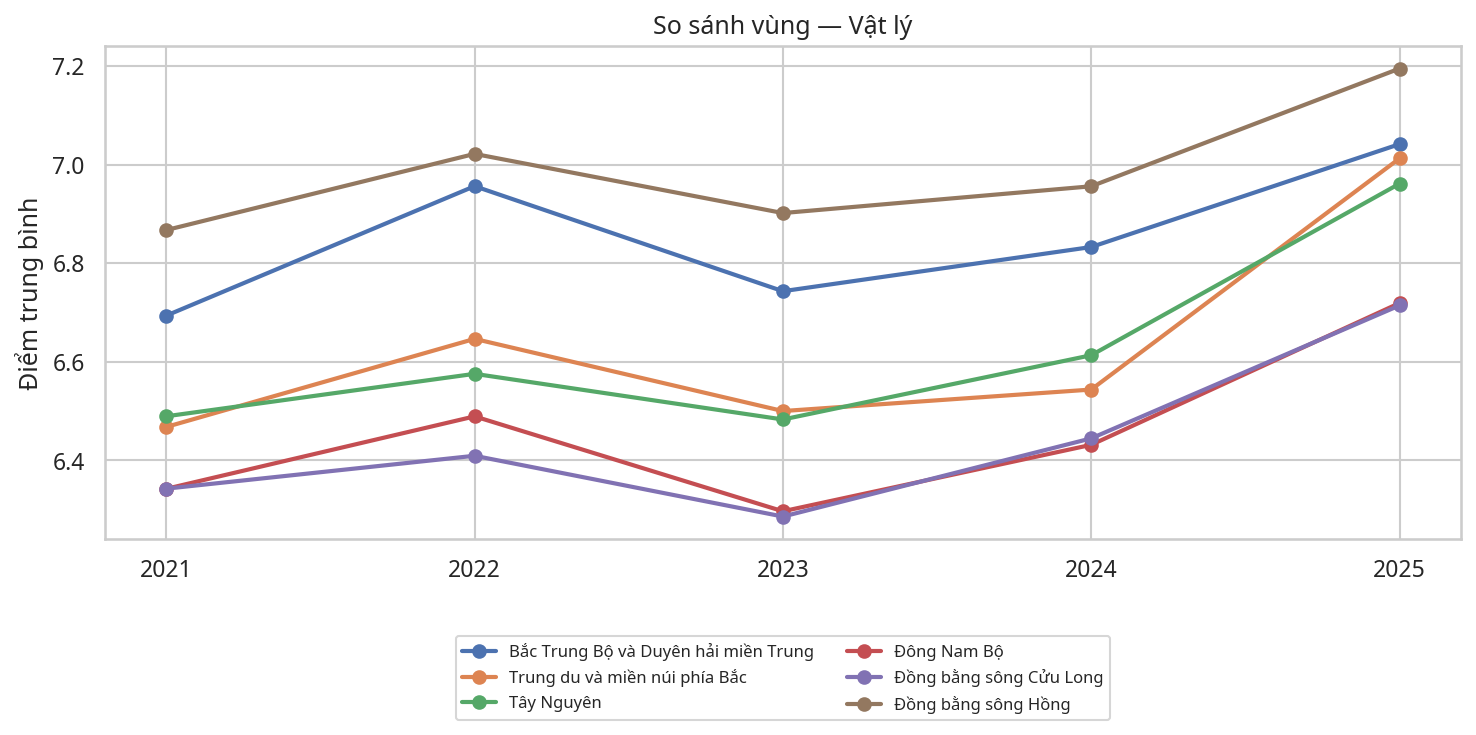

score_bands_CongNgheCongNghiep.png


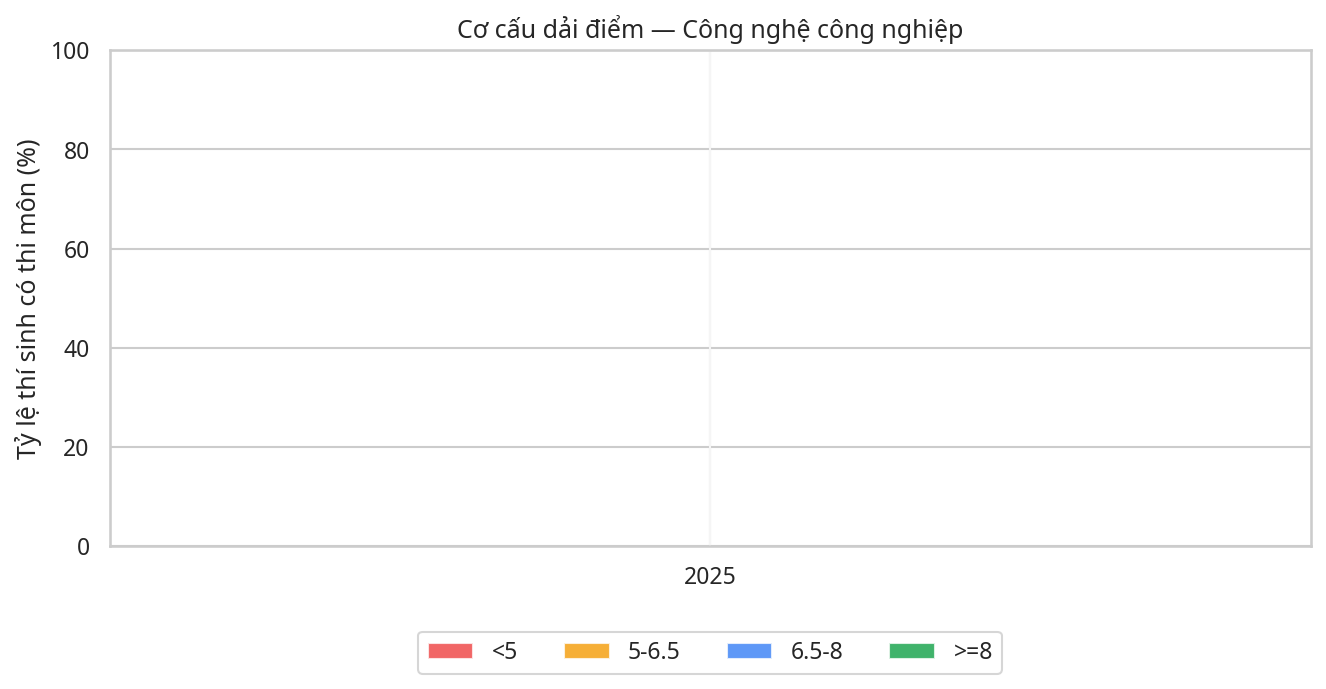

score_bands_CongNgheNongNghiep.png


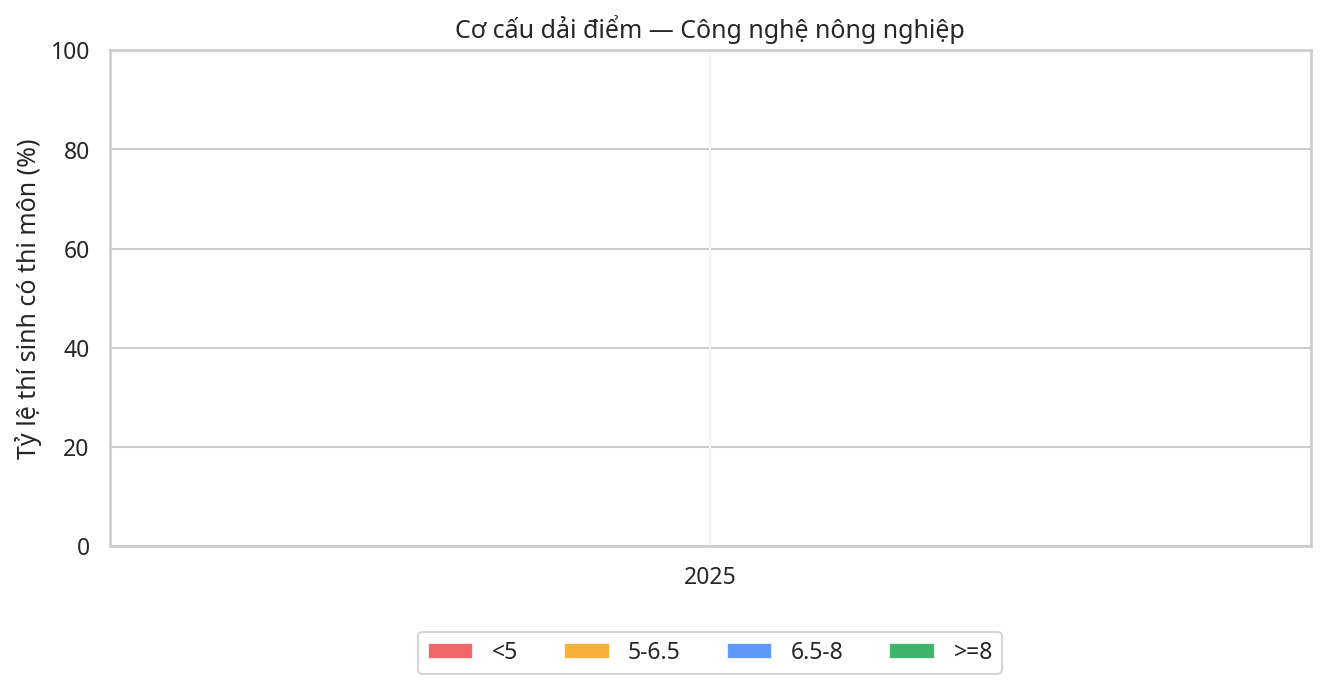

score_bands_DiaLy.png


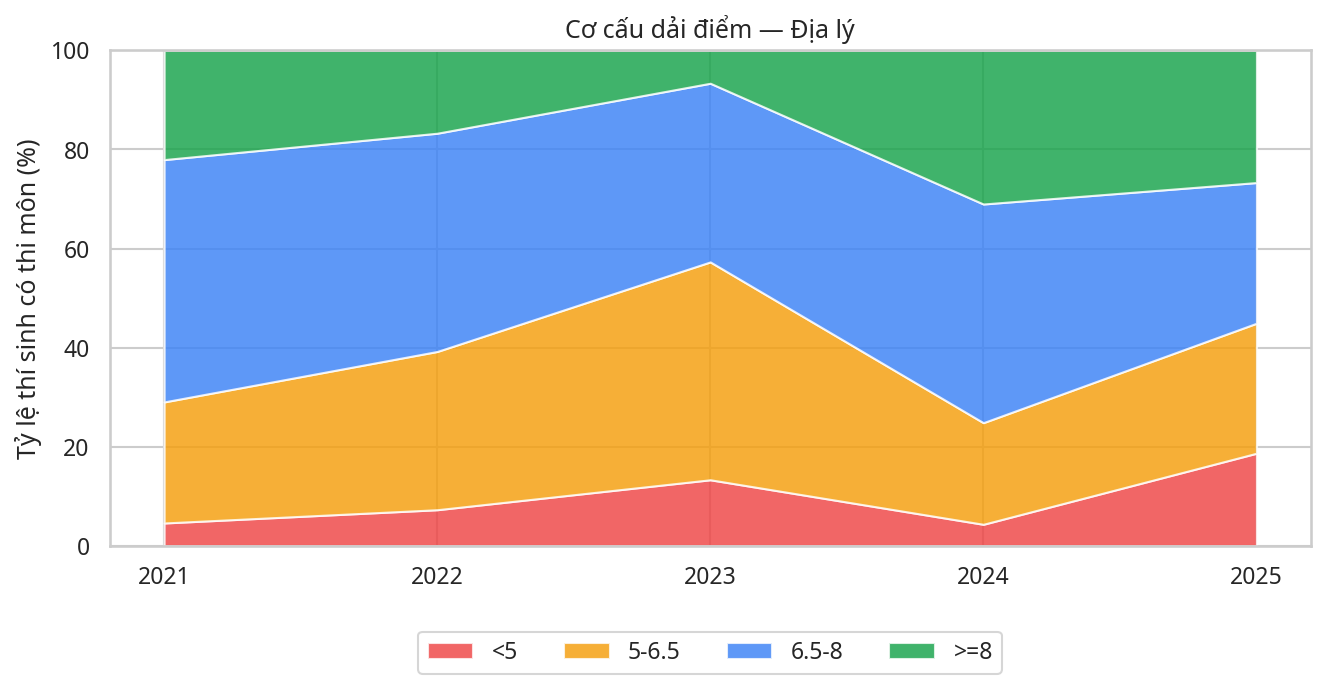

score_bands_GDCD.png


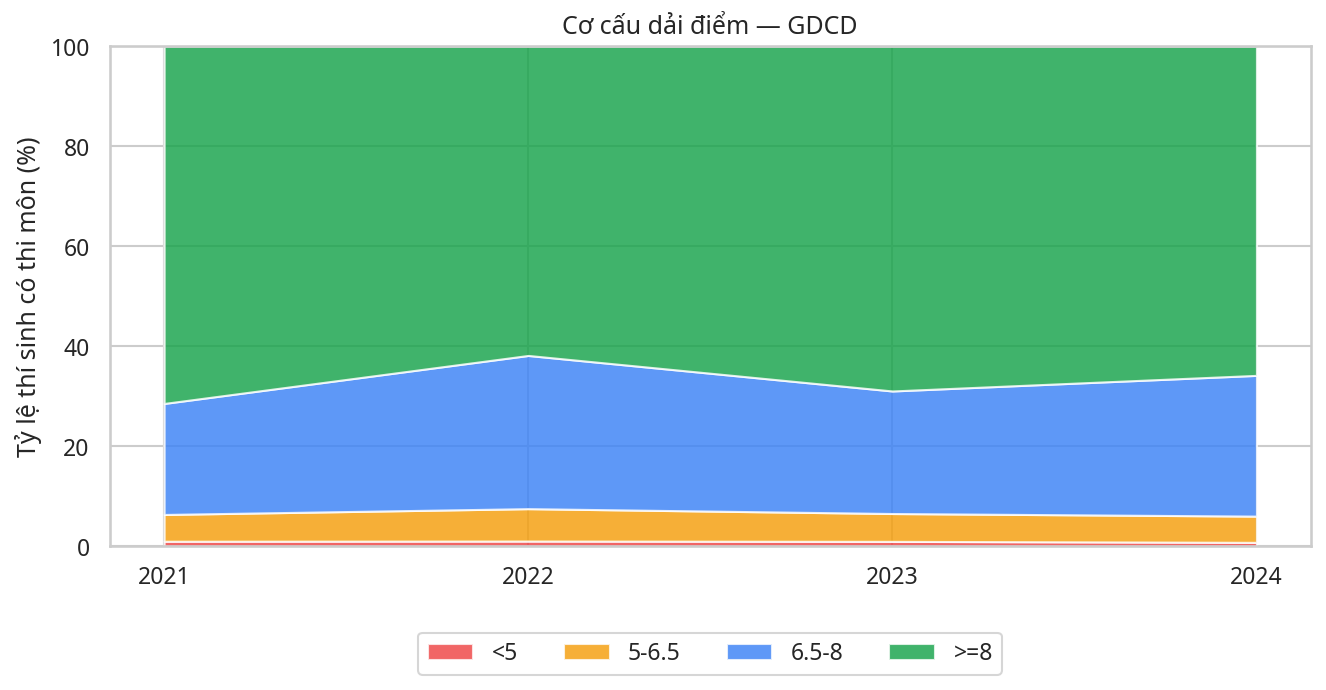

score_bands_HoaHoc.png


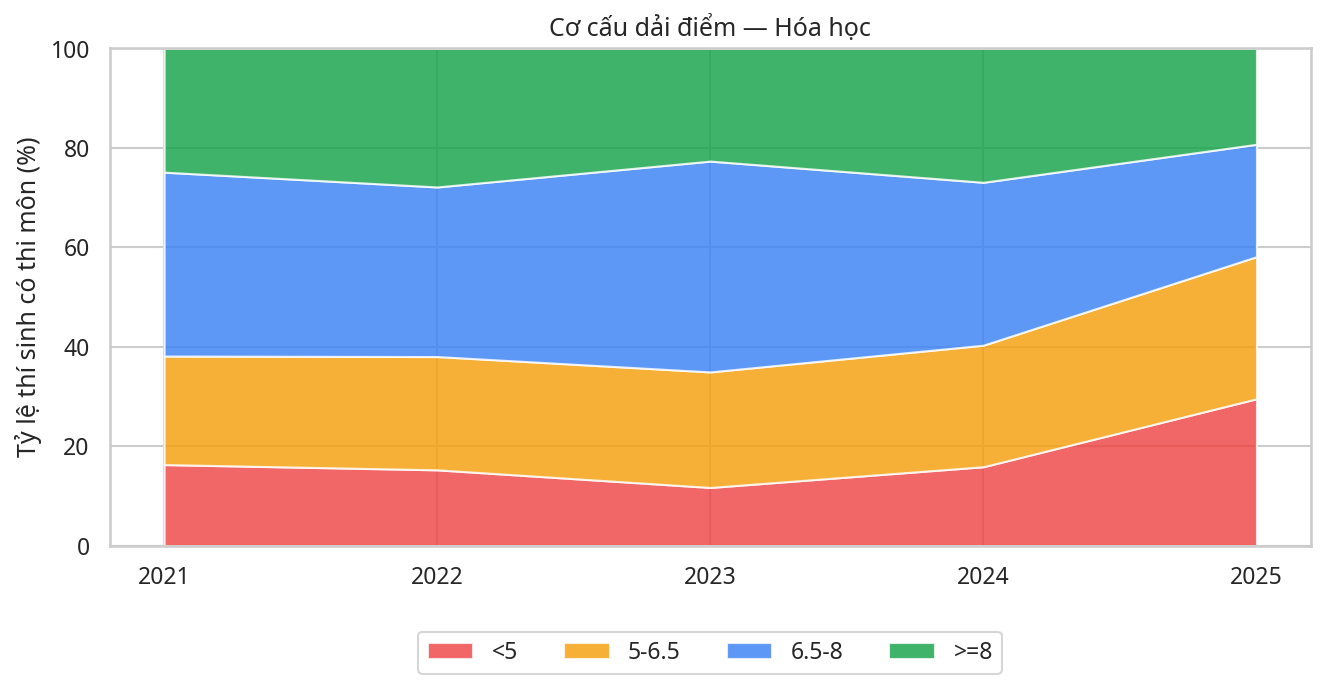

score_bands_KinhTePhapLuat.png


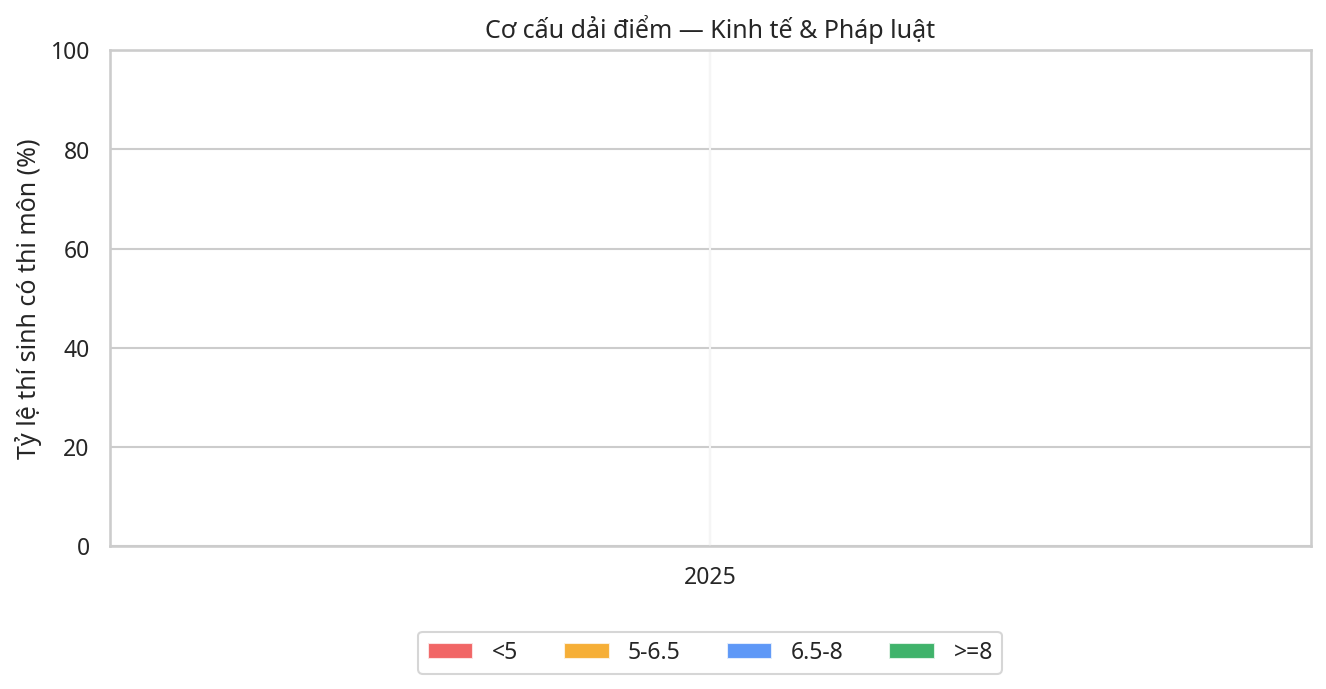

score_bands_LichSu.png


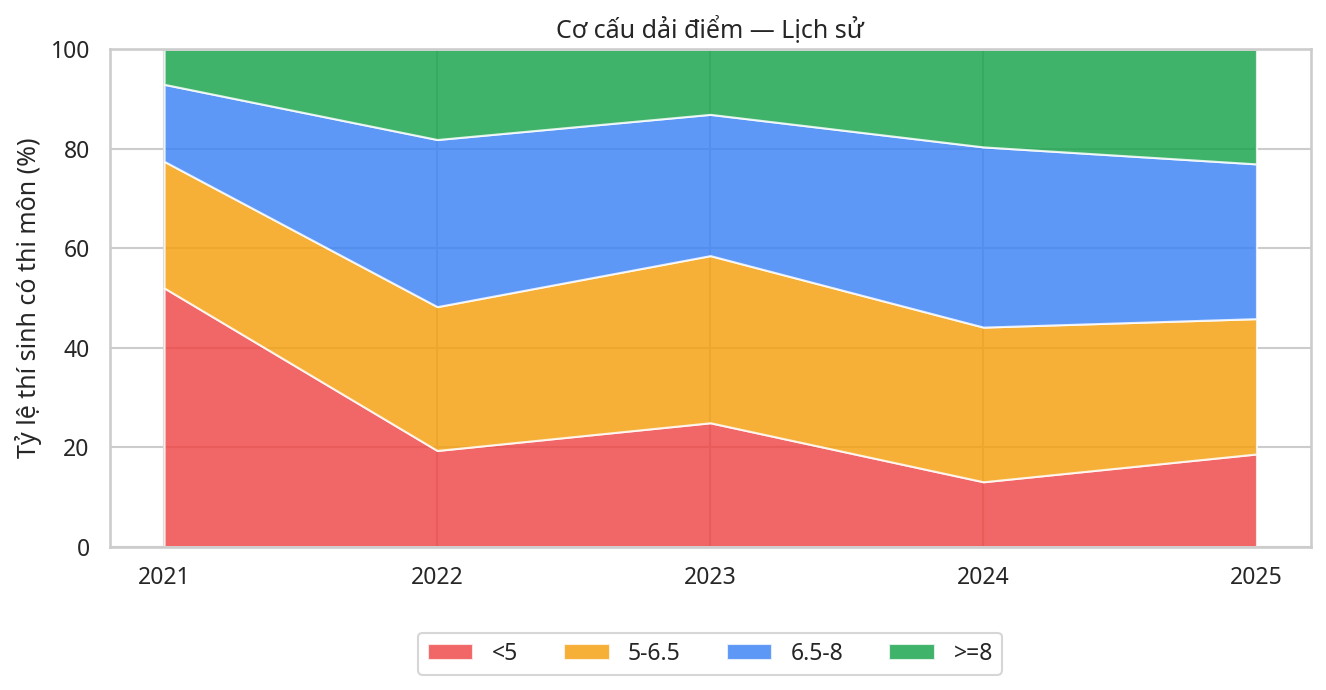

score_bands_NgoaiNgu.png


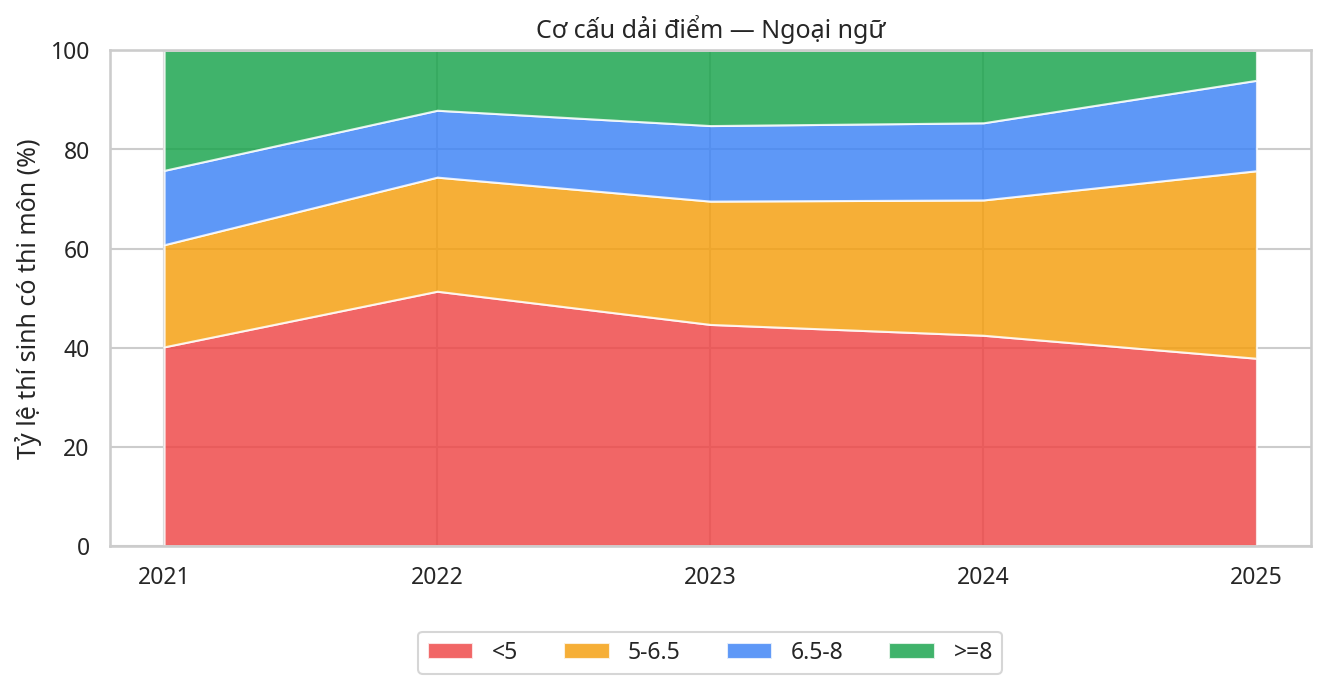

score_bands_NguVan.png


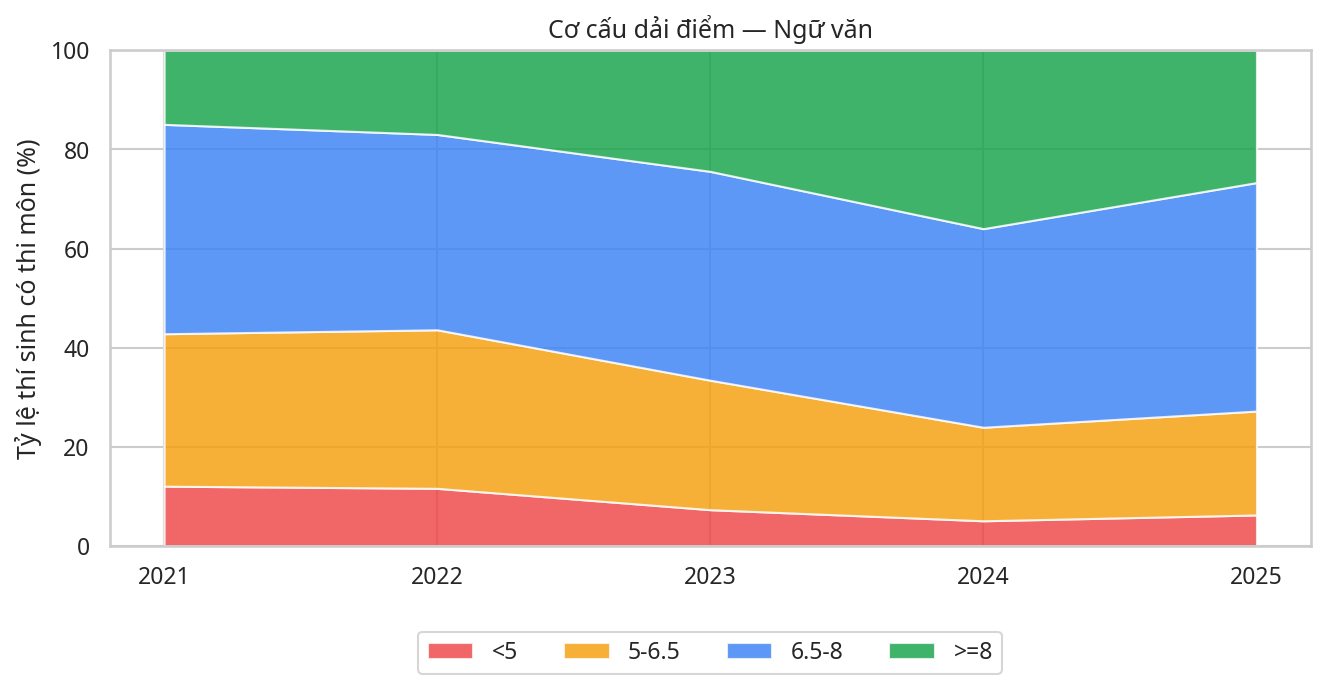

score_bands_SinhHoc.png


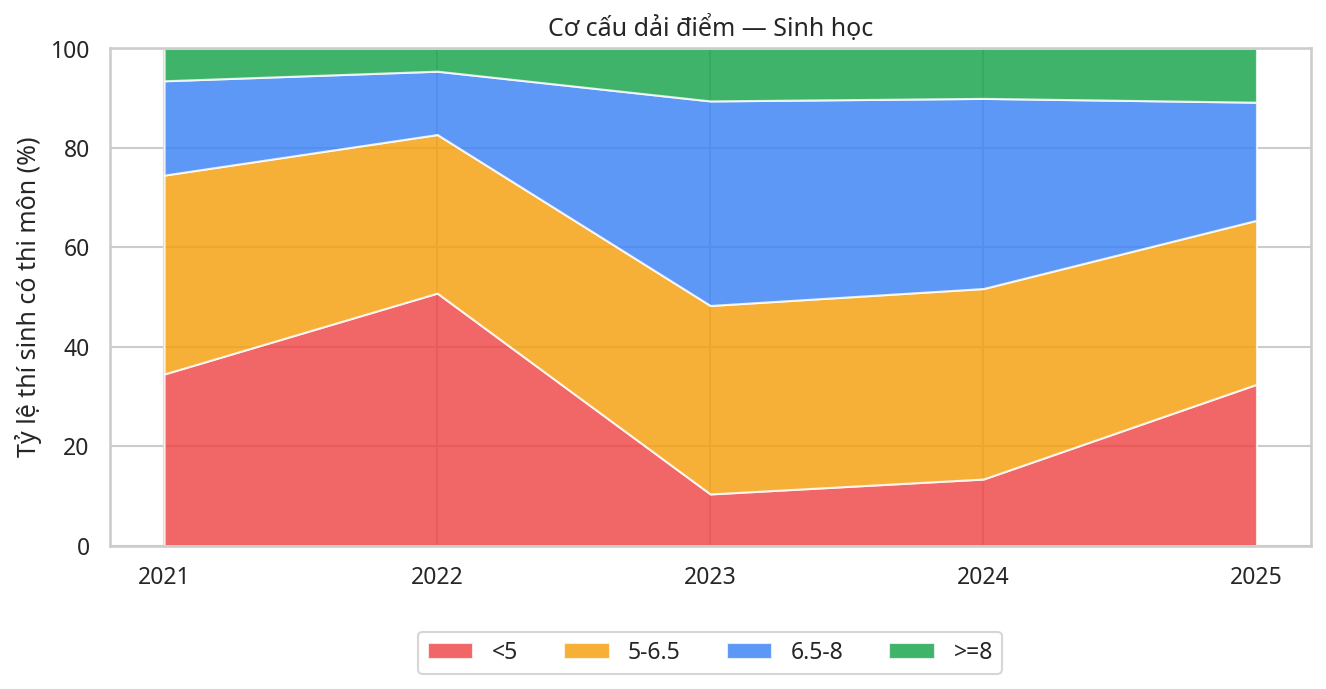

score_bands_TinHoc.png


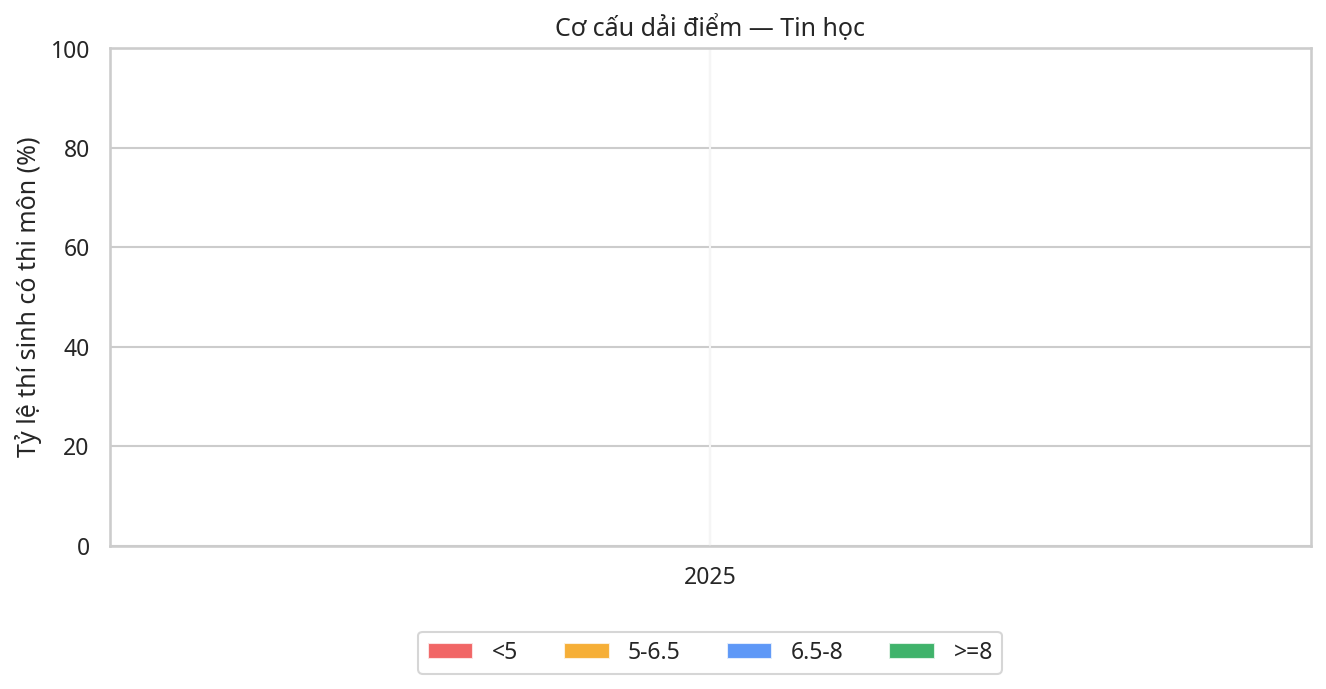

score_bands_Toan.png


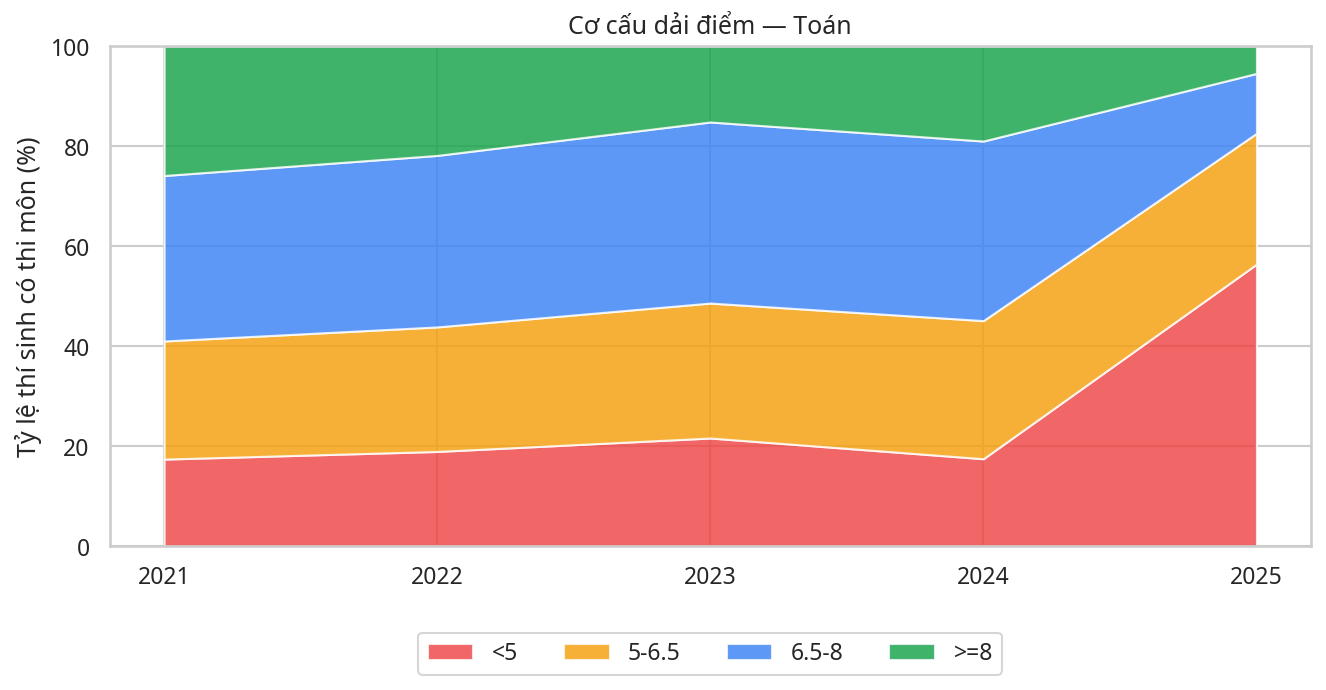

score_bands_VatLy.png


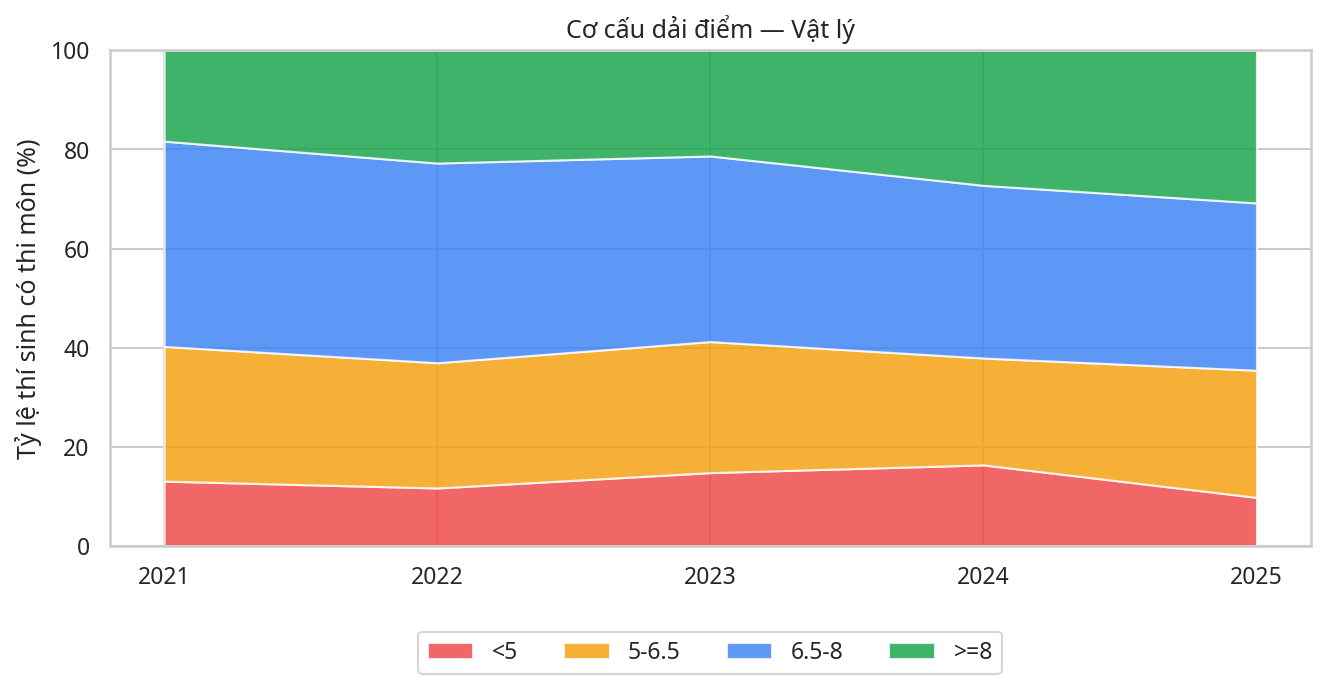

yoy_change_heatmap.png


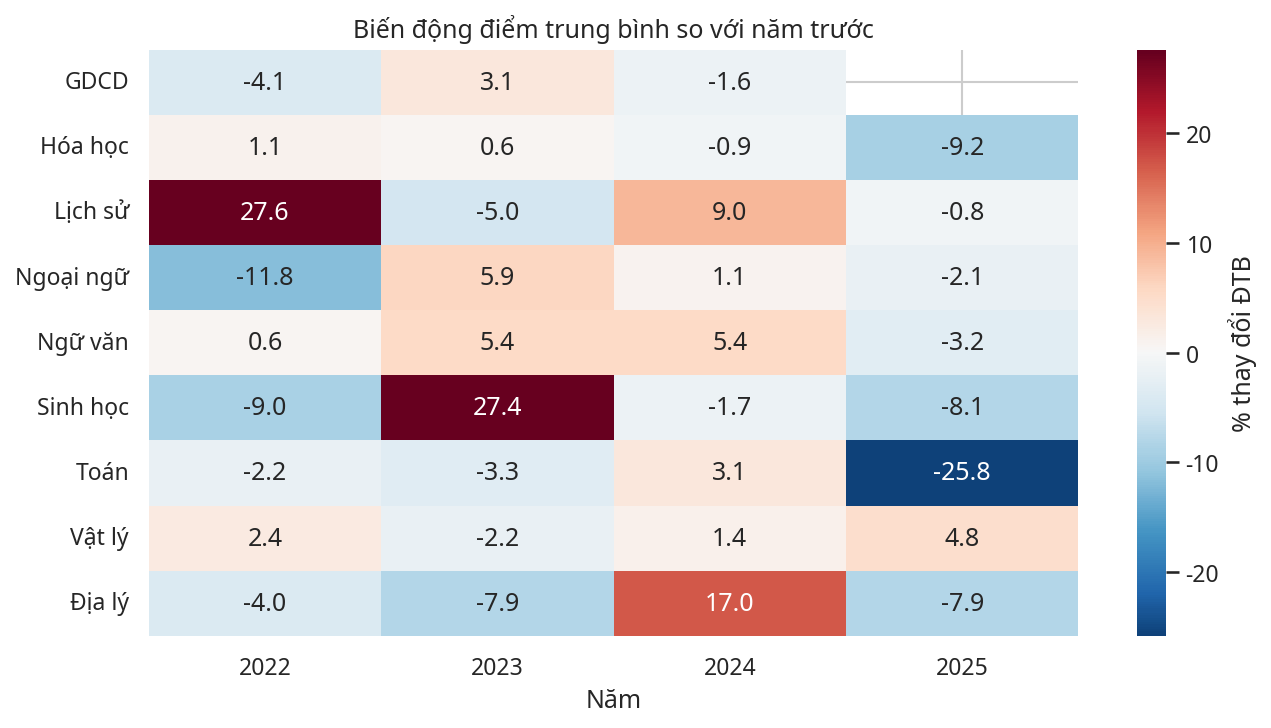

In [21]:
from IPython.display import Image, display
from pathlib import Path

for p in sorted(Path("outputs/figures").glob("*.png")):
    print(p.name)
    display(Image(filename=str(p)))

## 10. Tải Kết Quả

In [22]:
import zipfile
from pathlib import Path
from google.colab import files

zip_path = Path("/content/thptqg_full_outputs.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for folder in ["outputs", "docs", "data"]:
        for f in Path(folder).rglob("*"):
            if f.is_file():
                z.write(f, f.as_posix())
    z.write("README.md", "README.md")
    z.write("requirements.txt", "requirements.txt")
    z.write(".env.example", ".env.example")

files.download(str(zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>